## Frames

Generating 500 testing videos. 

```
cd /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Teacher
python3 -m venv teacher_venv
source teacher_venv/bin/activate
pip install -r requirements.txt
```

```
cd /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Teacher
source teacher_venv/bin/activate
python main.py --mode test
```

To change videos generation go to Teacher/test/text.py and change for loop range.

## Environment

Before running the full notebook, activate the Student environment. From `Student/`, create and activate the virtual environment and install the required packages with `python3 -m venv .venv`, `source .venv/bin/activate`, and `pip install -r requirements.txt`. Make sure the notebook uses the Student Python kernel from this environment before executing all cells.

If raw frames are missing, generate them before running the notebook. From `Student/`, with the same environment activated, run `PYTHONPATH=src python src/teacher_data_prep.py`. This reads source videos from `Teacher/videos/` and writes extracted grayscale frames to `Student/data/frames/`.


## Setup

In [90]:
from pathlib import Path
from datetime import datetime

# Resolve the Student root from the current notebook location.
_cwd = Path.cwd().resolve()
STUDENT = None
for p in [_cwd, *_cwd.parents]:
    if (p / "src").is_dir() and (p / "notebooks").is_dir() and (p / "data").is_dir():
        STUDENT = p
        break

if STUDENT is None:
    raise RuntimeError("Could not find Student root")

# Define the main project roots.
STUDENT_ROOT = STUDENT
TEACHER = STUDENT.parent / "Teacher"

# Path to raw extracted teacher frames.
FRAMES_ROOT = STUDENT / "data" / "frames"

# Root directory for all experiment runs.
RUNS_ROOT = STUDENT / "runs"

###################
### Autoencoder ###
###################

# Autoencoder run directory.
AE_DIR = RUNS_ROOT / "autoencoder"
STAMP = datetime.now().strftime("%d%m%Y_%H%M%S")
AE_RUN_DIR = AE_DIR / f"autoencoder_{STAMP}"

# Create the autoencoder run folder.
AE_RUN_DIR.mkdir(parents=True, exist_ok=True)

# Autoencoder dataset files saved inside the run folder.
AE_TRAIN_PT = AE_RUN_DIR / "ae_train_dataset.pt"
AE_TEST_PT = AE_RUN_DIR / "ae_test_dataset.pt"


##################
### Sequential ###
##################

# Sequential run directory.
SEQ_DIR = RUNS_ROOT / "sequential"
STAMP = datetime.now().strftime("%d%m%Y_%H%M%S")
SEQ_RUN_DIR = SEQ_DIR / f"sequential_{STAMP}"

# Create the sequential run folder.
SEQ_RUN_DIR.mkdir(parents=True, exist_ok=True)

# Sequential dataset files saved inside the run folder.
SEQ_TRAIN_PT = SEQ_RUN_DIR / "seq_train_dataset.pt"
SEQ_TEST_PT = SEQ_RUN_DIR / "seq_test_dataset.pt"

## Autoencoder

Single cell: **dataset** → **DataLoader** → **AutoEncoder network (defined here)** → **training loop** with logs. Outputs go under **`runs/autoencoder/`**.

This is **research**: everything is defined in-notebook (no imports from `src/Autoencoder/*`).

In [91]:
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
import shutil

from PIL import Image
import numpy as np

### Dataset and DataLoader

In [92]:
Z_DIM = 64
EPOCHS = 10
BATCH_SIZE = 128
LR = 3e-4
GRAD_CLIP = 1.0
LOG_EVERY = 100
LIMIT_SAMPLES = 8192
TEST_RATIO = 0.2
NUM_WORKERS = 0
SEED = 42
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

def load_episode(video_dir: Path):
    frames = sorted(video_dir.glob("*.png"), key=lambda p: int(p.stem))
    xs = [
        torch.tensor(np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0)
        for p in frames
    ]
    return torch.stack(xs).unsqueeze(1)

video_dirs = sorted([p for p in FRAMES_ROOT.iterdir() if p.is_dir()], key=lambda p: int(p.name))
episodes = [load_episode(video_dir) for video_dir in video_dirs]

rng = np.random.default_rng(SEED)
indices = np.arange(len(episodes))
rng.shuffle(indices)

n_test = int(np.ceil(TEST_RATIO * len(episodes)))
test_idx = set(indices[:n_test].tolist())
train_idx = set(indices[n_test:].tolist())

ae_train_episodes = [episodes[i] for i in range(len(episodes)) if i in train_idx]
ae_test_episodes = [episodes[i] for i in range(len(episodes)) if i in test_idx]

ae_train_dataset = torch.cat(ae_train_episodes, dim=0)
ae_test_dataset = torch.cat(ae_test_episodes, dim=0)

if LIMIT_SAMPLES is not None and LIMIT_SAMPLES < len(ae_train_dataset):
    g = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(len(ae_train_dataset), generator=g)[:LIMIT_SAMPLES]
    ae_train_dataset = ae_train_dataset[idx]
    print(f"[AE] using {LIMIT_SAMPLES} ae_train_dataset frames")

torch.save(ae_train_dataset, AE_TRAIN_PT)
torch.save(ae_test_dataset, AE_TEST_PT)

print(f"[AE] saved ae_train_dataset -> {AE_TRAIN_PT}")
print(f"[AE] saved ae_test_dataset  -> {AE_TEST_PT}")
print(f"[AE] ae_train_dataset frames = {len(ae_train_dataset)}")
print(f"[AE] ae_test_dataset frames  = {len(ae_test_dataset)}")

_dl = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)

if NUM_WORKERS > 0:
    _dl["prefetch_factor"] = 2

ae_train_dataloader = DataLoader(ae_train_dataset, shuffle=True, **_dl)
ae_test_dataloader = DataLoader(ae_test_dataset, shuffle=False, **_dl)

[AE] using 8192 ae_train_dataset frames
[AE] saved ae_train_dataset -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/ae_train_dataset.pt
[AE] saved ae_test_dataset  -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/ae_test_dataset.pt
[AE] ae_train_dataset frames = 8192
[AE] ae_test_dataset frames  = 35295


### Loss

In [93]:
# -------------------------
# Loss (raw)
# -------------------------
def weighted_mse(x_hat, x, threshold=0.1, high_weight=20.0):
    mask = (x > threshold).float()
    weights = 1.0 + mask * high_weight
    return ((x_hat - x) ** 2 * weights).mean()

### Model

In [94]:
# -------------------------
# AutoEncoder network (raw)
# -------------------------
class AutoEncoder(nn.Module):
    """84×84 grayscale conv autoencoder."""

    def __init__(self, z_dim: int):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 84 → 42
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 42 → 21
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 21 → 10
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, 1, 1),  # 10 → 10
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),  # 10 → 10
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Flatten(),  # 256 * 10 * 10 = 25600
            nn.Linear(25600, z_dim),
            nn.LayerNorm(z_dim),
        )

        self.decoder_fc = nn.Linear(z_dim, 25600)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 10 → 20
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 20 → 40
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 40 → 80
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1),  # 80 → 160
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        x_hat = self.decoder(x_hat)
        x_hat = x_hat[:, :, :84, :84]  # crop back to 84×84
        return x_hat, z

### Train

In [ ]:
# -------------------------
# Train loop (raw)
# -------------------------
ae_model = AutoEncoder(z_dim=Z_DIM).to(DEVICE)
opt = torch.optim.Adam(ae_model.parameters(), lr=LR)
ae_model.train()

ae_train_losses = []
ae_test_losses = []
t0 = time.time()

print(f"[AE] device={DEVICE}")
print(f"[AE] train_batches/epoch={len(ae_train_dataloader)}")
print(f"[AE] test_batches/epoch={len(ae_test_dataloader)}")
print(f"[AE] save_dir={AE_RUN_DIR}")


[AE] device=mps
[AE] train_batches/epoch=64
[AE] test_batches/epoch=276
[AE] save_dir=/Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451


In [96]:
# Train for multiple epochs and evaluate on the held-out test set after each epoch.
for epoch in range(1, EPOCHS + 1):
    ae_model.train()
    train_ep_loss = 0.0
    train_n_b = 0

    # Training pass over the AE train dataloader.
    for step, batch in enumerate(ae_train_dataloader, start=1):
        x = batch.to(DEVICE, non_blocking=True)
        x_hat, _ = ae_model(x)
        loss = weighted_mse(x_hat, x, threshold=0.1, high_weight=20.0)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ae_model.parameters(), GRAD_CLIP)
        opt.step()

        train_ep_loss += float(loss.item())
        train_n_b += 1

        # Optional per-step training log.
        if LOG_EVERY and step % LOG_EVERY == 0:
            print(
                f"[AE][train] epoch {epoch:03d}/{EPOCHS} "
                f"step {step:05d}/{len(ae_train_dataloader)} "
                f"loss {loss.item():.6f} | {time.time() - t0:.1f}s"
            )

    ae_model.eval()
    test_ep_loss = 0.0
    test_n_b = 0

    # Evaluation pass over the AE test dataloader without gradient updates.
    with torch.no_grad():
        for batch in ae_test_dataloader:
            x = batch.to(DEVICE, non_blocking=True)
            x_hat, _ = ae_model(x)
            loss = weighted_mse(x_hat, x, threshold=0.1, high_weight=20.0)

            test_ep_loss += float(loss.item())
            test_n_b += 1

    # Compute mean train and test loss for the current epoch.
    train_mean_ep = train_ep_loss / max(train_n_b, 1)
    test_mean_ep = test_ep_loss / max(test_n_b, 1)

    # Store the loss history for later plotting and saving.
    ae_train_losses.append(train_mean_ep)
    ae_test_losses.append(test_mean_ep)

    # Epoch-level summary log.
    print(
        f"[AE] epoch {epoch:03d}/{EPOCHS} "
        f"train_loss {train_mean_ep:.6f} | test_loss {test_mean_ep:.6f} "
        f"| {time.time() - t0:.1f}s total"
    )


[AE] epoch 001/10 train_loss 0.462582 | test_loss 0.061956 | 50.0s total
[AE] epoch 002/10 train_loss 0.046330 | test_loss 0.044200 | 100.0s total
[AE] epoch 003/10 train_loss 0.031018 | test_loss 0.030880 | 149.6s total
[AE] epoch 004/10 train_loss 0.024505 | test_loss 0.022815 | 199.4s total
[AE] epoch 005/10 train_loss 0.017204 | test_loss 0.019650 | 248.6s total
[AE] epoch 006/10 train_loss 0.015511 | test_loss 0.016537 | 296.5s total
[AE] epoch 007/10 train_loss 0.013035 | test_loss 0.015346 | 344.4s total
[AE] epoch 008/10 train_loss 0.012057 | test_loss 0.015076 | 394.2s total
[AE] epoch 009/10 train_loss 0.011119 | test_loss 0.015605 | 443.8s total
[AE] epoch 010/10 train_loss 0.008303 | test_loss 0.014391 | 493.0s total


### Save

[AE] saved weights → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/model.pth
[AE] saved full model → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/model_full.pt
[AE] saved scripted model → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/ae_model_scripted.pt
[AE] saved losses  → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/losses.pt
[AE] saved ae_train_dataset → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/ae_train_dataset.pt
[AE] saved ae_test_dataset  → /Users/adriankazi/Desktop/Deep-Learn

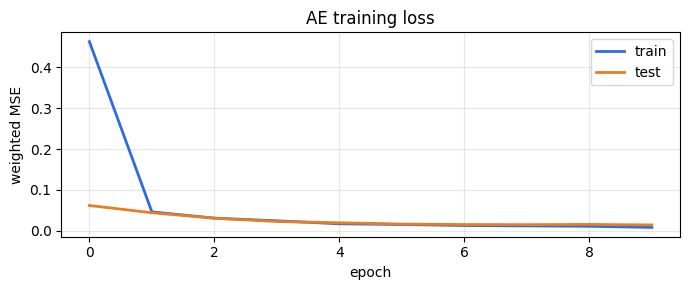

[AE] saved plot → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/loss.png


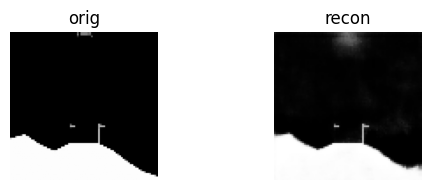

[AE] saved recon → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/reconstruction.png


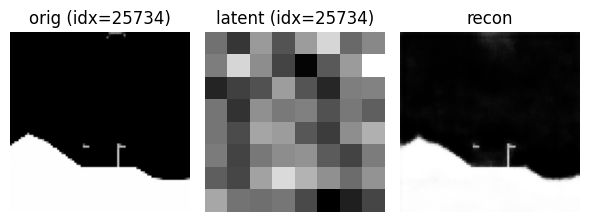

[AE] saved sample → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/sample_reconstruction.png


In [97]:
# -------------------------
# Save AE artifacts
# -------------------------

ckpt = AE_RUN_DIR / "model.pth"
full_ckpt = AE_RUN_DIR / "model_full.pt"
scripted_ckpt = AE_RUN_DIR / "ae_model_scripted.pt"
losses_path = AE_RUN_DIR / "losses.pt"
fig_path = AE_RUN_DIR / "loss.png"
recon_path = AE_RUN_DIR / "reconstruction.png"
sample_plot_path = AE_RUN_DIR / "sample_reconstruction.png"

torch.save(ae_model.state_dict(), ckpt)
torch.save(ae_model, full_ckpt)
torch.save(
    {
        "ae_train_losses": ae_train_losses,
        "ae_test_losses": ae_test_losses,
    },
    losses_path,
)

ae_model.eval()
ae_model_cpu = ae_model.to("cpu")
scripted_ae = torch.jit.script(ae_model_cpu)
scripted_ae.save(str(scripted_ckpt))
ae_model = ae_model_cpu.to(DEVICE)

print(f"[AE] saved weights → {ckpt}")
print(f"[AE] saved full model → {full_ckpt}")
print(f"[AE] saved scripted model → {scripted_ckpt}")
print(f"[AE] saved losses  → {losses_path}")
print(f"[AE] saved ae_train_dataset → {AE_TRAIN_PT}")
print(f"[AE] saved ae_test_dataset  → {AE_TEST_PT}")

# -------------------------
# Save AE loss plot
# -------------------------

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(ae_train_losses, color="#2d6cdf", lw=2, label="train")
ax.plot(ae_test_losses, color="#e67e22", lw=2, label="test")
ax.set_xlabel("epoch")
ax.set_ylabel("weighted MSE")
ax.set_title("AE training loss")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=140)
plt.show()
print(f"[AE] saved plot → {fig_path}")

# -------------------------
# Save AE reconstruction plot
# -------------------------

ae_model.eval()
ae_test_episodes = torch.load(AE_TEST_PT)
ep0 = ae_test_episodes[0]

if ep0.dim() == 3:
    ep0 = ep0.unsqueeze(1)  # [T, H, W] -> [T, 1, H, W]

with torch.no_grad():
    x_hat0, _ = ae_model(ep0.to(DEVICE))

num_rows = min(20, int(ep0.shape[0]))
fig, axs = plt.subplots(num_rows, 2, figsize=(6, 2 * num_rows))

if num_rows == 1:
    axs = axs[None, :]

for i in range(num_rows):
    axs[i, 0].imshow(ep0[i, 0].cpu(), cmap="gray")
    axs[i, 0].set_title("orig" if i == 0 else "")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(x_hat0[i, 0].detach().cpu(), cmap="gray")
    axs[i, 1].set_title("recon" if i == 0 else "")
    axs[i, 1].axis("off")

plt.tight_layout()
plt.savefig(recon_path, dpi=150)
plt.show()
print(f"[AE] saved recon → {recon_path}")

# -------------------------
# Save random AE test sample plot
# -------------------------

i = torch.randint(0, len(ae_test_dataset), (1,)).item()
x = ae_test_dataset[i][None].to(DEVICE)

with torch.no_grad():
    x_hat, z = ae_model(x)

plt.figure(figsize=(6, 3))

plt.subplot(1, 3, 1)
plt.imshow(x[0, 0].cpu(), cmap="gray")
plt.axis("off")
plt.title(f"orig (idx={i})")

plt.subplot(1, 3, 2)
plt.imshow(z.view(8, 8).cpu(), cmap="gray")
plt.axis("off")
plt.title(f"latent (idx={i})")

plt.subplot(1, 3, 3)
plt.imshow(x_hat[0, 0].cpu(), cmap="gray")
plt.axis("off")
plt.title("recon")

plt.tight_layout()
plt.savefig(sample_plot_path, dpi=150)
plt.show()
print(f"[AE] saved sample → {sample_plot_path}")


### Load AE + quick sanity

Pick a checkpoint saved under `runs/autoencoder/` and run the autoencoder on **one random rendered frame** from `LunarLanderContinuous-v3`.

- Set `MODEL_FILE` to a relative path inside `runs/autoencoder/`, for example `autoencoder_17042026_214345/model.pth`.
- Choose the checkpoint manually from `runs/autoencoder/`.


In [98]:
import time
import torch
import matplotlib.pyplot as plt

t0 = time.time()

scripted_ckpt = AE_RUN_DIR / "ae_model_scripted.pt"
ae_model = torch.jit.load(str(scripted_ckpt), map_location=DEVICE)
ae_model.eval()

print(f"[AE] loaded scripted model → {scripted_ckpt}")


[AE] loaded scripted model → /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_24042026_213451/ae_model_scripted.pt


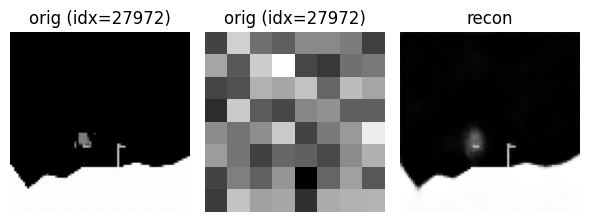

In [99]:
# one random photo from the training dataset (ds is defined in section 1)
i = torch.randint(0, len(ae_test_dataset), (1,)).item()
x = ae_test_dataset[i][None].to(DEVICE)  # (1,1,84,84)


with torch.no_grad():
    x_hat, z = ae_model(x)

# # show
plt.figure(figsize=(6, 3))
plt.subplot(1, 3, 1); plt.imshow(x[0, 0].cpu(), cmap="gray"); plt.axis("off"); plt.title(f"orig (idx={i})")
plt.subplot(1, 3, 2); plt.imshow(z.view(8,8).cpu(), cmap="gray"); plt.axis("off"); plt.title(f"orig (idx={i})")
plt.subplot(1, 3, 3); plt.imshow(x_hat[0, 0].cpu(), cmap="gray"); plt.axis("off"); plt.title("recon")
plt.tight_layout()
plt.show()

## Sequential

### Introduction

**Frames Reduction**

We process one episode at a time. The first frame is always kept and becomes the current reference frame `curr_frame`. Then we iterate through the remaining frames in temporal order. For each new frame `next_frame`, we evaluate `sim_func(curr_frame, next_frame)`. If the function returns `True`, the frame is considered informative enough to be kept, so it is appended to the reduced sequence and the reference is updated as `curr_frame = next_frame`. If the function returns `False`, the frame is skipped.

The role of this step is to reduce temporal redundancy. In raw rollouts, many consecutive frames are visually very similar, which provides only a weak learning signal for the sequential model. Frame reduction preserves the temporal order of the episode, but removes near-duplicate states so that the resulting sequence contains more meaningful transitions.

In the current version, `sim_func` measures whether the new frame contributes a sufficiently strong new component relative to the current reference frame. Concretely, the new frame is decomposed into two parts:
`projection + residual`,
where the projection is the part explained by the current frame, and the residual is the part that cannot be explained by it. If the residual is large enough relative to the norm of the new frame, the frame is treated as informative and is kept. If the residual is too small, the frame is treated as redundant and is skipped.

Intuitively, `sim_func` does not ask whether two frames are merely different pixel by pixel. Instead, it asks whether the new frame introduces enough new visual signal beyond what is already represented by the current reference frame.

**Predataset**

After reduction, each episode becomes one variable-length reduced sequence. We store these sequences before any chunking. This stored collection is the `predataset`.

Each element of the predataset corresponds to exactly one episode and has shape $[T_{\mathrm{red}}, 1, 84, 84]$, where $T_{\mathrm{red}}$ is the reduced episode length after frame filtering.

The predataset is therefore the intermediate representation between raw extracted frames and the final training dataset. It preserves full reduced episodes and acts as the source structure for all later sequential chunking.

**Dataset**

The dataset is built from the `predataset` by splitting each reduced episode into fixed-length chunks of size `seq_len`. For now `seq_len` is defined manually. Eventually `seq_len` should be inferred from data.

For every reduced episode, we iterate through it in blocks of length `seq_len`. Each block becomes one training sample. If the final block is shorter than `seq_len`, it is padded with black frames until it reaches the required length.

This produces a tensor dataset with shape $[N, \mathrm{seq\_len}, 1, 84, 84]$, where $N$ is the total number of generated chunks across all episodes. Alongside the chunk tensor `x`, we also store `lengths`, which record the valid number of frames before padding, and `episode_ids`, which record the original episode source of each chunk.

**Train/Test Split**

The split is done at the episode level, not at the chunk level. First, episodes are assigned to either `train` or `test`. Then all chunks originating from those episodes are assigned to the corresponding split.

This is important because chunk-level splitting would leak nearly identical temporal fragments of the same episode into both training and testing, which would make evaluation unreliable.

**DataLoader**

The `DataLoader` operates on the final chunked dataset. It batches fixed-length chunks for model training and evaluation.

A batch contains:
`x` with shape $[B, \mathrm{seq\_len}, 1, 84, 84]$,
`length` with shape $[B]$,
and `episode_id` with shape $[B]$.

Here, $B$ is the batch size. The training loader uses shuffling, while the test loader does not.

**Connection to the sequential model**

The `DataLoader` provides image chunks. Each frame in the chunk is passed through the autoencoder encoder, producing a latent sequence. This converts the image batch into a latent batch of shape $[B, \mathrm{seq\_len}, Z]$, where $Z$ is the latent dimensionality.

For next-step prediction, we use the first `seq_len - 1` latent vectors as input and the final latent vector as the target. In other words, if the chunk is
$z_0, z_1, \dots, z_{T-2}, z_{T-1}$,
then the LSTM receives
$z_0, z_1, \dots, z_{T-2}$
and is trained to predict
$z_{T-1}$.

**Overall intuition**

The pipeline is intentionally split into stages.

`Frames Reduction` removes redundant raw frames while preserving temporal order.
`Predataset` stores full reduced episodes.
`Dataset` converts those episodes into fixed-length training chunks.
`DataLoader` batches those chunks for training.

This makes the sequential pipeline easier to debug, easier to reproduce, and easier to modify for future versions.


In [100]:
from pathlib import Path
from PIL import Image
import numpy as np

SEQ_LEN = 32

def load_episode(video_dir):
    frames = sorted(video_dir.glob("*.png"), key=lambda p: int(p.stem))
    xs = [np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0 for p in frames]
    return np.stack(xs)

def sim_func(prev, curr, threshold=0.03):
    prev_v = prev.reshape(-1).astype(np.float32)
    curr_v = curr.reshape(-1).astype(np.float32)
    alpha = np.dot(curr_v, prev_v) / (np.dot(prev_v, prev_v) + 1e-8)
    residual = curr_v - alpha * prev_v
    novelty_ratio = np.linalg.norm(residual) / (np.linalg.norm(curr_v) + 1e-8)
    return novelty_ratio > threshold

def justify_func(frame_seq, seq_len=32):
    n = (len(frame_seq) // seq_len) * seq_len
    return frame_seq[:n]

video_dirs = sorted([p for p in FRAMES_ROOT.iterdir() if p.is_dir()], key=lambda p: int(p.name))

frames_seqs = []
episode_lengths = []

print(f'{"episode":^10} | {"total_frames":^14} | {"frames_sim":^12} | {"frames_final":^12} | {"chunks":^8}')
print("-" * 70)

for i, video_dir in enumerate(video_dirs, 1):
    x = load_episode(video_dir)
    T = len(x)
    episode_lengths.append(T)

    if T < SEQ_LEN:
        print(f"{i:^10} | {T:^14} | {0:^12} | {0:^12} | {0:^8}")
        continue

    curr_frame = x[0]
    frame_seq = [curr_frame]

    for t in range(1, T):
        next_frame = x[t]
        if sim_func(curr_frame, next_frame):
            curr_frame = next_frame
            frame_seq.append(curr_frame)

    frames_sim = len(frame_seq)
    frame_seq = justify_func(frame_seq, SEQ_LEN)
    frames_final = len(frame_seq)
    chunks = frames_final // SEQ_LEN

    if frames_final == 0:
        print(f"{i:^10} | {T:^14} | {frames_sim:^12} | {0:^12} | {0:^8}")
        continue

    frames_seqs.append(frame_seq)
    print(f"{i:^10} | {T:^14} | {frames_sim:^12} | {frames_final:^12} | {chunks:^8}")

if len(frames_seqs) == 0:
    raise RuntimeError("No episodes left after sim_func + justify_func")

print()
print(f'{"num_episodes":<20}: {len(frames_seqs)}')
print(f'{"seq_len":<20}: {SEQ_LEN}')
print(f'{"total_chunks":<20}: {sum(len(seq)//SEQ_LEN for seq in frames_seqs)}')

 episode   |  total_frames  |  frames_sim  | frames_final |  chunks 
----------------------------------------------------------------------
    1      |      260       |      82      |      64      |    2    
    2      |      387       |      82      |      64      |    2    
    3      |      273       |      93      |      64      |    2    
    4      |      296       |      74      |      64      |    2    
    5      |      261       |      79      |      64      |    2    
    6      |      256       |      88      |      64      |    2    
    7      |      237       |      67      |      64      |    2    
    8      |      311       |      74      |      64      |    2    
    9      |      307       |      69      |      64      |    2    
    10     |      338       |      83      |      64      |    2    
    11     |      240       |      92      |      64      |    2    
    12     |      320       |      85      |      64      |    2    
    13     |      256       |   

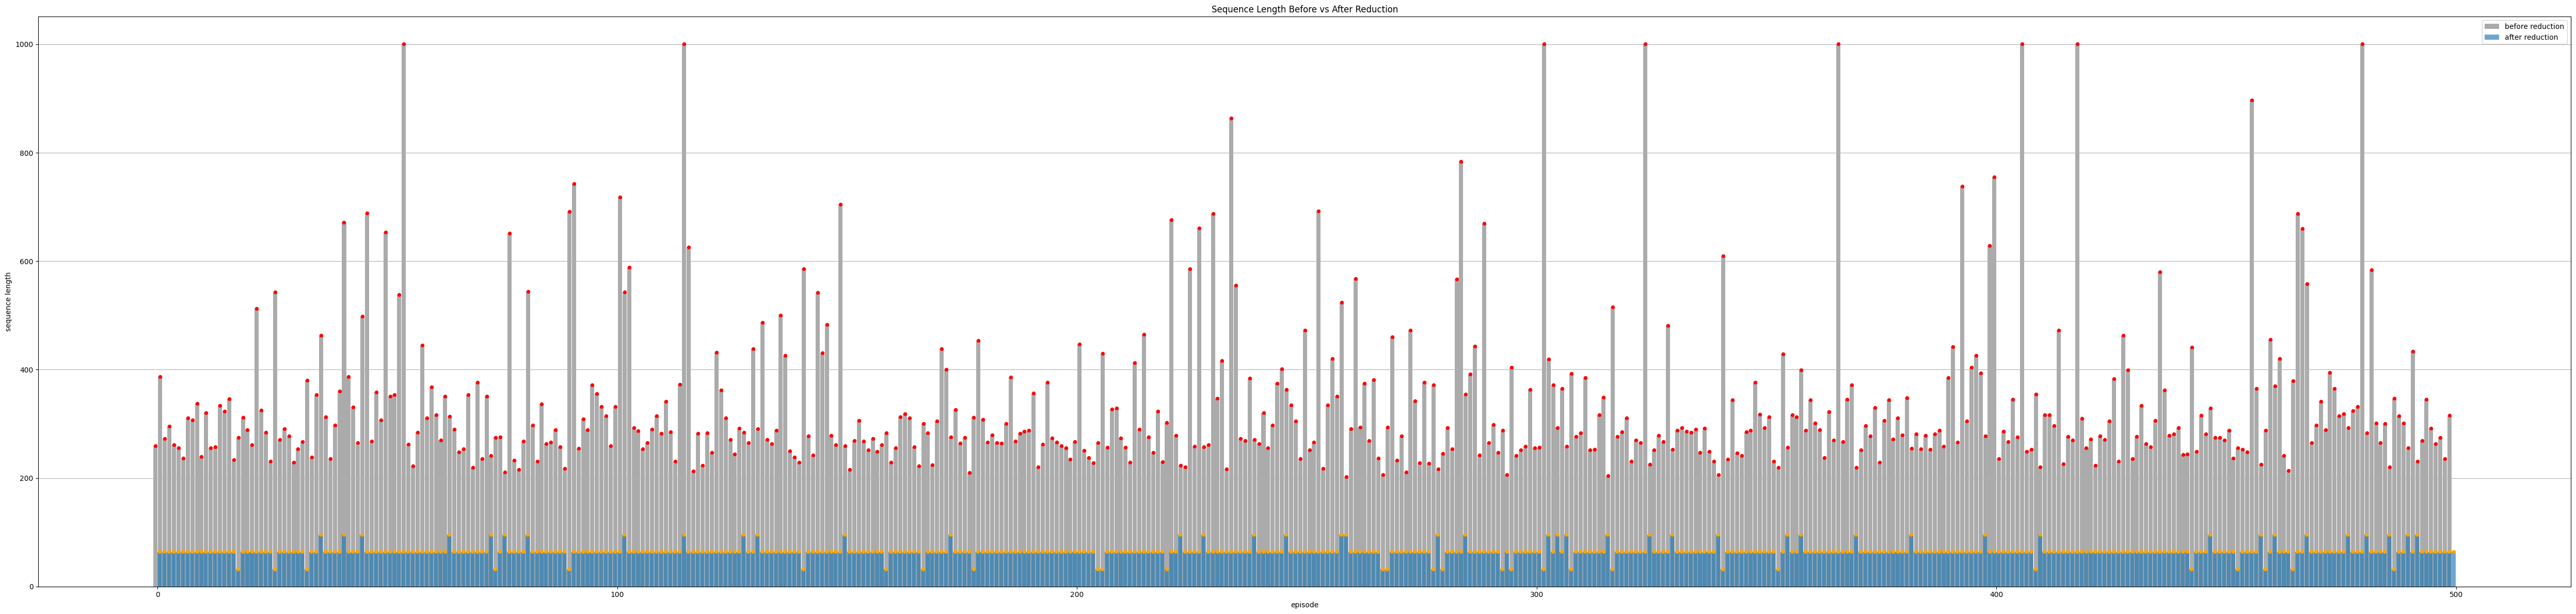

In [101]:
seq_lengths_after = [int(np.sum(np.sum(seq, axis=(1, 2)) > 0)) for seq in frames_seqs]
seq_lengths_before = episode_lengths
episode_ids = np.arange(len(seq_lengths_before))

plt.figure(figsize=(50, 12))
w = 0.9

x_before = episode_ids - w/2
x_after = episode_ids + w/2

plt.bar(x_before, seq_lengths_before, width=w, color="tab:gray", alpha=0.65, label="before reduction")
plt.bar(x_after, seq_lengths_after, width=w, color="tab:blue", alpha=0.65, label="after reduction")

plt.scatter(x_before, seq_lengths_before, color="red", s=18, zorder=3)
plt.scatter(x_after, seq_lengths_after, color="orange", s=18, zorder=3)

plt.xlabel("episode")
plt.ylabel("sequence length")
plt.title("Sequence Length Before vs After Reduction")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


After Reduction

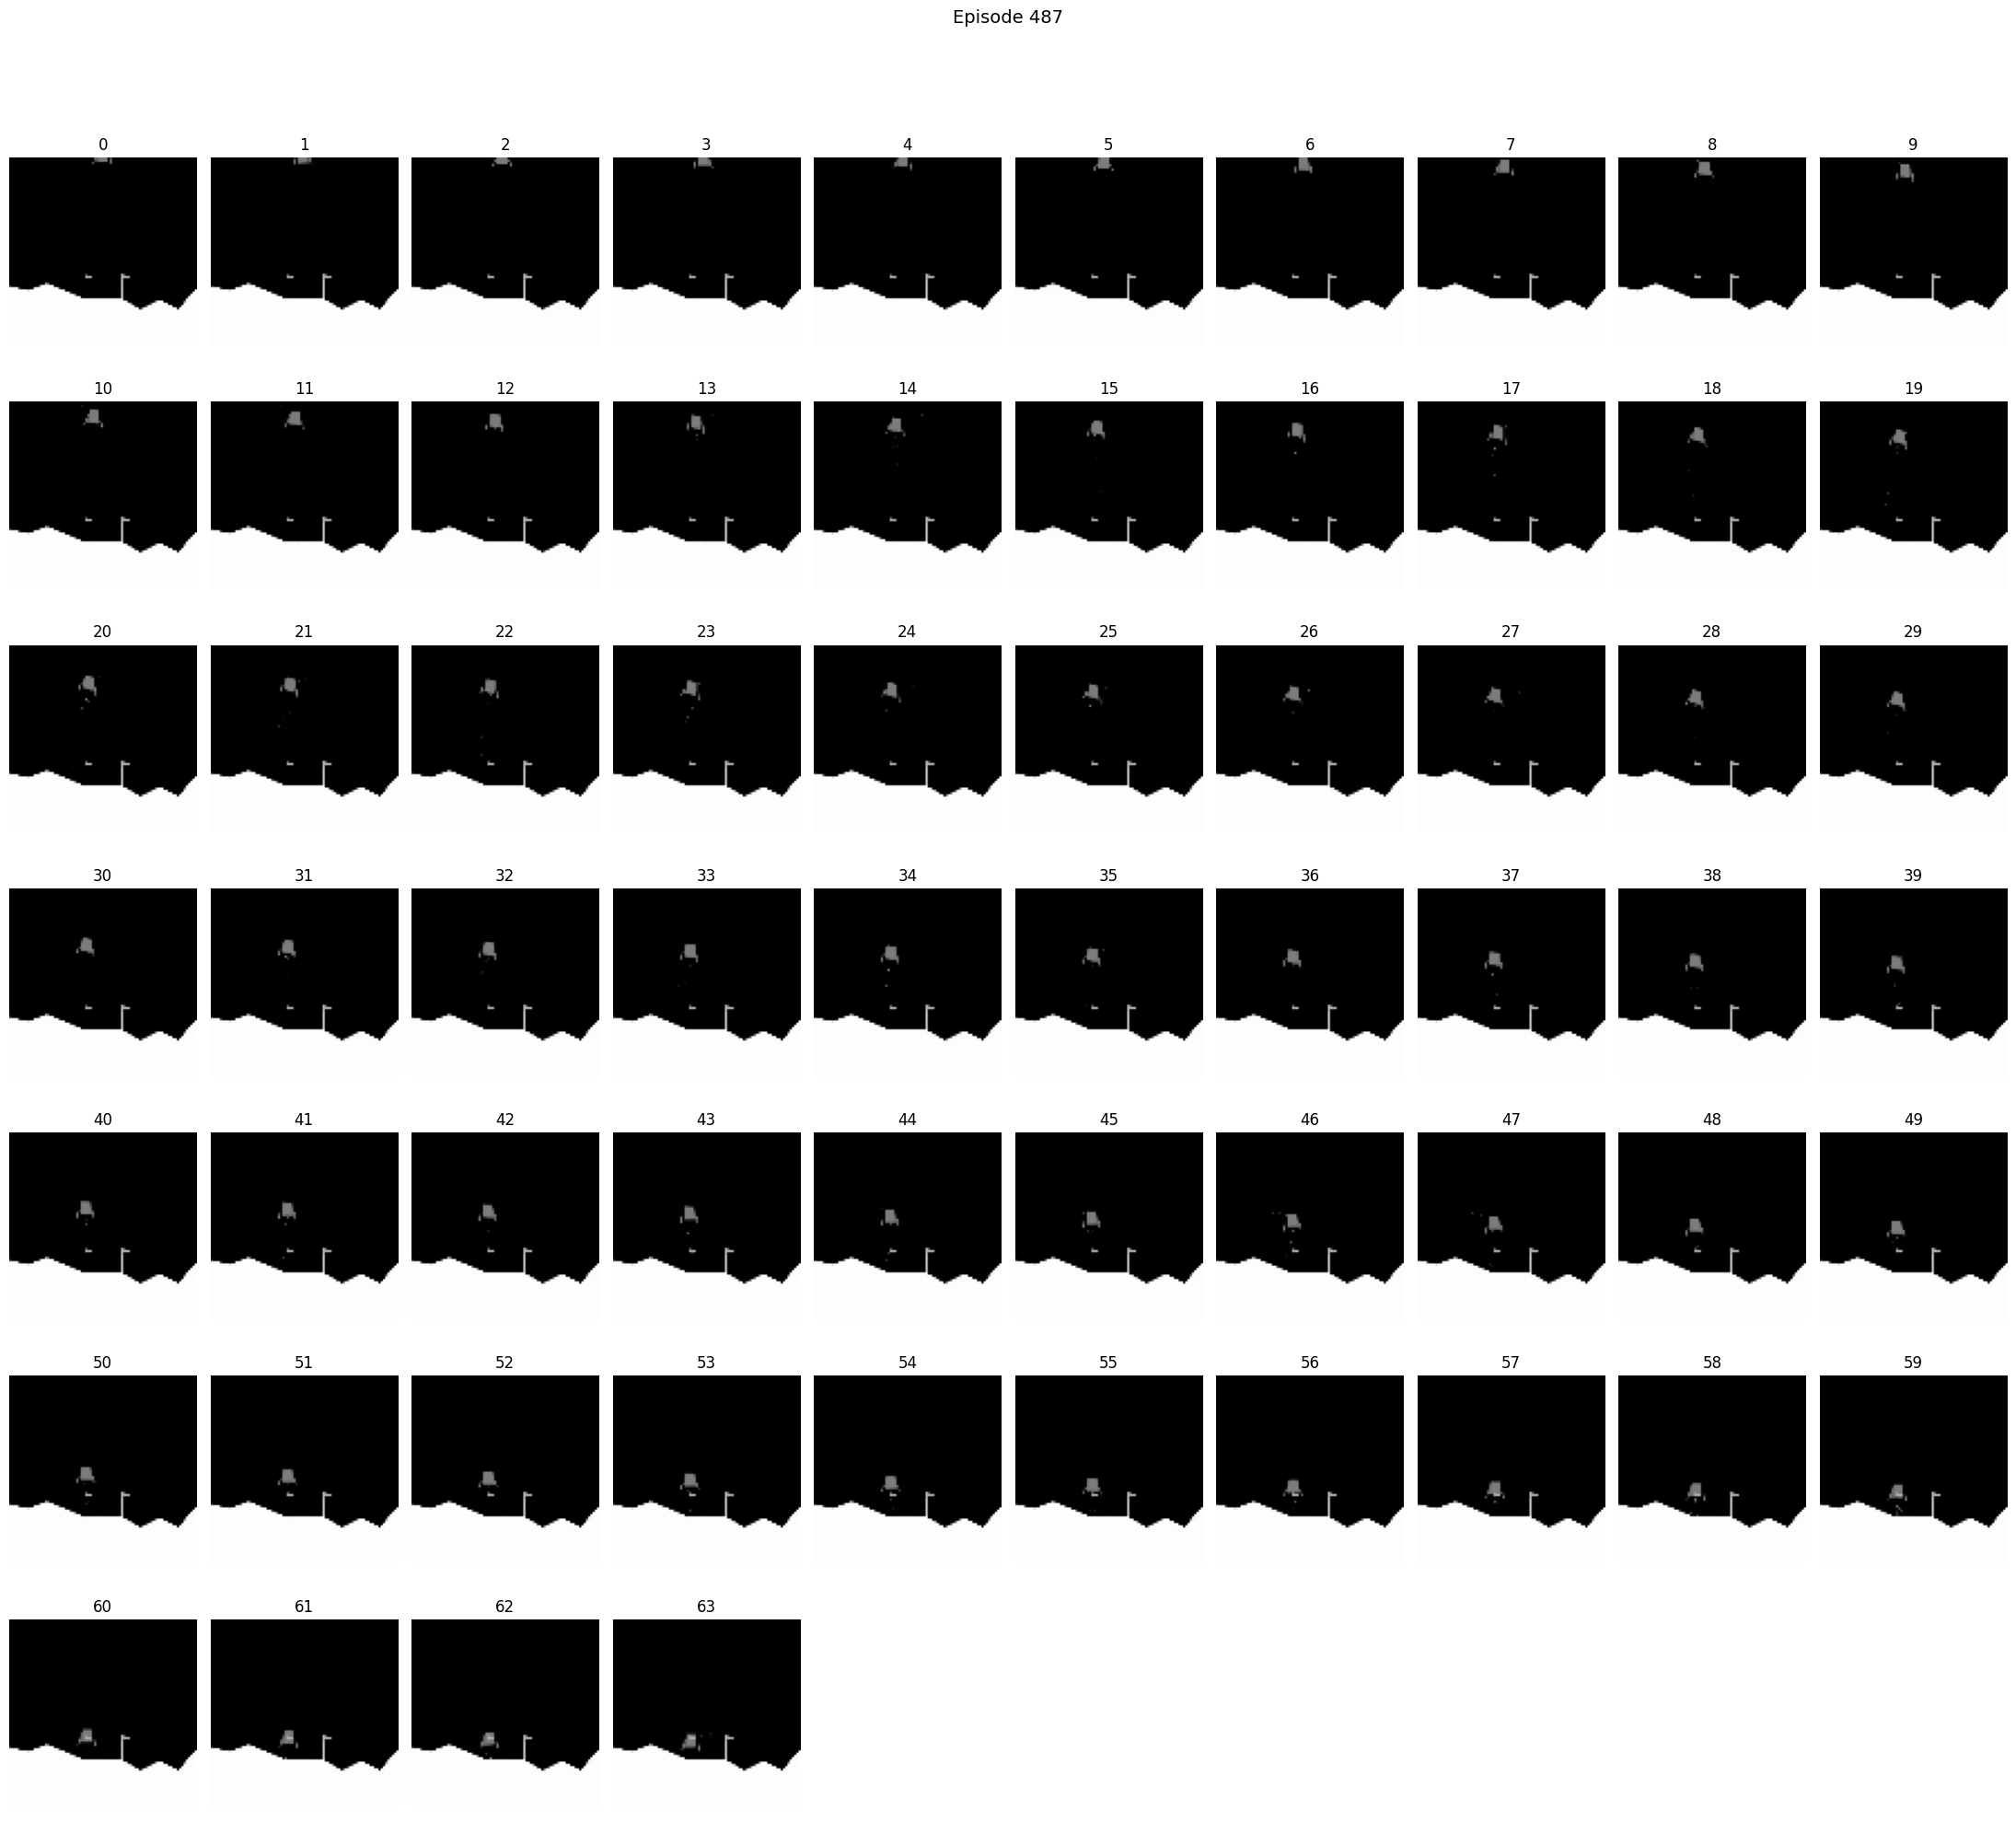

In [102]:
import random

# Sample one random reduced episode for inspection.
k = random.randrange(len(frames_seqs))
seq = frames_seqs[k]

# Remove zero-padded tail frames before visualization.
valid_len = int(np.sum(np.sum(seq, axis=(1, 2)) > 0))
seq = seq[:valid_len]

# Build a simple grid layout for the episode frames.
max_cols = 10
n = len(seq)
ncols = min(max_cols, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.8 * nrows))
axes = np.array(axes, dtype=object).reshape(nrows, ncols)

# Plot each frame in temporal order.
for i in range(nrows * ncols):
    r, c = divmod(i, ncols)

    if i < n:
        axes[r, c].imshow(seq[i], cmap="gray")
        axes[r, c].set_title(f"{i}")
        axes[r, c].axis("off")
    else:
        axes[r, c].axis("off")

# Add the episode title above the full grid.
plt.suptitle(f"Episode {k}", fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


Before Reduction

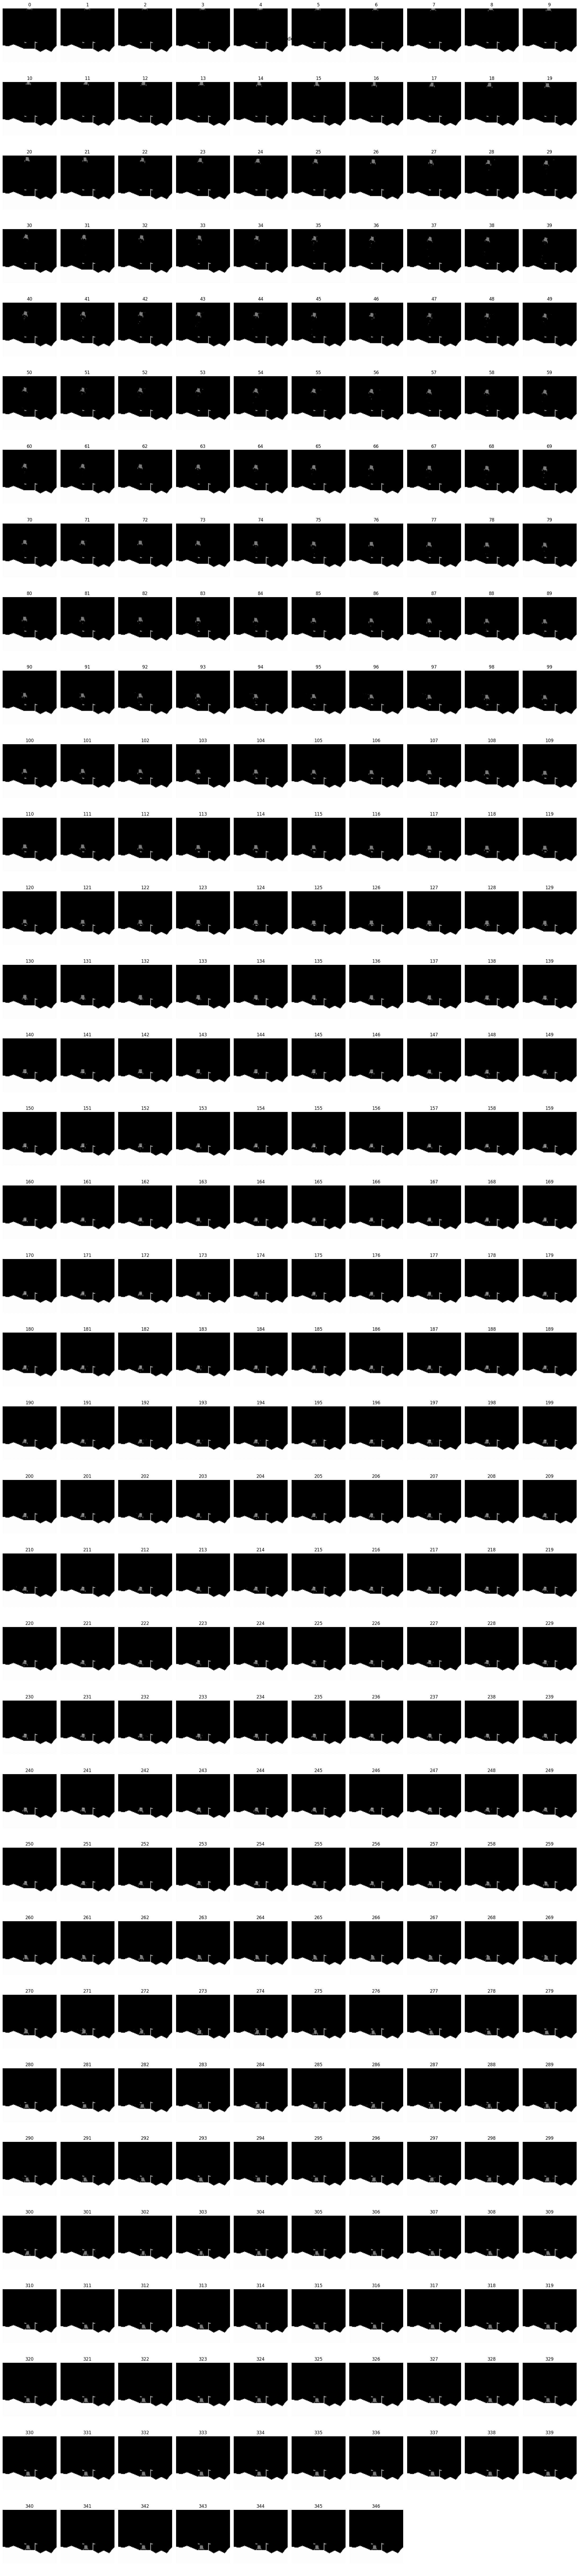

In [103]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Reuse the same episode index as in the reduced-sequence visualization.
EPISODE_NUM = k

# Load the original raw episode frames in numeric order.
video_dirs = sorted([p for p in FRAMES_ROOT.iterdir() if p.is_dir()], key=lambda p: int(p.name))
video_dir = next(p for p in video_dirs if int(p.name) == EPISODE_NUM)

frames = sorted(video_dir.glob("*.png"), key=lambda p: int(p.stem))
seq = [np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0 for p in frames]

# Build a grid layout for the raw episode frames.
max_cols = 10
n = len(seq)
ncols = min(max_cols, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.8 * nrows))
axes = np.array(axes, dtype=object).reshape(nrows, ncols)

# Plot the full original episode.
for i in range(nrows * ncols):
    r, c = divmod(i, ncols)

    if i < n:
        axes[r, c].imshow(seq[i], cmap="gray")
        axes[r, c].set_title(f"{i}")
        axes[r, c].axis("off")
    else:
        axes[r, c].axis("off")

# Add the episode title.
fig.suptitle(f"Episode {EPISODE_NUM}", fontsize=14)
plt.tight_layout()
plt.show()


### PreDataset

In [104]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch

# -------------------------
# Build the sequential predataset
# -------------------------

SEQ_LEN = 32

def justify_func(frame_seq, seq_len=32):
    n = (len(frame_seq) // seq_len) * seq_len
    return frame_seq[:n]

video_dirs = sorted([p for p in FRAMES_ROOT.iterdir() if p.is_dir()], key=lambda p: int(p.name))

predataset = []
episode_lengths_raw = []
episode_lengths_reduced = []

print(f'{"episode":^10} | {"total_frames":^14} | {"reduced_frames":^16} | {"num_chunks":^12} | {"reduction_%":^12}')
print("-" * 82)

for i, video_dir in enumerate(video_dirs, 1):
    x = load_episode(video_dir)
    T = len(x)
    episode_lengths_raw.append(T)

    if T < SEQ_LEN:
        episode_lengths_reduced.append(0)
        print(f"{i:^10} | {T:^14} | {0:^16} | {0:^12} | {100.00:^12.2f}")
        continue

    curr_frame = x[0]
    frame_seq = [curr_frame]

    for t in range(1, T):
        next_frame = x[t]
        if sim_func(curr_frame, next_frame):
            curr_frame = next_frame
            frame_seq.append(curr_frame)

    frame_seq = justify_func(frame_seq, SEQ_LEN)
    reduced_len = len(frame_seq)
    n_chunks = reduced_len // SEQ_LEN

    if reduced_len == 0:
        episode_lengths_reduced.append(0)
        print(f"{i:^10} | {T:^14} | {0:^16} | {0:^12} | {100.00:^12.2f}")
        continue

    reduction_pct = 100.0 * (1.0 - (reduced_len / T))

    predataset.append(
        torch.tensor(np.stack(frame_seq), dtype=torch.float32).unsqueeze(1)
    )
    episode_lengths_reduced.append(reduced_len)

    print(f"{i:^10} | {T:^14} | {reduced_len:^16} | {n_chunks:^12} | {reduction_pct:^12.2f}")

predataset_obj = {
    "episodes": predataset,
    "episode_lengths_raw": torch.tensor(episode_lengths_raw, dtype=torch.int32),
    "episode_lengths_reduced": torch.tensor(episode_lengths_reduced, dtype=torch.int32),
}

SEQ_PREDATASET_PT = SEQ_RUN_DIR / "predataset.pt"
torch.save(predataset_obj, SEQ_PREDATASET_PT)

print()
print(f'{"num_episodes":<24}: {len(predataset)}')
print(f'{"saved":<24}: {SEQ_PREDATASET_PT}')

 episode   |  total_frames  |  reduced_frames  |  num_chunks  | reduction_% 
----------------------------------------------------------------------------------
    1      |      260       |        64        |      2       |    75.38    
    2      |      387       |        64        |      2       |    83.46    
    3      |      273       |        64        |      2       |    76.56    
    4      |      296       |        64        |      2       |    78.38    
    5      |      261       |        64        |      2       |    75.48    
    6      |      256       |        64        |      2       |    75.00    
    7      |      237       |        64        |      2       |    73.00    
    8      |      311       |        64        |      2       |    79.42    
    9      |      307       |        64        |      2       |    79.15    
    10     |      338       |        64        |      2       |    81.07    
    11     |      240       |        64        |      2       |    73.

Check PreDataset random seq

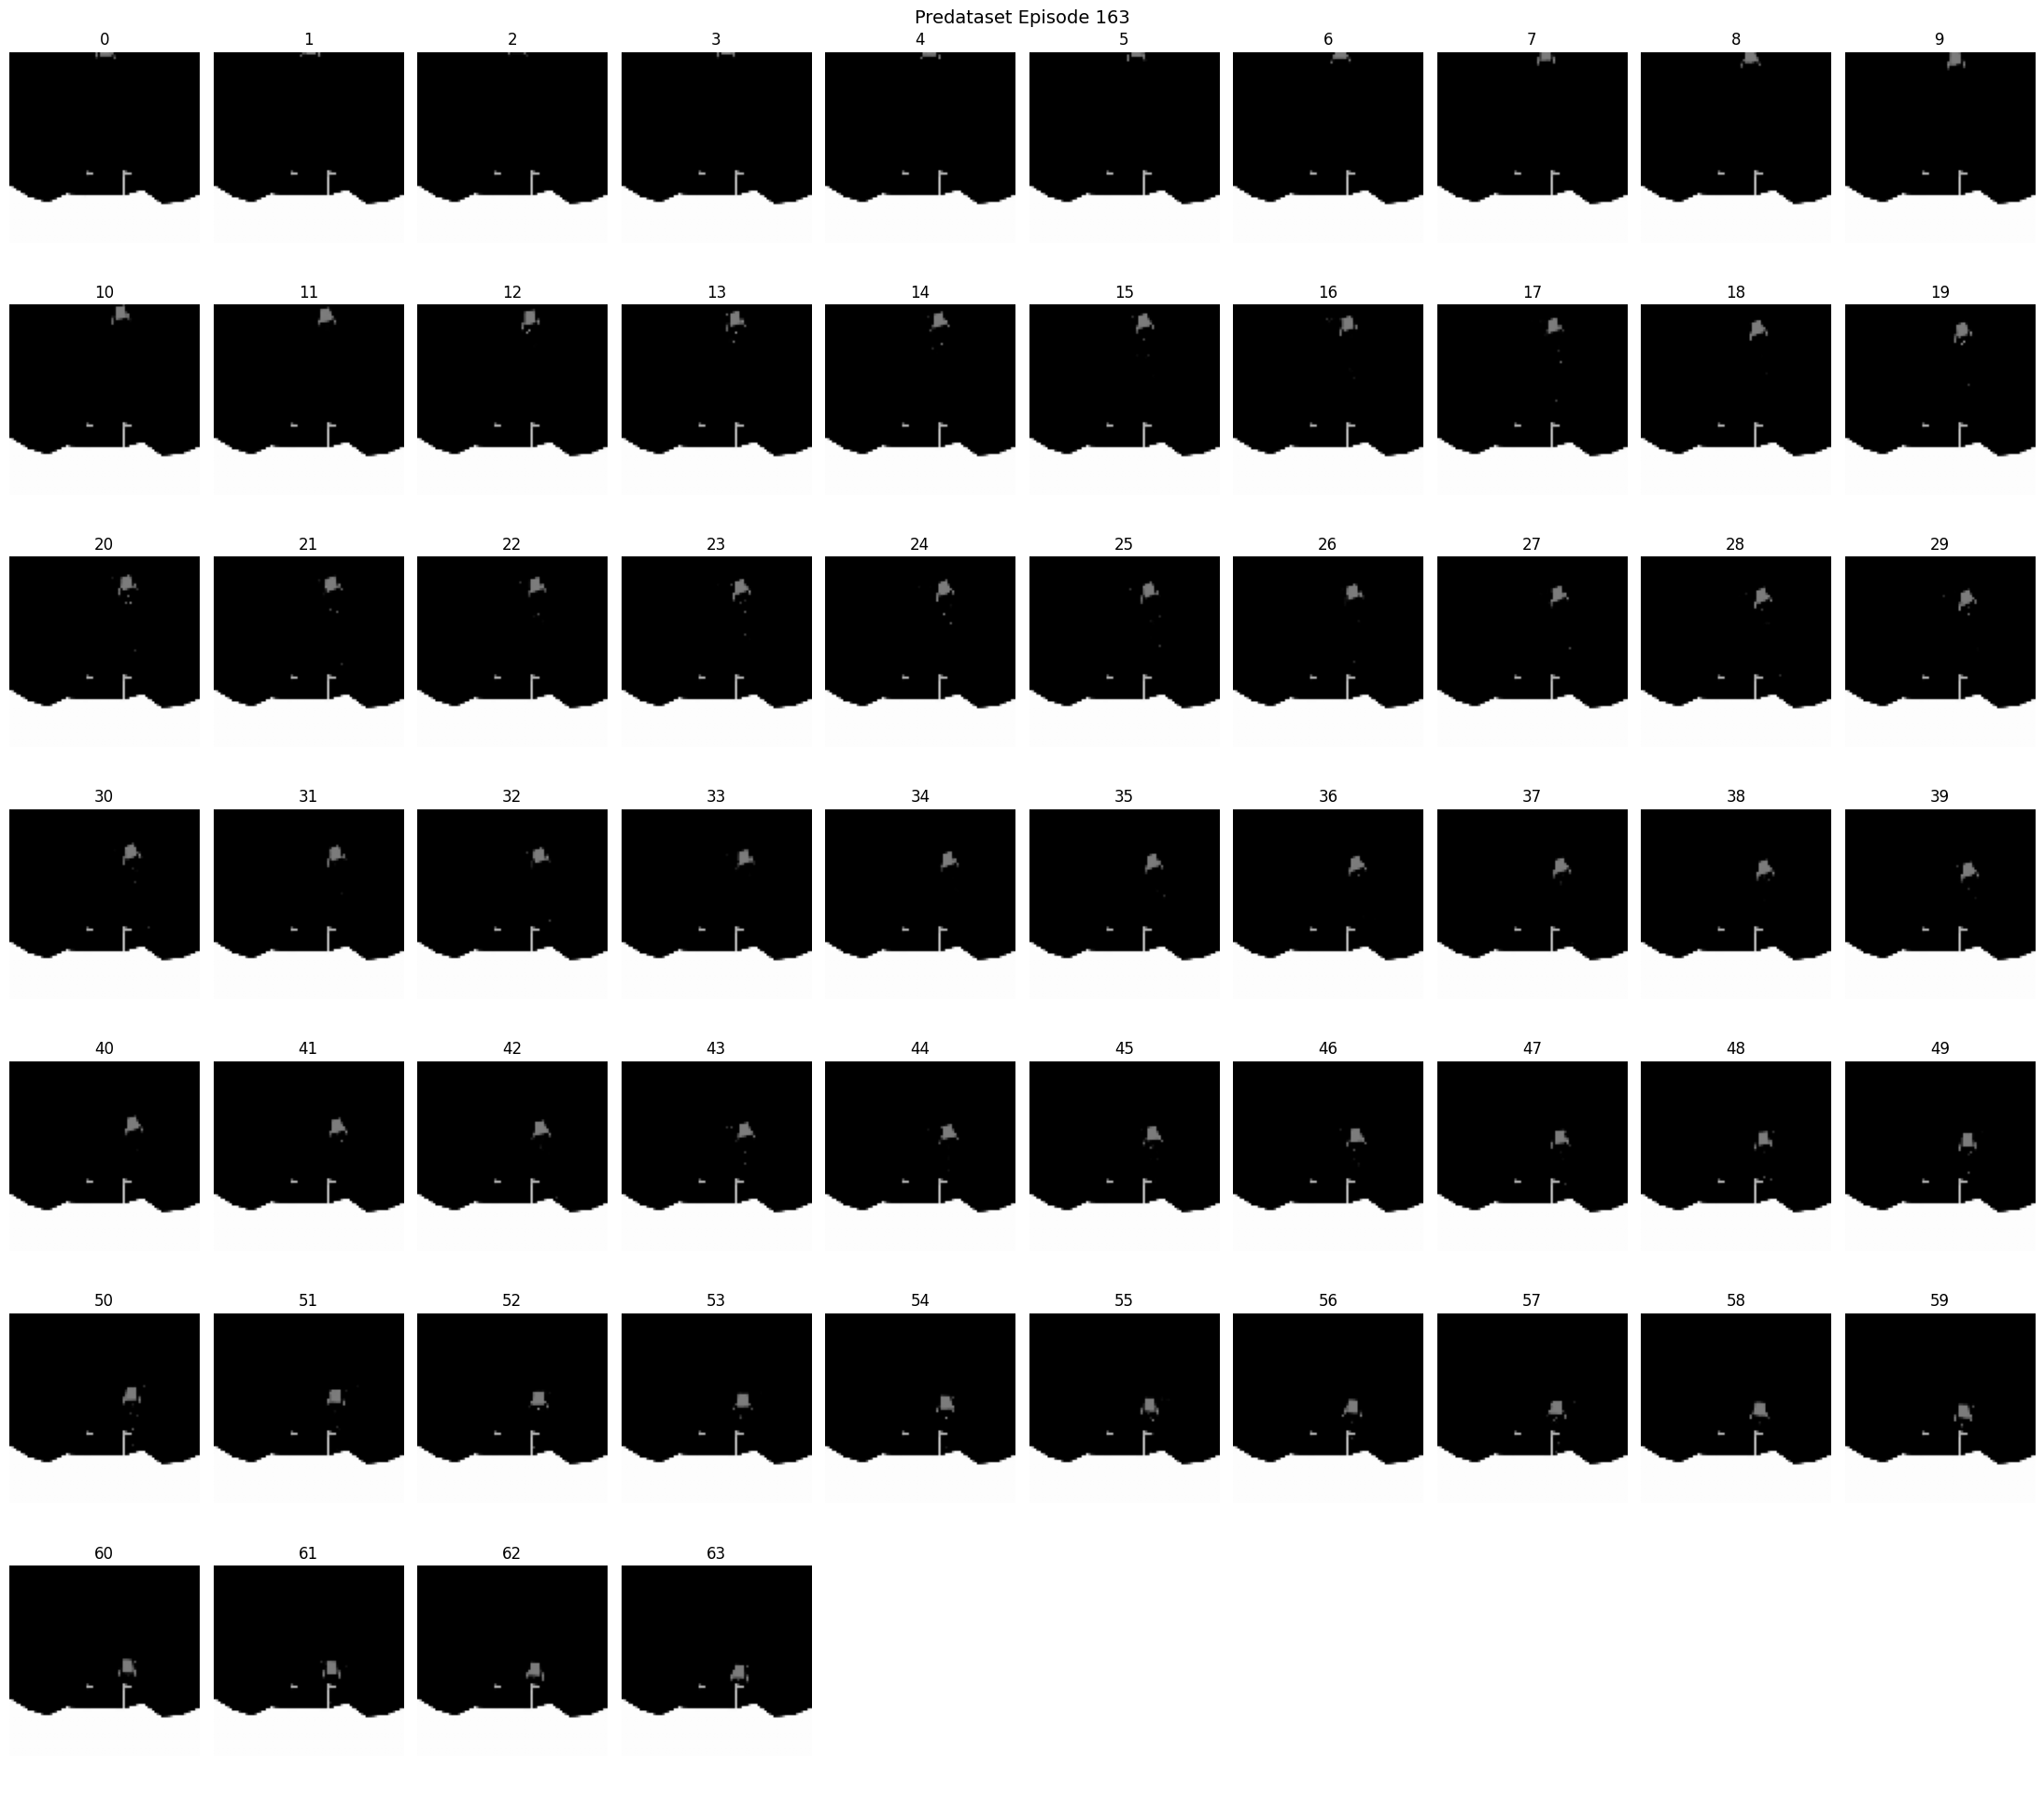

In [105]:
import matplotlib.pyplot as plt
import random
import numpy as np

# Sample one random reduced episode from the predataset.
k = random.randrange(len(predataset))
seq = predataset[k].squeeze(1).cpu().numpy()

# Build a visualization grid for the reduced episode frames.
max_cols = 10
n = len(seq)
ncols = min(max_cols, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.8 * nrows))
axes = np.array(axes, dtype=object).reshape(nrows, ncols)

# Plot each reduced frame in temporal order.
for i in range(nrows * ncols):
    r, c = divmod(i, ncols)

    if i < n:
        axes[r, c].imshow(seq[i], cmap="gray")
        axes[r, c].set_title(f"{i}")
        axes[r, c].axis("off")
    else:
        axes[r, c].axis("off")

# Add the episode title above the grid.
fig.suptitle(f"Predataset Episode {k}", fontsize=14)
plt.tight_layout()
plt.show()


### Dataset

In [106]:
from pathlib import Path
import torch
import numpy as np

# -------------------------
# Build sequential train/test datasets from the predataset
# -------------------------

# Define the chunk length and split settings.
SEQ_LEN = 32
TEST_RATIO = 0.2
SEED = 42

# Load the reduced full-episode predataset.
data = torch.load(SEQ_PREDATASET_PT)
episodes = data["episodes"]

chunks = []
chunk_lengths = []
episode_ids = []

print(f'{"episode":^10} | {"reduced_frames":^16} | {"num_chunks":^12}')
print("-" * 46)

# Split each reduced episode into fixed-length chunks.
for ep_idx, ep in enumerate(episodes):
    T = int(ep.shape[0])

    # Handle empty reduced episodes explicitly.
    if T == 0:
        print(f"{ep_idx:^10} | {0:^16} | {0:^12}")
        continue

    n_chunks = int(np.ceil(T / SEQ_LEN))

    for start in range(0, T, SEQ_LEN):
        chunk = ep[start:start + SEQ_LEN]

        # Pad the last chunk with black frames if needed.
        valid_len = int(chunk.shape[0])
        if valid_len < SEQ_LEN:
            pad = torch.zeros((SEQ_LEN - valid_len, 1, 84, 84), dtype=chunk.dtype)
            chunk = torch.cat([chunk, pad], dim=0)

        chunks.append(chunk)
        chunk_lengths.append(valid_len)
        episode_ids.append(ep_idx)

    print(f"{ep_idx:^10} | {T:^16} | {n_chunks:^12}")

# Stack all chunks into tensors.
x = torch.stack(chunks)
lengths = torch.tensor(chunk_lengths, dtype=torch.int32)
episode_ids = torch.tensor(episode_ids, dtype=torch.int32)

# Split at the episode level to avoid leakage across train and test.
num_episodes = len(episodes)
all_episode_ids = np.arange(num_episodes)

rng = np.random.default_rng(SEED)
rng.shuffle(all_episode_ids)

test_size = int(np.ceil(num_episodes * TEST_RATIO))
test_episode_ids = set(all_episode_ids[:test_size].tolist())
train_episode_ids = set(all_episode_ids[test_size:].tolist())

train_mask = torch.tensor([int(ep.item()) in train_episode_ids for ep in episode_ids], dtype=torch.bool)
test_mask = torch.tensor([int(ep.item()) in test_episode_ids for ep in episode_ids], dtype=torch.bool)

# Package the sequential train and test datasets.
seq_train_data = {
    "x": x[train_mask],
    "lengths": lengths[train_mask],
    "episode_ids": episode_ids[train_mask],
    "seq_len": SEQ_LEN,
}

seq_test_data = {
    "x": x[test_mask],
    "lengths": lengths[test_mask],
    "episode_ids": episode_ids[test_mask],
    "seq_len": SEQ_LEN,
}

# Save both sequential datasets inside the current run folder.
torch.save(seq_train_data, SEQ_TRAIN_PT)
torch.save(seq_test_data, SEQ_TEST_PT)

print()
print(f'{"train shape":<20}: {seq_train_data["x"].shape}')
print(f'{"test shape":<20}: {seq_test_data["x"].shape}')
print(f'{"saved train":<20}: {SEQ_TRAIN_PT}')
print(f'{"saved test":<20}: {SEQ_TEST_PT}')


 episode   |  reduced_frames  |  num_chunks 
----------------------------------------------
    0      |        64        |      2      
    1      |        64        |      2      
    2      |        64        |      2      
    3      |        64        |      2      
    4      |        64        |      2      
    5      |        64        |      2      
    6      |        64        |      2      
    7      |        64        |      2      
    8      |        64        |      2      
    9      |        64        |      2      
    10     |        64        |      2      
    11     |        64        |      2      
    12     |        64        |      2      
    13     |        64        |      2      
    14     |        64        |      2      
    15     |        64        |      2      
    16     |        64        |      2      
    17     |        32        |      1      
    18     |        64        |      2      
    19     |        64        |      2      
    20  

### DataLoader

In [107]:
import torch
from torch.utils.data import Dataset, DataLoader

# -------------------------
# Load sequential train/test datasets
# -------------------------

# Load the saved sequential train and test dataset files.
train_data = torch.load(SEQ_TRAIN_PT)
test_data = torch.load(SEQ_TEST_PT)

# -------------------------
# Dataset / DataLoader
# -------------------------

# Dataset wrapper for fixed-length sequential chunks.
class SequentialChunkDataset(Dataset):
    def __init__(self, x, lengths, episode_ids):
        self.x = x
        self.lengths = lengths
        self.episode_ids = episode_ids

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            "x": self.x[idx],
            "length": self.lengths[idx],
            "episode_id": self.episode_ids[idx],
        }

# Build train and test sequential datasets.
train_ds = SequentialChunkDataset(
    train_data["x"],
    train_data["lengths"],
    train_data["episode_ids"],
)

test_ds = SequentialChunkDataset(
    test_data["x"],
    test_data["lengths"],
    test_data["episode_ids"],
)

# Build train and test sequential dataloaders.
seq_train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
seq_test_dataloader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Pull one batch from each dataloader for a quick shape check.
train_batch = next(iter(seq_train_dataloader))
test_batch = next(iter(seq_test_dataloader))

print("train batch x.shape         =", train_batch["x"].shape)
print("train batch length.shape    =", train_batch["length"].shape)
print("train batch episode_id.shape=", train_batch["episode_id"].shape)
print()
print("test batch x.shape          =", test_batch["x"].shape)
print("test batch length.shape     =", test_batch["length"].shape)
print("test batch episode_id.shape =", test_batch["episode_id"].shape)


train batch x.shape         = torch.Size([32, 32, 1, 84, 84])
train batch length.shape    = torch.Size([32])
train batch episode_id.shape= torch.Size([32])

test batch x.shape          = torch.Size([32, 32, 1, 84, 84])
test batch length.shape     = torch.Size([32])
test batch episode_id.shape = torch.Size([32])


### Model

In [108]:
from typing import Optional, Tuple

import torch
import torch.nn as nn

# -------------------------
# Sequential latent model
# -------------------------

# LSTM that predicts the next latent vector from a sequence of previous latents.
class LatentLSTM(nn.Module):
    def __init__(self, z_dim, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=z_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, z_dim),
        )

    def forward(
        self,
        z_seq: torch.Tensor,
        lengths: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        if lengths is None:
            h_seq, (h_n, _) = self.lstm(z_seq)
        else:
            packed = nn.utils.rnn.pack_padded_sequence(
                z_seq,
                lengths.to(dtype=torch.int64, device="cpu"),
                batch_first=True,
                enforce_sorted=False,
            )
            packed_out, (h_n, _) = self.lstm(packed)
            h_seq, _ = nn.utils.rnn.pad_packed_sequence(
                packed_out,
                batch_first=True,
                total_length=z_seq.size(1),
            )

        h_last = h_n[-1]
        z_pred = self.head(h_last)
        return h_seq, z_pred


In [109]:
lstm_model = LatentLSTM(
    z_dim=Z_DIM,
    hidden_dim=256,
    num_layers=2,
    dropout=0.1,
).to(DEVICE)

print(lstm_model)


LatentLSTM(
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.1)
  (head): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
  )
)


### Test Spin

In [110]:
import matplotlib.pyplot as plt
import torch

# -------------------------
# Prepare one sequential sample for qualitative inspection
# -------------------------

# Switch both models to evaluation mode.
ae_model.eval()
lstm_model.eval()

# Read one training batch from the sequential dataloader.
batch = next(iter(seq_train_dataloader))
x = batch["x"].to(DEVICE)
lengths = batch["length"].to(DEVICE)

# Select one sequence from the batch.
i = 0
x_seq = x[i:i+1]
seq_len = int(lengths[i].item())

with torch.no_grad():
    # Split the sequence into input frames and the final target frame.
    x_input = x_seq[:, :seq_len-1]
    x_true = x_seq[:, seq_len-1]

    # Encode the input frames into latent vectors.
    z_list = []
    for t in range(seq_len - 1):
        _, z_t = ae_model(x_input[:, t])
        z_list.append(z_t)

    z_input = torch.stack(z_list, dim=1)

    # Encode the true next frame into its latent target.
    _, z_true = ae_model(x_true)

    # Predict the next latent from the latent input sequence.
    h_seq, z_pred = lstm_model(z_input)
    print("h_seq shape:", h_seq.shape)

    # Decode the predicted latent back into image space.
    x_pred = ae_model.decoder_fc(z_pred).view(-1, 256, 10, 10)
    x_pred = ae_model.decoder(x_pred)
    x_pred = x_pred[:, :, :84, :84].cpu()

# Convert tensors to NumPy for plotting.
z_input_np = z_input.squeeze(0).cpu().numpy()
z_true_np = z_true.squeeze(0).cpu().numpy()
z_pred_np = z_pred.squeeze(0).cpu().numpy()

h_seq shape: torch.Size([1, 31, 256])


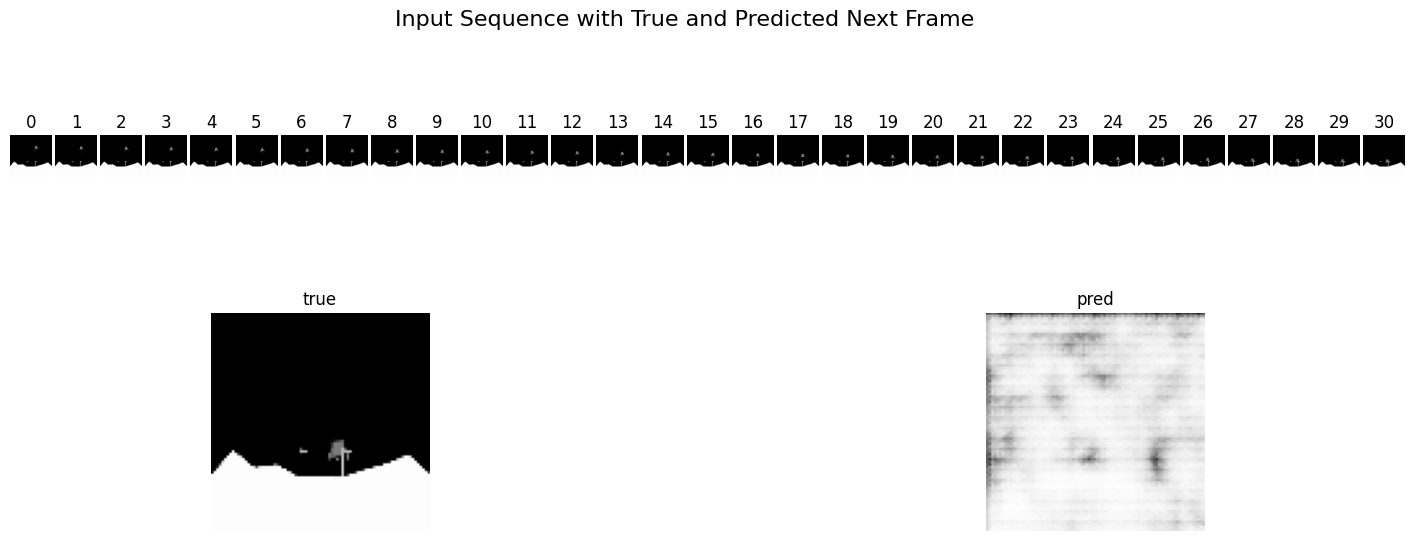

In [111]:
# -------------------------
# Visualize input frames and next-frame prediction
# -------------------------

# Create a figure with one row of input frames and one row for true vs predicted next frame.
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Input Sequence with True and Predicted Next Frame", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)

top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

# Plot the input frame sequence.
for t in range(seq_len - 1):
    top_axes[t].imshow(x_input[0, t, 0].cpu(), cmap="gray")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

# Plot the true next frame.
ax_true.imshow(x_true[0, 0].cpu(), cmap="gray")
ax_true.set_title("true")
ax_true.axis("off")

# Plot the decoded predicted next frame.
ax_pred.imshow(x_pred[0, 0], cmap="gray")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.show()


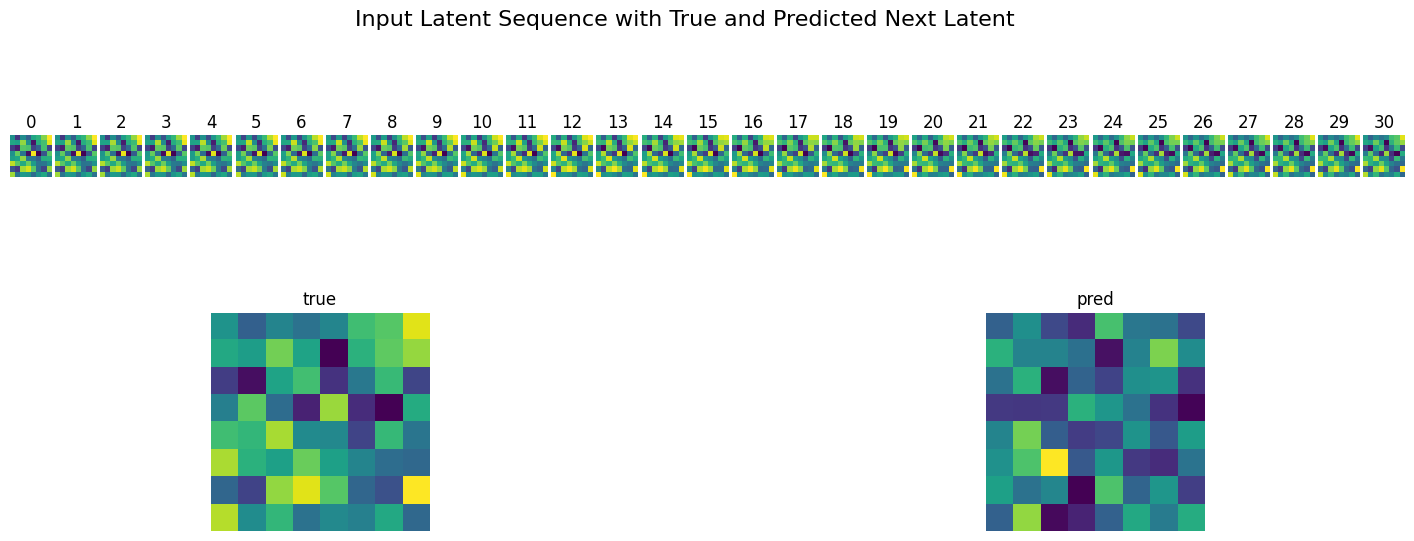

In [112]:
# -------------------------
# Visualize input latents and next-latent prediction
# -------------------------

# Create a figure with one row of input latent grids and one row for true vs predicted next latent.
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Input Latent Sequence with True and Predicted Next Latent", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)

top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

# Plot the latent input sequence as 8x8 grids.
for t in range(seq_len - 1):
    top_axes[t].imshow(z_input_np[t].reshape(8, 8), cmap="viridis")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

# Plot the true next latent.
ax_true.imshow(z_true_np.reshape(8, 8), cmap="viridis")
ax_true.set_title("true")
ax_true.axis("off")

# Plot the predicted next latent.
ax_pred.imshow(z_pred_np.reshape(8, 8), cmap="viridis")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.show()


### Train

In [113]:
import time
import torch
import torch.nn.functional as F

# -------------------------
# LSTM training setup
# -------------------------

# Training hyperparameters for the sequential latent model.
LSTM_EPOCHS = 10
LSTM_LR = 3e-4
LSTM_GRAD_CLIP = 1.0

# Freeze the autoencoder and use it only as a latent encoder.
ae_model.eval()
for p in ae_model.parameters():
    p.requires_grad = False

# Initialize the LSTM that predicts the next latent vector.
lstm_model = LatentLSTM(
    z_dim=Z_DIM,
    hidden_dim=256,
    num_layers=2,
    dropout=0.1,
).to(DEVICE)

opt = torch.optim.Adam(lstm_model.parameters(), lr=LSTM_LR)

train_losses = []
t0 = time.time()

# -------------------------
# LSTM training loop
# -------------------------

# Train the LSTM to predict the next latent from a latent input sequence.
for epoch in range(1, LSTM_EPOCHS + 1):
    lstm_model.train()
    ep_loss = 0.0
    n_b = 0

    # Iterate over sequential train batches.
    for batch in seq_train_dataloader:
        x = batch["x"].to(DEVICE)
        lengths = batch["length"].to(DEVICE)

        z_inputs = []
        z_targets = []

        # Encode each valid sequence into latent inputs and latent targets.
        with torch.no_grad():
            for i in range(x.shape[0]):
                seq_len = int(lengths[i].item())
                if seq_len < 2:
                    continue

                x_valid  = x[i:i+1, :seq_len]
                x_input  = x_valid[:, :-1]
                x_target = x_valid[:, -1]

                z_list = []
                for t in range(x_input.shape[1]):
                    _, z_t = ae_model(x_input[:, t])
                    z_list.append(z_t)

                z_input = torch.stack(z_list, dim=1)
                _, z_target = ae_model(x_target)

                z_inputs.append(z_input.squeeze(0))
                z_targets.append(z_target.squeeze(0))

        # Skip empty batches after filtering.
        if len(z_inputs) == 0:
            continue

        # Pad the latent input sequences to a common batch length.
        input_lengths = torch.tensor([z.shape[0] for z in z_inputs], dtype=torch.int64, device=DEVICE)
        max_len = int(input_lengths.max().item())

        padded_inputs = []
        for z in z_inputs:
            if z.shape[0] < max_len:
                pad = torch.zeros(max_len - z.shape[0], z.shape[1], device=DEVICE, dtype=z.dtype)
                z = torch.cat([z, pad], dim=0)
            padded_inputs.append(z)

        z_inputs = torch.stack(padded_inputs, dim=0)
        z_targets = torch.stack(z_targets, dim=0)

        # Predict the next latent and optimize with MSE loss.
        h_seq, z_pred = lstm_model(z_inputs, lengths=input_lengths)
        loss = F.mse_loss(z_pred, z_targets)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), LSTM_GRAD_CLIP)
        opt.step()

        ep_loss += float(loss.item())
        n_b += 1

    # Store and print the epoch-level training loss.
    mean_ep = ep_loss / max(n_b, 1)
    train_losses.append(mean_ep)

    print(f"[LSTM] epoch {epoch:03d}/{LSTM_EPOCHS} mean_loss {mean_ep:.6f} | {time.time() - t0:.1f}s")


[LSTM] epoch 001/10 mean_loss 0.493911 | 44.5s
[LSTM] epoch 002/10 mean_loss 0.154188 | 88.6s
[LSTM] epoch 003/10 mean_loss 0.087328 | 131.8s
[LSTM] epoch 004/10 mean_loss 0.065896 | 173.3s
[LSTM] epoch 005/10 mean_loss 0.054021 | 214.6s
[LSTM] epoch 006/10 mean_loss 0.046923 | 255.5s
[LSTM] epoch 007/10 mean_loss 0.041447 | 296.4s
[LSTM] epoch 008/10 mean_loss 0.037458 | 337.6s
[LSTM] epoch 009/10 mean_loss 0.034843 | 379.5s
[LSTM] epoch 010/10 mean_loss 0.033007 | 421.3s


### Eval

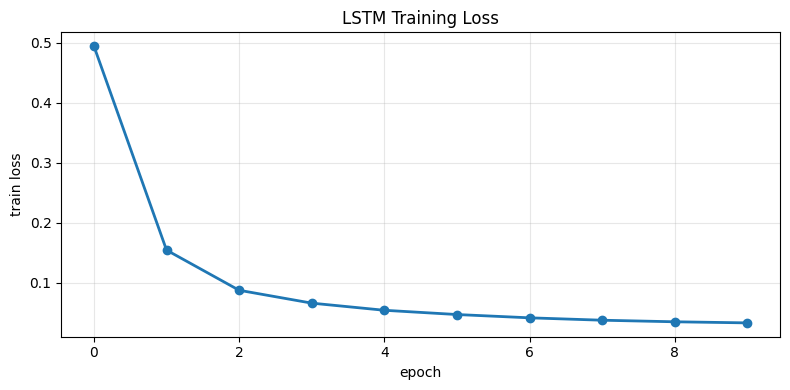

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'o-',lw=2)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("LSTM Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_36082/1141944387.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


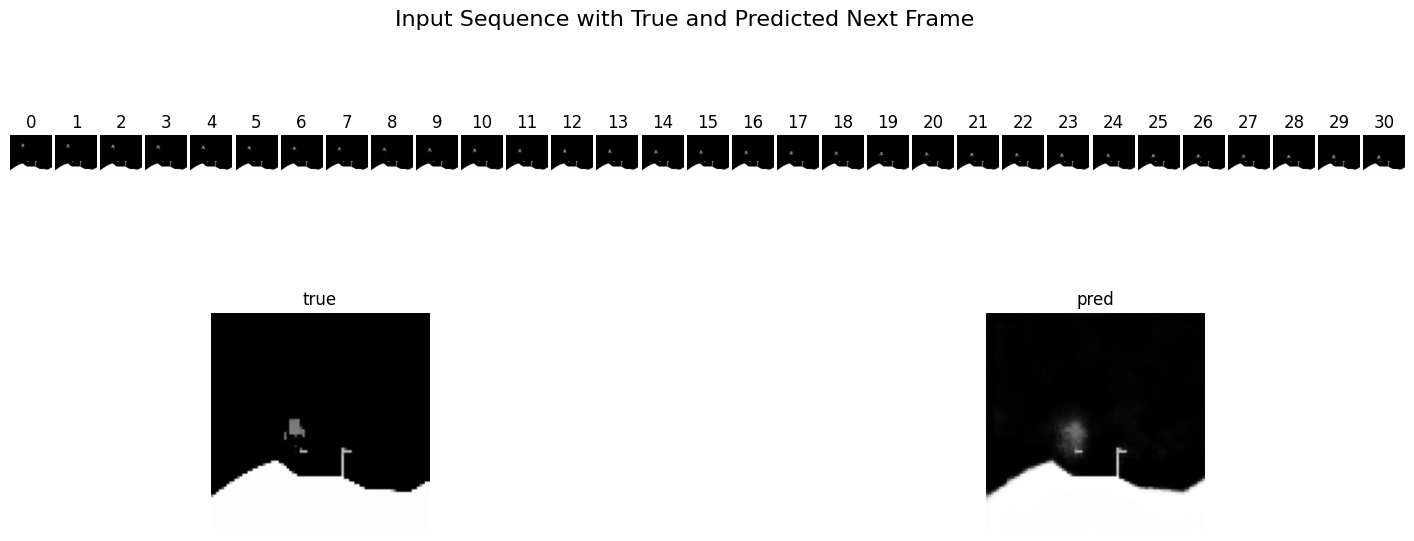

In [115]:
import matplotlib.pyplot as plt
import torch

# Evaluation mode.
ae_model.eval()
lstm_model.eval()

# One batch from test dataloader.
batch = next(iter(seq_test_dataloader))
x = batch["x"].to(DEVICE)
lengths = batch["length"].to(DEVICE)

# Pick one random sequence.
i = torch.randint(0, x.shape[0], (1,)).item()
seq_len = int(lengths[i].item())

with torch.no_grad():
    # Split into input frames and true next frame.
    x_valid = x[i:i+1, :seq_len]
    x_input = x_valid[:, :-1]
    x_true = x_valid[:, -1]

    # Encode input frames into latents.
    z_list = []
    for t in range(x_input.shape[1]):
        _, z_t = ae_model(x_input[:, t])
        z_list.append(z_t)

    z_input = torch.stack(z_list, dim=1)

    # Predict next latent.
    h_seq, z_pred = lstm_model(z_input)

    # Decode predicted latent into image.
    x_pred = ae_model.decoder_fc(z_pred).view(-1, 256, 10, 10)
    x_pred = ae_model.decoder(x_pred)
    x_pred = x_pred[:, :, :84, :84].cpu()

# Plot input sequence, true next frame, and predicted next frame.
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Input Sequence with True and Predicted Next Frame", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)

top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

for t in range(seq_len - 1):
    top_axes[t].imshow(x_input[0, t, 0].cpu(), cmap="gray")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

ax_true.imshow(x_true[0, 0].cpu(), cmap="gray")
ax_true.set_title("true")
ax_true.axis("off")

ax_pred.imshow(x_pred[0, 0], cmap="gray")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.tight_layout()
plt.savefig(SEQ_RUN_DIR / "next_frame_prediction.png", dpi=150)
plt.show()

/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_36082/3563051101.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


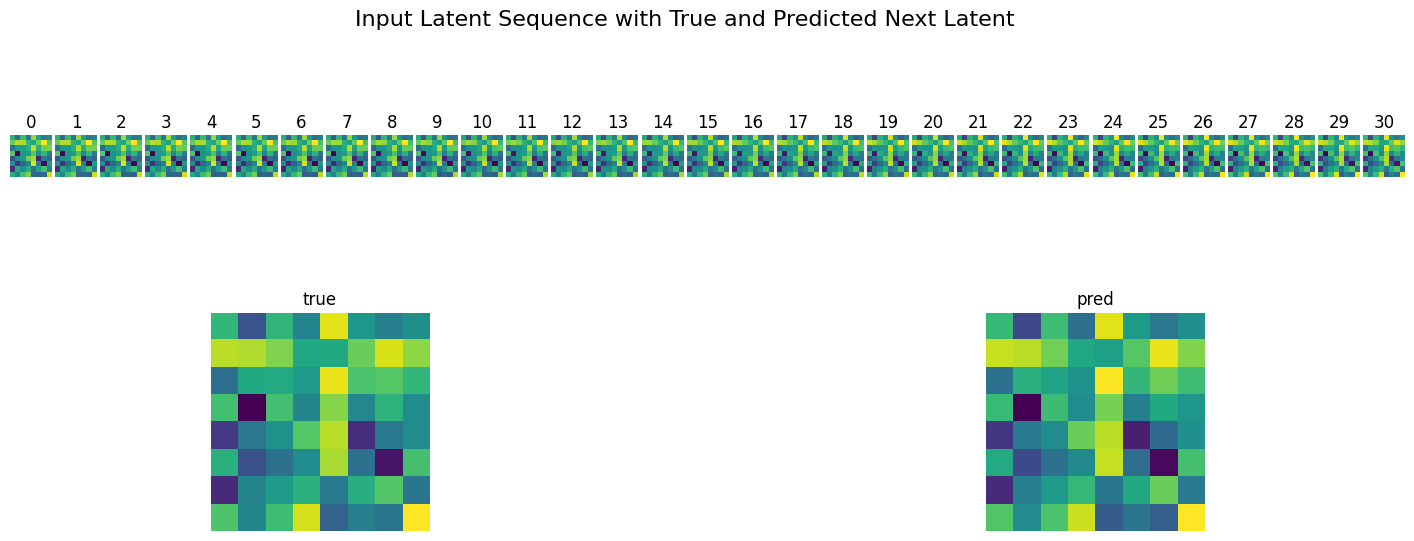

In [116]:
import matplotlib.pyplot as plt
import torch

# Evaluation mode.
ae_model.eval()
lstm_model.eval()

# One batch from test dataloader.
batch = next(iter(seq_test_dataloader))
x = batch["x"].to(DEVICE)
lengths = batch["length"].to(DEVICE)

# Pick one sequence.
i = 0
seq_len = int(lengths[i].item())

with torch.no_grad():
    # Split into input frames and true next frame.
    x_valid = x[i:i+1, :seq_len]
    x_input = x_valid[:, :-1]
    x_true = x_valid[:, -1]

    # Encode input frames into latents.
    z_list = []
    for t in range(x_input.shape[1]):
        _, z_t = ae_model(x_input[:, t])
        z_list.append(z_t)

    z_input = torch.stack(z_list, dim=1)

    # Encode the true next latent and predict the next latent.
    _, z_true = ae_model(x_true)
    h_seq, z_pred = lstm_model(z_input)

# Convert tensors to numpy for plotting.
z_input_np = z_input.squeeze(0).cpu().numpy()
z_true_np = z_true.squeeze(0).cpu().numpy()
z_pred_np = z_pred.squeeze(0).cpu().numpy()

# Plot input latents, true next latent, and predicted next latent.
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Input Latent Sequence with True and Predicted Next Latent", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)

top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

for t in range(seq_len - 1):
    top_axes[t].imshow(z_input_np[t].reshape(8, 8), cmap="viridis")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

ax_true.imshow(z_true_np.reshape(8, 8), cmap="viridis")
ax_true.set_title("true")
ax_true.axis("off")

ax_pred.imshow(z_pred_np.reshape(8, 8), cmap="viridis")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.tight_layout()
plt.savefig(SEQ_RUN_DIR / "next_latent_prediction.png", dpi=150)
plt.show()

### Save

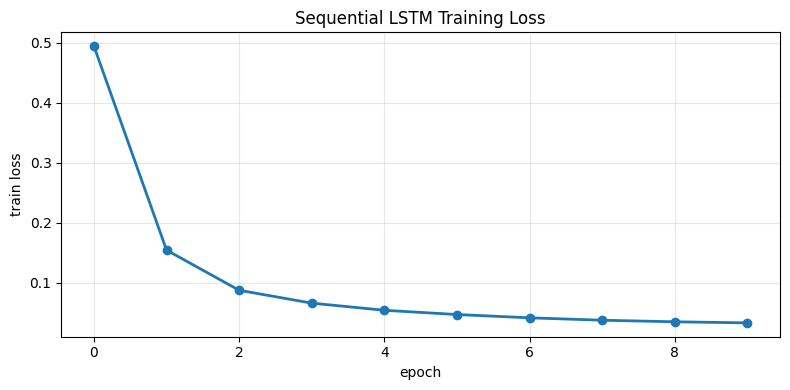

saved model -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_24042026_213451/model.pth
saved losses -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_24042026_213451/losses.pt
saved plot -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_24042026_213451/loss.png
saved meta -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_24042026_213451/meta.pt
saved full model -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_24042026_213451/model_full.pt
saved scripted model -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/seq

In [117]:
import torch
import matplotlib.pyplot as plt

torch.save(lstm_model.state_dict(), SEQ_RUN_DIR / "model.pth")
torch.save(train_losses, SEQ_RUN_DIR / "losses.pt")

meta = {
    "z_dim": Z_DIM,
    "seq_len": SEQ_LEN,
    "predataset_path": str(SEQ_PREDATASET_PT),
    "train_dataset_path": str(SEQ_TRAIN_PT),
    "test_dataset_path": str(SEQ_TEST_PT),
    "num_epochs": LSTM_EPOCHS,
    "learning_rate": LSTM_LR,
    "grad_clip": LSTM_GRAD_CLIP,
}
torch.save(meta, SEQ_RUN_DIR / "meta.pt")
torch.save(lstm_model, SEQ_RUN_DIR / "model_full.pt")

lstm_model.eval()
lstm_model_cpu = lstm_model.to("cpu")

scripted_lstm = torch.jit.script(lstm_model_cpu)
scripted_lstm.save(str(SEQ_RUN_DIR / "lstm_model_scripted.pt"))

lstm_model = lstm_model_cpu.to(DEVICE)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, "o-", lw=2)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("Sequential LSTM Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SEQ_RUN_DIR / "loss.png", dpi=140)
plt.show()

print("saved model ->", SEQ_RUN_DIR / "model.pth")
print("saved losses ->", SEQ_RUN_DIR / "losses.pt")
print("saved plot ->", SEQ_RUN_DIR / "loss.png")
print("saved meta ->", SEQ_RUN_DIR / "meta.pt")
print("saved full model ->", SEQ_RUN_DIR / "model_full.pt")
print("saved scripted model ->", SEQ_RUN_DIR / "lstm_model_scripted.pt")


### Load Seq + quick sanity

[LSTM] loaded scripted model -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_24042026_213451/lstm_model_scripted.pt
[LSTM] using test dataset -> /Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_24042026_213451/seq_test_dataset.pt
[LSTM] selected batch shape -> (32, 32, 1, 84, 84)
[LSTM] selected sequence index -> 13
[LSTM] selected sequence length -> 32
[LSTM] latent MSE -> 0.009056
[LSTM] frame MSE  -> 0.004450


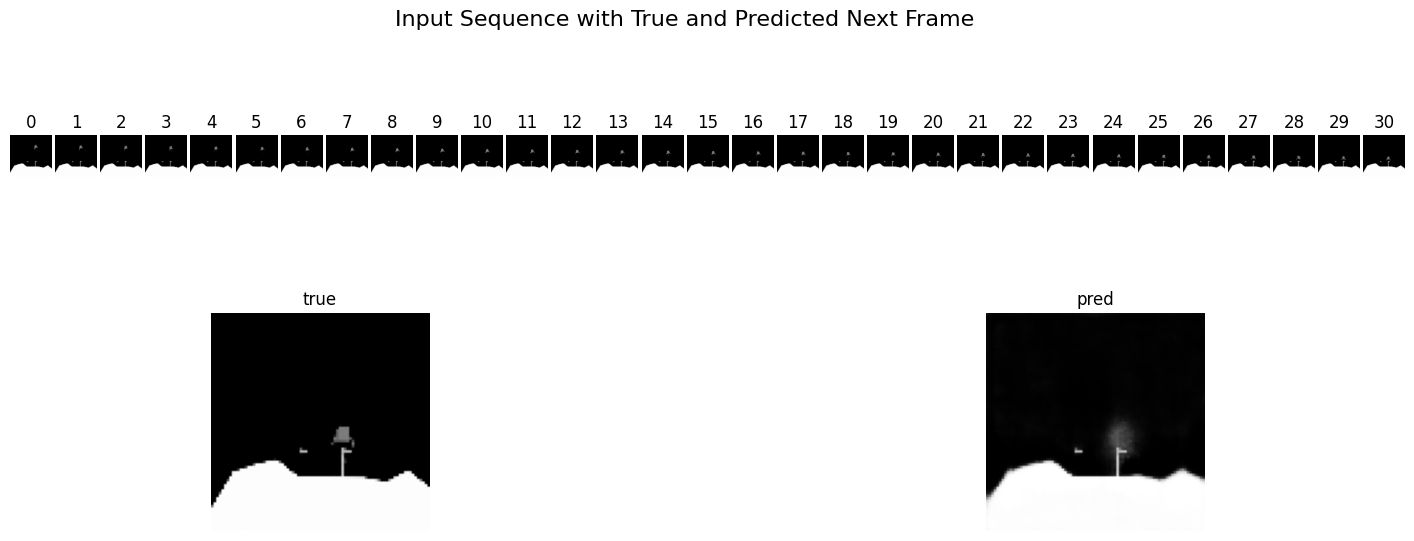

In [118]:
import torch
import matplotlib.pyplot as plt

lstm_model = torch.jit.load(str(SEQ_RUN_DIR / "lstm_model_scripted.pt"), map_location=DEVICE)
lstm_model.eval()

print("[LSTM] loaded scripted model ->", SEQ_RUN_DIR / "lstm_model_scripted.pt")
print("[LSTM] using test dataset ->", SEQ_TEST_PT)

ae_model.eval()

batch = next(iter(seq_test_dataloader))
x = batch["x"].to(DEVICE)
lengths = batch["length"].to(DEVICE)

i = torch.randint(0, x.shape[0], (1,)).item()
seq_len = int(lengths[i].item())

print("[LSTM] selected batch shape ->", tuple(x.shape))
print("[LSTM] selected sequence index ->", i)
print("[LSTM] selected sequence length ->", seq_len)

with torch.no_grad():
    x_valid = x[i:i+1, :seq_len]
    x_input = x_valid[:, :-1]
    x_true = x_valid[:, -1]

    z_list = []
    for t in range(x_input.shape[1]):
        _, z_t = ae_model(x_input[:, t])
        z_list.append(z_t)

    z_input = torch.stack(z_list, dim=1)

    _, z_true = ae_model(x_true)
    h_seq, z_pred = lstm_model(z_input)

    x_pred = ae_model.decoder_fc(z_pred).view(-1, 256, 10, 10)
    x_pred = ae_model.decoder(x_pred)
    x_pred = x_pred[:, :, :84, :84]

    latent_mse = torch.mean((z_pred - z_true) ** 2).item()
    recon_mse = torch.mean((x_pred - x_true) ** 2).item()

print(f"[LSTM] latent MSE -> {latent_mse:.6f}")
print(f"[LSTM] frame MSE  -> {recon_mse:.6f}")

fig = plt.figure(figsize=(18, 6))
fig.suptitle("Input Sequence with True and Predicted Next Frame", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)

top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

for t in range(seq_len - 1):
    top_axes[t].imshow(x_input[0, t, 0].cpu(), cmap="gray")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

ax_true.imshow(x_true[0, 0].cpu(), cmap="gray")
ax_true.set_title("true")
ax_true.axis("off")

ax_pred.imshow(x_pred[0, 0].detach().cpu(), cmap="gray")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.show()


---

---

# Action Inference

Experiments to do:

* Now we use FDM(z_t, a). We tried FDM(h_t, a) but h_t is too strong due to the fact that LSTM (with h_t) is solely able to predict x_t+1, eventually model gets rid of a which eventually becomes constant. z_t works much better, however we could test how long h_t could we use so the prediction is optimized without eating a.

In [90]:
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
import shutil

from PIL import Image
import numpy as np

## Setup

After trained Autoencoder and LSTM change blow STAMP to latest saved in runs/atoencoder and runs/sequential.

In [91]:
STAMP = '27042026_151006'

In [92]:
from pathlib import Path
from datetime import datetime

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

# Resolve the Student root from the current notebook location.
_cwd = Path.cwd().resolve()
STUDENT = None
for p in [_cwd, *_cwd.parents]:
    if (p / "src").is_dir() and (p / "notebooks").is_dir() and (p / "data").is_dir():
        STUDENT = p
        break

if STUDENT is None:
    raise RuntimeError("Could not find Student root")

# Define the main project roots.
STUDENT_ROOT = STUDENT
TEACHER = STUDENT.parent / "Teacher"

# Path to raw extracted teacher frames.
FRAMES_ROOT = STUDENT / "data" / "frames"

# Root directory for all experiment runs.
RUNS_ROOT = STUDENT / "runs"

###################
### Autoencoder ###
###################

# Autoencoder run directory.
AE_DIR = RUNS_ROOT / "autoencoder"

AE_RUN_DIR = AE_DIR / f"autoencoder_{STAMP}"

# Create the autoencoder run folder.
# AE_RUN_DIR.mkdir(parents=True, exist_ok=True)

# Autoencoder dataset files saved inside the run folder.
AE_TRAIN_PT = AE_RUN_DIR / "ae_train_dataset.pt"
AE_TEST_PT = AE_RUN_DIR / "ae_test_dataset.pt"

##################
### Sequential ###
##################

# Sequential run directory.
SEQ_DIR = RUNS_ROOT / "sequential"
SEQ_RUN_DIR = SEQ_DIR / f"sequential_{STAMP}"

# Create the sequential run folder.
# SEQ_RUN_DIR.mkdir(parents=True, exist_ok=True)

# Sequential dataset files saved inside the run folder.
SEQ_TRAIN_PT = SEQ_RUN_DIR / "seq_train_dataset.pt"
SEQ_TEST_PT  = SEQ_RUN_DIR / "seq_test_dataset.pt"

## Autoencoder Upload

### Model

In [93]:
AE_RUN_DIR

PosixPath('/Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_27042026_151006')

In [94]:
import torch

ae_model = torch.jit.load(str(AE_RUN_DIR / "ae_model_scripted.pt"), map_location=DEVICE)
ae_model.eval()

print(AE_RUN_DIR / "ae_model_scripted.pt")


/Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/autoencoder/autoencoder_27042026_151006/ae_model_scripted.pt


### DataLoader

In [95]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset

ae_train_dataset = torch.load(AE_TRAIN_PT, map_location="cpu")
ae_test_dataset  = torch.load(AE_TEST_PT, map_location="cpu")

Z_DIM = 64
BATCH_SIZE = 128
NUM_WORKERS = 0
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

_dl = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)

if NUM_WORKERS > 0:
    _dl["prefetch_factor"] = 2

ae_train_dataloader = DataLoader(ae_train_dataset, shuffle=True, **_dl)
ae_test_dataloader  = DataLoader(ae_test_dataset, shuffle=False, **_dl)

x = next(iter(ae_test_dataloader))
x = x.to(DEVICE)
print(x.shape)


torch.Size([128, 1, 84, 84])


### Smoke Test

In [96]:
x_t, z = ae_model(x)

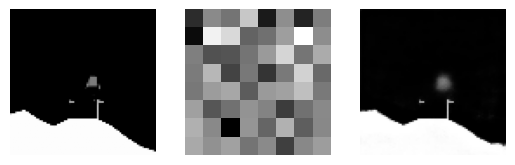

In [97]:
fig, axs = plt.subplots(1, 3)

idx = np.random.choice(x.shape[0])

axs[0].imshow(x[idx].detach().cpu().squeeze(), cmap="gray")
axs[1].imshow(z[idx].detach().cpu().reshape(8, 8).numpy(), cmap="gray")
axs[2].imshow(x_t[idx].detach().cpu().squeeze().numpy(), cmap="gray")

for i in range(3):
    axs[i].axis("off")


In [98]:
ae_model

RecursiveScriptModule(
  original_name=AutoEncoder
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=BatchNorm2d)
    (2): RecursiveScriptModule(original_name=ReLU)
    (3): RecursiveScriptModule(original_name=Conv2d)
    (4): RecursiveScriptModule(original_name=BatchNorm2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=BatchNorm2d)
    (8): RecursiveScriptModule(original_name=ReLU)
    (9): RecursiveScriptModule(original_name=Conv2d)
    (10): RecursiveScriptModule(original_name=BatchNorm2d)
    (11): RecursiveScriptModule(original_name=ReLU)
    (12): RecursiveScriptModule(original_name=Conv2d)
    (13): RecursiveScriptModule(original_name=BatchNorm2d)
    (14): RecursiveScriptModule(original_name=ReLU)
    (15): RecursiveScriptModule(original_name=Flatten)
    (16): Recu

## Sequential Upload

### Model

In [99]:
SEQ_RUN_DIR

PosixPath('/Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_27042026_151006')

In [100]:
import torch

lstm_model = torch.jit.load(str(SEQ_RUN_DIR / "lstm_model_scripted.pt"), map_location=DEVICE)
lstm_model.eval()

print(SEQ_RUN_DIR / "lstm_model_scripted.pt")


/Users/adriankazi/Desktop/Deep-Learning/GroupProject/DDPG-and-TD3-for-LunarLander-Environment/Student/runs/sequential/sequential_27042026_151006/lstm_model_scripted.pt


### DataLoader

In [101]:
import torch

seq_train_data = torch.load(SEQ_TRAIN_PT, map_location="cpu")
seq_test_data = torch.load(SEQ_TEST_PT, map_location="cpu")

print(type(seq_train_data))
print(type(seq_test_data))

if isinstance(seq_train_data, dict):
    for k, v in seq_train_data.items():
        print("train", k, type(v), getattr(v, "shape", None))

if isinstance(seq_test_data, dict):
    for k, v in seq_test_data.items():
        print("test ", k, type(v), getattr(v, "shape", None))


<class 'dict'>
<class 'dict'>
train x <class 'torch.Tensor'> torch.Size([809, 32, 1, 84, 84])
train lengths <class 'torch.Tensor'> torch.Size([809])
train episode_ids <class 'torch.Tensor'> torch.Size([809])
train seq_len <class 'int'> None
test  x <class 'torch.Tensor'> torch.Size([205, 32, 1, 84, 84])
test  lengths <class 'torch.Tensor'> torch.Size([205])
test  episode_ids <class 'torch.Tensor'> torch.Size([205])
test  seq_len <class 'int'> None


In [102]:
import torch
from torch.utils.data import DataLoader, TensorDataset

seq_train_data = torch.load(SEQ_TRAIN_PT, map_location="cpu")
seq_test_data  = torch.load(SEQ_TEST_PT, map_location="cpu")

seq_train_dataset = TensorDataset(
    seq_train_data["x"],
    seq_train_data["lengths"],
    seq_train_data["episode_ids"],
)
seq_test_dataset = TensorDataset(
    seq_test_data["x"],
    seq_test_data["lengths"],
    seq_test_data["episode_ids"],
)

BATCH_SIZE = 128
NUM_WORKERS = 0
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

_dl = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)

if NUM_WORKERS > 0:
    _dl["prefetch_factor"] = 2

seq_train_dataloader = DataLoader(seq_train_dataset, shuffle=True, **_dl)
seq_test_dataloader  = DataLoader(seq_test_dataset, shuffle=False, **_dl)

x, lengths, episode_ids = next(iter(seq_test_dataloader))
print(x.shape)
print(lengths.shape)
print(episode_ids.shape)


torch.Size([128, 32, 1, 84, 84])
torch.Size([128])
torch.Size([128])


### Smoke Test

/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_13939/822734249.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


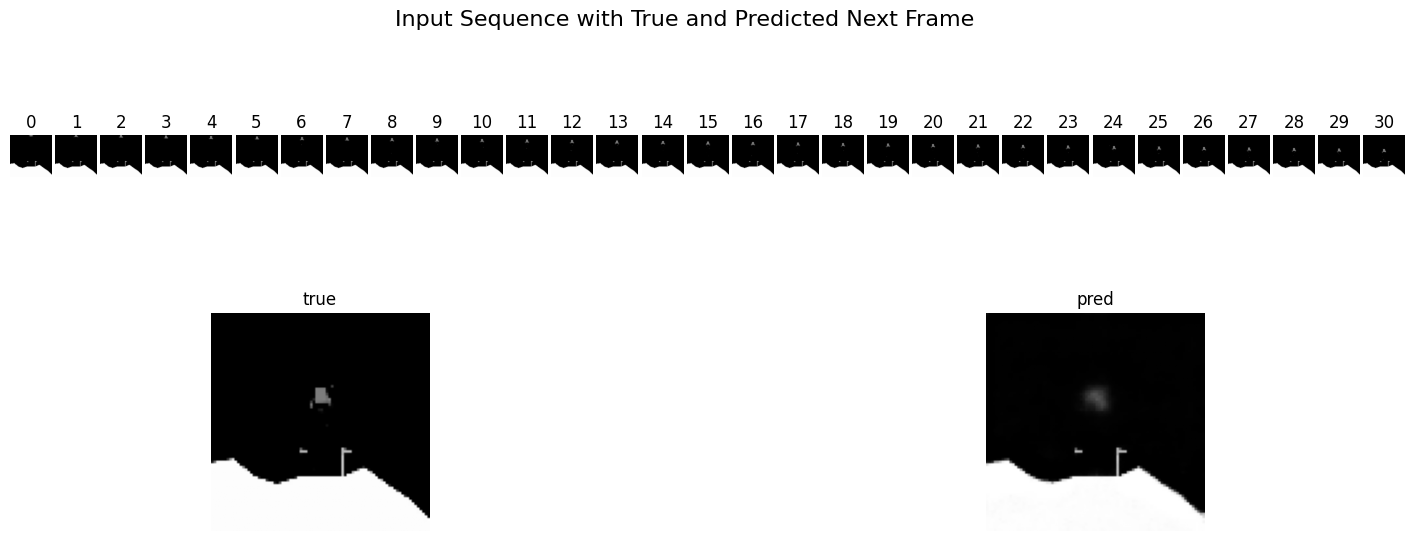

In [103]:
import matplotlib.pyplot as plt
import torch

ae_model.eval()
lstm_model.eval()

# x, lengths, episode_ids already come from the previous cell (TensorDataset batch)
# x: (B,T,1,84,84)  lengths: (B,)  episode_ids: (B,)

b = torch.randint(0, x.shape[0], (1,)).item()
seq_len = int(lengths[b].item())

with torch.no_grad():
    x_valid = x[b:b+1, :seq_len].to(DEVICE)      # (1,L,1,84,84)
    x_input = x_valid[:, :-1]                    # (1,L-1,1,84,84)
    x_true  = x_valid[:, -1]                     # (1,1,84,84)

    # encode input frames -> latents (1,L-1,Z)
    z_list = []
    for t in range(x_input.shape[1]):
        x_recon_t, z_t = ae_model(x_input[:, t])
        z_list.append(z_t)
    z_input = torch.stack(z_list, dim=1)

    # predict next latent
    h_seq, z_pred = lstm_model(z_input)

    # decode predicted latent -> predicted next frame
    if hasattr(ae_model, "decode"):
        x_pred, z_tmp = ae_model.decode(z_pred)
    else:
        x_pred = ae_model.decoder_fc(z_pred).view(-1, 256, 10, 10)
        x_pred = ae_model.decoder(x_pred)
        x_pred = x_pred[:, :, :84, :84]
    x_pred = x_pred.detach().cpu()

# plot
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Input Sequence with True and Predicted Next Frame", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)
top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

for t in range(seq_len - 1):
    top_axes[t].imshow(x_input[0, t, 0].cpu(), cmap="gray")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

ax_true.imshow(x_true[0, 0].cpu(), cmap="gray")
ax_true.set_title("true")
ax_true.axis("off")

ax_pred.imshow(x_pred[0, 0], cmap="gray")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.tight_layout()
plt.show()

/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_13939/2912680457.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


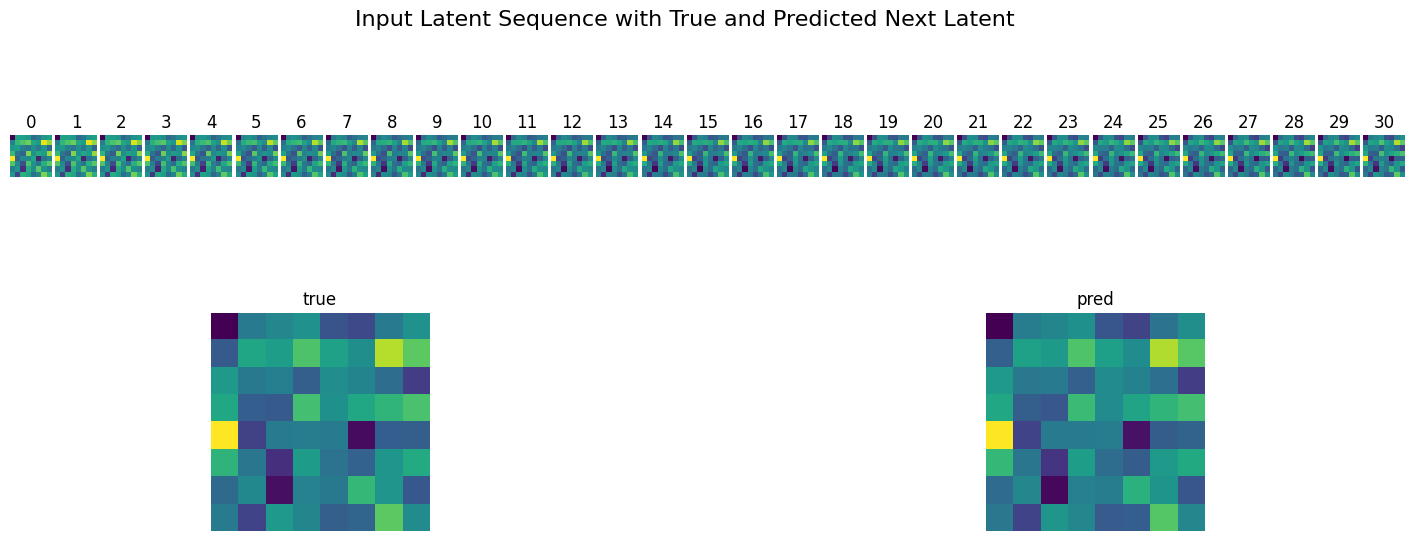

In [104]:
import matplotlib.pyplot as plt
import torch

ae_model.eval()
lstm_model.eval()

# batch (dict or tuple/list)
batch = next(iter(seq_test_dataloader))
if isinstance(batch, dict):
    x = batch["x"].to(DEVICE)
    lengths = batch["length"].to(DEVICE)
else:
    x = batch[0].to(DEVICE)
    lengths = batch[1].to(DEVICE)

# pick one sequence
b = torch.randint(0, x.shape[0], (1,)).item()
seq_len = int(lengths[b].item())

with torch.no_grad():
    x_valid = x[b:b+1, :seq_len]      # (1,L,1,84,84)
    x_input = x_valid[:, :-1]         # (1,L-1,1,84,84)
    x_true  = x_valid[:, -1]          # (1,1,84,84)

    # encode input latents
    z_list = []
    for t in range(x_input.shape[1]):
        x_recon_t, z_t = ae_model(x_input[:, t])
        z_list.append(z_t)
    z_input = torch.stack(z_list, dim=1)   # (1,L-1,Z)

    # true next latent
    x_true_recon, z_true = ae_model(x_true)  # (1,Z)

    # predicted next latent
    h_seq, z_pred = lstm_model(z_input)      # (1,Z)

z_input_np = z_input[0].cpu().numpy()  # (L-1,Z)
z_true_np = z_true[0].cpu().numpy()    # (Z,)
z_pred_np = z_pred[0].cpu().numpy()    # (Z,)

# plot
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Input Latent Sequence with True and Predicted Next Latent", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)

top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

for t in range(seq_len - 1):
    top_axes[t].imshow(z_input_np[t].reshape(8, 8), cmap="viridis")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

ax_true.imshow(z_true_np.reshape(8, 8), cmap="viridis")
ax_true.set_title("true")
ax_true.axis("off")

ax_pred.imshow(z_pred_np.reshape(8, 8), cmap="viridis")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.tight_layout()
plt.savefig(SEQ_RUN_DIR / "next_latent_prediction.png", dpi=150)
plt.show()

In [105]:
lstm_model

RecursiveScriptModule(
  original_name=LatentLSTM
  (lstm): RecursiveScriptModule(original_name=LSTM)
  (head): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=LayerNorm)
    (1): RecursiveScriptModule(original_name=Linear)
    (2): RecursiveScriptModule(original_name=GELU)
    (3): RecursiveScriptModule(original_name=Dropout)
    (4): RecursiveScriptModule(original_name=Linear)
  )
)

## Video Learner

### Math

**Train**

$$ a_t^{real} = sample(\mathcal{A}) $$

$$ o_{t+1} = Env(o_t, a_t^{real}) $$

$$ z_t = AE(o_t) $$

$$ z_{t+1}^{true} = AE(o_{t+1}) $$

$$ h_t, \bar{z}_{t+1} = LSTM(z_1, z_2, ..., z_t) $$

$$ M_t = Overlay(o_1, o_2, ..., o_t) $$

$$ m_t = AE(M_t) $$

$$ c_t = concat(z_t, h_t, m_t) $$

$$ \tilde{a}_t = IDM(c_t) $$

$$ a_t = Adapter(\tilde{a}_t, \bar{z}_{t+1}) $$

$$ \Delta \hat{z}_{t+1} = FDM(c_t, \tilde{a}_t) $$

$$ \hat{z}_{t+1} = z_t + \Delta \hat{z}_{t+1} $$

$$ L_z = || \hat{z}_{t+1} - z_{t+1}^{true} ||^2 $$

$$ L_a = || a_t - a_t^{real} ||^2 $$

$$ L = L_z + \lambda L_a $$

**Eval / Runtime**

$$ o_t = Env.render() $$

$$ z_t = AE(o_t) $$

$$ h_t, \bar{z}_{t+1} = LSTM(z_1, z_2, ..., z_t) $$

$$ M_t = Overlay(o_1, o_2, ..., o_t) $$

$$ m_t = AE(M_t) $$

$$ c_t = concat(z_t, h_t, m_t) $$

$$ \tilde{a}_t = IDM(c_t) $$

$$ a_t = Adapter(\tilde{a}_t, \bar{z}_{t+1}) $$

$$ o_{t+1} = Env(o_t, a_t) $$

**Optional Debug After Step**

$$ z_{t+1}^{observed} = AE(o_{t+1}) $$

$$ \Delta z_{t+1}^{observed} = z_{t+1}^{observed} - z_t $$

$$ \Delta \hat{z}_{t+1} = FDM(c_t, \tilde{a}_t) $$

$$ L_{debug} = || \Delta \hat{z}_{t+1} - \Delta z_{t+1}^{observed} ||^2 $$


### Models

In [106]:
import torch
import torch.nn as nn


def overlay_frames(x_seq, decay=0.9):
    # x_seq: (B,T,1,84,84)
    T = x_seq.shape[1]
    weights = torch.tensor(
        [decay ** (T - 1 - i) for i in range(T)],
        device=x_seq.device,
        dtype=x_seq.dtype,
    )
    weights = weights / weights.sum()
    return (x_seq * weights.view(1, T, 1, 1, 1)).sum(dim=1)  # (B,1,84,84)


class IDMModel(nn.Module):
    def __init__(self, c_dim, latent_a_dim=8):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(c_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),

            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),

            nn.Linear(128, latent_a_dim),
            nn.Tanh(),
        )

    def forward(self, c_t):
        return self.net(c_t)


class ActionAdapter(nn.Module):
    def __init__(self, latent_a_dim=8, real_a_dim=2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_a_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),

            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.GELU(),

            nn.Linear(128, real_a_dim),
            nn.Tanh(),
        )

    def forward(self, latent_a):
        return self.net(latent_a)


class FDMModel(nn.Module):
    def __init__(self, c_dim, z_dim=64, latent_a_dim=8):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(c_dim + latent_a_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),

            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),

            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),

            nn.Linear(128, z_dim),
        )

    def forward(self, c_t, latent_a):
        x = torch.cat([c_t, latent_a], dim=-1)
        return self.net(x)


### Test Spin

In [107]:
# Test Spin

import torch

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

ae_model = ae_model.to(DEVICE).eval()
lstm_model = lstm_model.to(DEVICE).eval()

batch = next(iter(seq_train_dataloader))

if isinstance(batch, dict):
    x = batch["x"]
else:
    x = batch[0]

x = x.to(DEVICE)
x_hist = x[:, :-1]
x_next = x[:, -1]

with torch.no_grad():
    x_overlay = overlay_frames(x_hist, decay=0.9)
    _, m_t = ae_model(x_overlay)

    z_hist = torch.stack(
        [ae_model(x_hist[:, t])[1] for t in range(x_hist.shape[1])],
        dim=1,
    )

    z_t = z_hist[:, -1, :]
    _, z_true_next = ae_model(x_next)

    h_seq, _ = lstm_model(z_hist)
    h_t = h_seq[:, -1, :]

    c_t = torch.cat([z_t, h_t, m_t], dim=-1)

Z_DIM = z_true_next.shape[-1]
C_DIM = c_t.shape[-1]
LATENT_A_DIM = 8
REAL_A_DIM = 2

idm_model = IDMModel(c_dim=C_DIM, latent_a_dim=LATENT_A_DIM).to(DEVICE)
adapter_model = ActionAdapter(
    latent_a_dim=LATENT_A_DIM,
    real_a_dim=REAL_A_DIM,
).to(DEVICE)
fdm_model = FDMModel(
    c_dim=C_DIM,
    z_dim=Z_DIM,
    latent_a_dim=LATENT_A_DIM,
).to(DEVICE)

optimizer = torch.optim.Adam(
    list(idm_model.parameters())
    + list(adapter_model.parameters())
    + list(fdm_model.parameters()),
    lr=1e-3,
)

latent_a = idm_model(c_t)
a_pred = adapter_model(latent_a)
delta_z_pred = fdm_model(c_t, latent_a)
z_pred_next = z_t + delta_z_pred

loss_z = ((z_pred_next - z_true_next) ** 2).mean()

print("x:", x.shape)
print("x_overlay:", x_overlay.shape)
print("z_hist:", z_hist.shape)
print("z_t:", z_t.shape)
print("h_t:", h_t.shape)
print("m_t:", m_t.shape)
print("c_t:", c_t.shape)
print("z_true_next:", z_true_next.shape)
print("latent_a:", latent_a.shape)
print("a_pred:", a_pred.shape)
print("delta_z_pred:", delta_z_pred.shape)
print("z_pred_next:", z_pred_next.shape)
print("loss_z:", float(loss_z.item()))

x: torch.Size([128, 32, 1, 84, 84])
x_overlay: torch.Size([128, 1, 84, 84])
z_hist: torch.Size([128, 31, 64])
z_t: torch.Size([128, 64])
h_t: torch.Size([128, 256])
m_t: torch.Size([128, 64])
c_t: torch.Size([128, 384])
z_true_next: torch.Size([128, 64])
latent_a: torch.Size([128, 8])
a_pred: torch.Size([128, 2])
delta_z_pred: torch.Size([128, 64])
z_pred_next: torch.Size([128, 64])
loss_z: 0.15764272212982178


### Train

In [108]:
import torch
import torch.nn.functional as F

EPOCHS = 30
LR = 3e-4
OVERLAY_DECAY = 0.9
LOG_EVERY = 1

ae_model.eval()
lstm_model.eval()
idm_model.train()
fdm_model.train()

for p in ae_model.parameters():
    p.requires_grad = False

for p in lstm_model.parameters():
    p.requires_grad = False

opt = torch.optim.Adam(
    list(idm_model.parameters()) + list(fdm_model.parameters()),
    lr=LR,
)

losses = {
    "epoch": [],
    "total": [],
    "z": [],
    "delta": [],
    "delta_cos": [],
    "lstm_baseline": [],
    "latent_a_mag": [],
    "latent_a_std": [],
}

for epoch in range(1, EPOCHS + 1):
    idm_model.train()
    fdm_model.train()

    sums = {
        "total": 0.0,
        "z": 0.0,
        "delta": 0.0,
        "delta_cos": 0.0,
        "lstm_baseline": 0.0,
        "latent_a_mag": 0.0,
        "latent_a_std": 0.0,
    }
    n = 0

    for batch in seq_train_dataloader:
        x = (batch["x"] if isinstance(batch, dict) else batch[0]).to(DEVICE)

        x_input = x[:, :-1]
        x_target = x[:, -1]

        with torch.no_grad():
            x_overlay = overlay_frames(x_input, decay=OVERLAY_DECAY)
            _, m_t = ae_model(x_overlay)

            z_input = torch.stack(
                [ae_model(x_input[:, t])[1] for t in range(x_input.shape[1])],
                dim=1,
            )

            z_t = z_input[:, -1, :]
            _, z_true_next = ae_model(x_target)

            h_seq, z_lstm_next = lstm_model(z_input)
            h_t = h_seq[:, -1, :]

            c_t = torch.cat([z_t, h_t, m_t], dim=-1)
            delta_z_true = z_true_next - z_t
            loss_lstm = F.mse_loss(z_lstm_next, z_true_next)

        latent_a = idm_model(c_t)

        delta_z_pred = fdm_model(c_t, latent_a)
        z_pred_next = z_t + delta_z_pred

        loss_z = F.mse_loss(z_pred_next, z_true_next)
        loss_delta = F.mse_loss(delta_z_pred, delta_z_true)
        cos_delta = F.cosine_similarity(delta_z_pred, delta_z_true, dim=-1).mean()

        loss = loss_z

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        bs = x.shape[0]
        sums["total"] += float(loss.item()) * bs
        sums["z"] += float(loss_z.item()) * bs
        sums["delta"] += float(loss_delta.item()) * bs
        sums["delta_cos"] += float(cos_delta.item()) * bs
        sums["lstm_baseline"] += float(loss_lstm.item()) * bs
        sums["latent_a_mag"] += float((latent_a ** 2).mean().item()) * bs
        sums["latent_a_std"] += float(latent_a.std(dim=0, unbiased=False).mean().item()) * bs

        n += bs

    means = {k: v / max(n, 1) for k, v in sums.items()}

    losses["epoch"].append(epoch)
    for k, v in means.items():
        losses[k].append(v)

    if epoch % LOG_EVERY == 0:
        print(
            f"[video-learner] epoch {epoch:03d}/{EPOCHS} | "
            f"loss {means['total']:.6f} | "
            f"z {means['z']:.6f} | "
            f"delta {means['delta']:.6f} | "
            f"cos {means['delta_cos']:.4f} | "
            f"lstm {means['lstm_baseline']:.6f} | "
            f"latent std {means['latent_a_std']:.4f}"
        )


[video-learner] epoch 001/30 | loss 0.059606 | z 0.059606 | delta 0.059606 | cos 0.0106 | lstm 0.006653 | latent std 0.2138
[video-learner] epoch 002/30 | loss 0.006919 | z 0.006919 | delta 0.006919 | cos 0.0894 | lstm 0.006653 | latent std 0.1846
[video-learner] epoch 003/30 | loss 0.002879 | z 0.002879 | delta 0.002879 | cos 0.1322 | lstm 0.006653 | latent std 0.1719
[video-learner] epoch 004/30 | loss 0.002130 | z 0.002130 | delta 0.002130 | cos 0.1307 | lstm 0.006653 | latent std 0.1604
[video-learner] epoch 005/30 | loss 0.001367 | z 0.001367 | delta 0.001367 | cos 0.1750 | lstm 0.006653 | latent std 0.1554
[video-learner] epoch 006/30 | loss 0.001186 | z 0.001186 | delta 0.001186 | cos 0.2193 | lstm 0.006653 | latent std 0.1487
[video-learner] epoch 007/30 | loss 0.001080 | z 0.001080 | delta 0.001080 | cos 0.2705 | lstm 0.006653 | latent std 0.1430
[video-learner] epoch 008/30 | loss 0.001008 | z 0.001008 | delta 0.001008 | cos 0.3166 | lstm 0.006653 | latent std 0.1399
[video-l

### Eval

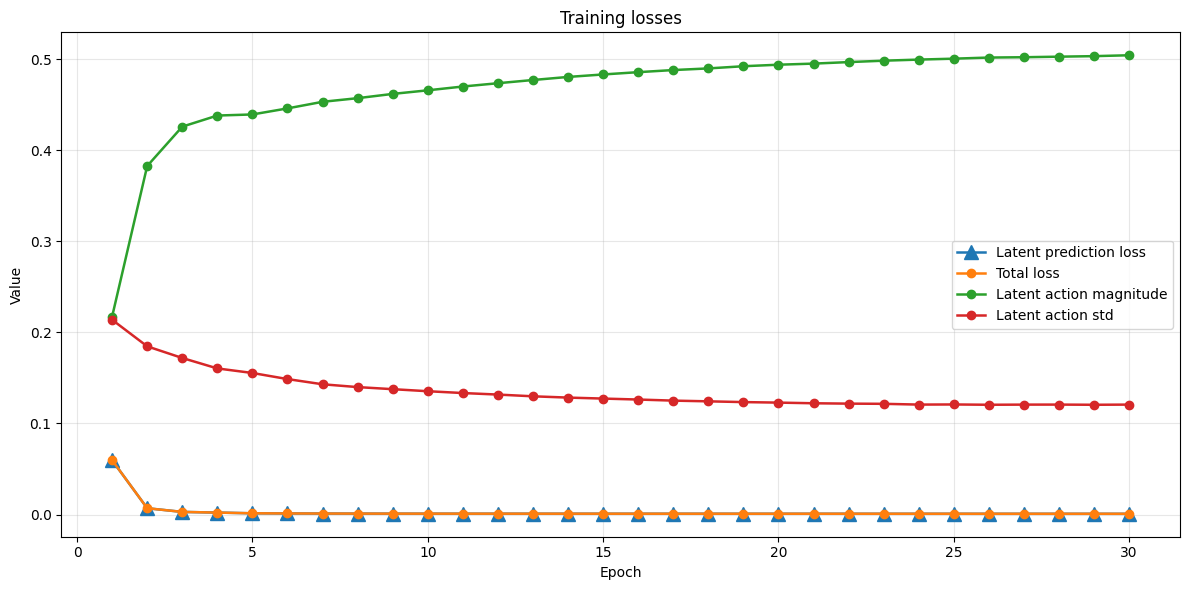

In [148]:
# import matplotlib.pyplot as plt

# xs = losses["epoch"]

# fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# axs[0, 0].plot(xs, losses["total"], marker="o", lw=1.5)
# axs[0, 0].set_title("total loss")
# axs[0, 0].set_xlabel("epoch")
# axs[0, 0].grid(True, alpha=0.3)

# axs[0, 1].plot(xs, losses["z"], marker="o", lw=1.5)
# axs[0, 1].set_title("latent prediction loss")
# axs[0, 1].set_xlabel("epoch")
# axs[0, 1].grid(True, alpha=0.3)

# axs[1, 0].plot(xs, losses["latent_a_mag"], marker="o", lw=1.5)
# axs[1, 0].set_title("latent action magnitude")
# axs[1, 0].set_xlabel("epoch")
# axs[1, 0].grid(True, alpha=0.3)

# axs[1, 1].plot(xs, losses["latent_a_std"], marker="o", lw=1.5)
# axs[1, 1].set_title("latent action std")
# axs[1, 1].set_xlabel("epoch")
# axs[1, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()


import matplotlib.pyplot as plt

xs = losses["epoch"]

plt.figure(figsize=(12, 6))

plt.plot(xs, losses["z"], marker="^", markersize = 10 ,lw=1.8, label="Latent prediction loss")
plt.plot(xs, losses["total"], marker="o", lw=1.8, label="Total loss")
plt.plot(xs, losses["latent_a_mag"], marker="o", lw=1.8, label="Latent action magnitude")
plt.plot(xs, losses["latent_a_std"], marker="o", lw=1.8, label="Latent action std")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training losses")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


seq_len: 32
video learner loss: 0.0004168523591943085
lstm baseline loss: 0.005169586278498173
delta loss: 0.00041685233009047806
delta cosine: 0.8042198419570923


/var/folders/1f/f_d5fqlx74x2y8bzm9xsylgc0000gn/T/ipykernel_13939/4137122244.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


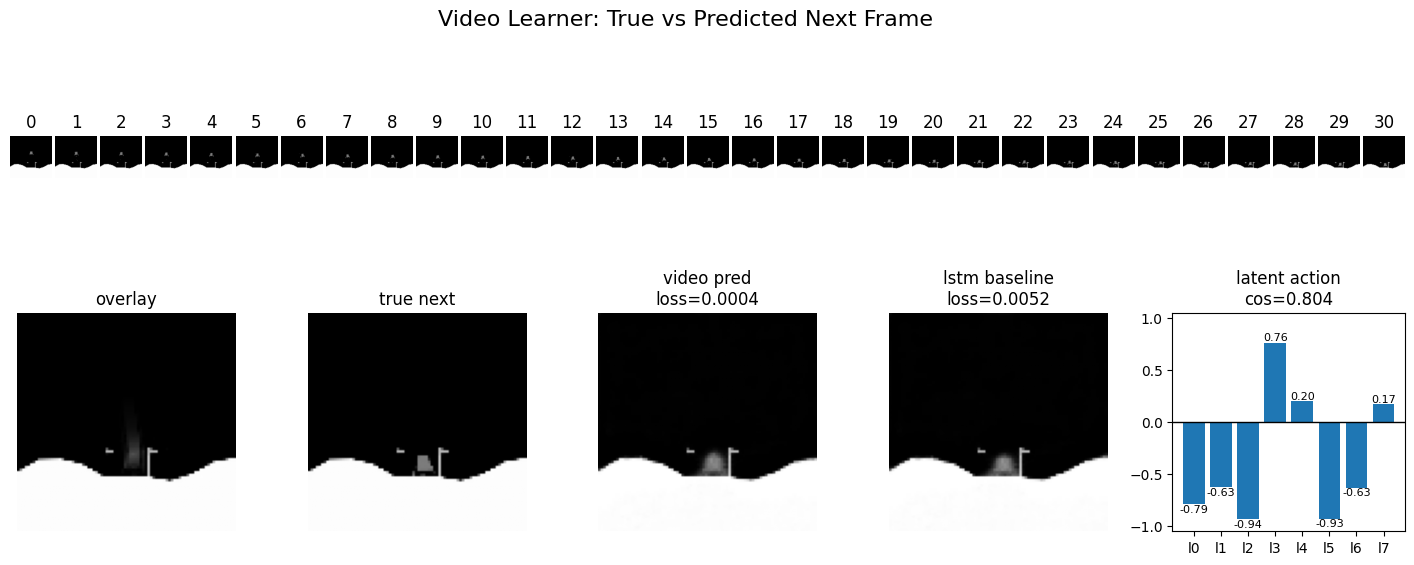

In [110]:
# Full Sequence Visual Check - Video Learner Only

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

OVERLAY_DECAY = 0.9

ae_model.eval()
lstm_model.eval()
idm_model.eval()
fdm_model.eval()

batch = next(iter(seq_test_dataloader))

if isinstance(batch, dict):
    x = batch["x"].to(DEVICE)
    lengths = batch["length"].to(DEVICE)
else:
    x = batch[0].to(DEVICE)
    lengths = batch[1].to(DEVICE)

b = torch.randint(0, x.shape[0], (1,)).item()
seq_len = int(lengths[b].item())

with torch.no_grad():
    x_valid = x[b:b + 1, :seq_len]
    x_input = x_valid[:, :-1]
    x_true_next = x_valid[:, -1]

    x_overlay = overlay_frames(x_input, decay=OVERLAY_DECAY)
    _, m_t = ae_model(x_overlay)

    z_hist = torch.stack(
        [ae_model(x_input[:, t])[1] for t in range(x_input.shape[1])],
        dim=1,
    )

    z_t = z_hist[:, -1, :]
    _, z_true_next = ae_model(x_true_next)

    h_seq, z_lstm_next = lstm_model(z_hist)
    h_t = h_seq[:, -1, :]

    c_t = torch.cat([z_t, h_t, m_t], dim=-1)

    latent_a = idm_model(c_t)

    delta_z_pred = fdm_model(c_t, latent_a)
    z_pred_next = z_t + delta_z_pred

    delta_z_true = z_true_next - z_t

    loss_video = F.mse_loss(z_pred_next, z_true_next).item()
    loss_lstm = F.mse_loss(z_lstm_next, z_true_next).item()
    loss_delta = F.mse_loss(delta_z_pred, delta_z_true).item()
    cos_delta = F.cosine_similarity(delta_z_pred, delta_z_true, dim=-1).item()

    x_pred_next = ae_model.decoder(
        ae_model.decoder_fc(z_pred_next).view(-1, 256, 10, 10)
    )
    x_pred_next = x_pred_next[:, :, :84, :84].clamp(0, 1)

    x_lstm_next = ae_model.decoder(
        ae_model.decoder_fc(z_lstm_next).view(-1, 256, 10, 10)
    )
    x_lstm_next = x_lstm_next[:, :, :84, :84].clamp(0, 1)

print("seq_len:", seq_len)
print("video learner loss:", loss_video)
print("lstm baseline loss:", loss_lstm)
print("delta loss:", loss_delta)
print("delta cosine:", cos_delta)

fig = plt.figure(figsize=(18, 6))
fig.suptitle("Video Learner: True vs Predicted Next Frame", fontsize=16)

gs = fig.add_gridspec(
    2,
    seq_len - 1,
    height_ratios=[1.0, 1.25],
    hspace=0.35,
    wspace=0.08,
)

top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 5, wspace=0.25)

ax_overlay = fig.add_subplot(bottom_gs[0, 0])
ax_true = fig.add_subplot(bottom_gs[0, 1])
ax_pred = fig.add_subplot(bottom_gs[0, 2])
ax_lstm = fig.add_subplot(bottom_gs[0, 3])
ax_latent = fig.add_subplot(bottom_gs[0, 4])

for t in range(seq_len - 1):
    top_axes[t].imshow(
        x_input[0, t, 0].detach().cpu(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    top_axes[t].set_title(str(t))
    top_axes[t].axis("off")

ax_overlay.imshow(x_overlay[0, 0].detach().cpu(), cmap="gray", vmin=0, vmax=1)
ax_overlay.set_title("overlay")
ax_overlay.axis("off")

ax_true.imshow(x_true_next[0, 0].detach().cpu(), cmap="gray", vmin=0, vmax=1)
ax_true.set_title("true next")
ax_true.axis("off")

ax_pred.imshow(x_pred_next[0, 0].detach().cpu(), cmap="gray", vmin=0, vmax=1)
ax_pred.set_title(f"video pred\nloss={loss_video:.4f}")
ax_pred.axis("off")

ax_lstm.imshow(x_lstm_next[0, 0].detach().cpu(), cmap="gray", vmin=0, vmax=1)
ax_lstm.set_title(f"lstm baseline\nloss={loss_lstm:.4f}")
ax_lstm.axis("off")

latent_a_np = latent_a[0].detach().cpu().numpy()
ax_latent.bar([f"l{i}" for i in range(len(latent_a_np))], latent_a_np)
ax_latent.set_title(f"latent action\ncos={cos_delta:.3f}")
ax_latent.axhline(0, color="black", lw=1)
ax_latent.set_ylim(-1.05, 1.05)

for bar, v in zip(ax_latent.patches, latent_a_np):
    ax_latent.text(
        bar.get_x() + bar.get_width() / 2,
        v,
        f"{v:.2f}",
        ha="center",
        va="bottom" if v >= 0 else "top",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


In [111]:
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib import animation
from PIL import Image


def preprocess_rgb(frame):
    img = Image.fromarray(frame).convert("L").resize((84, 84))
    x = np.array(img, dtype=np.float32) / 255.0
    return torch.from_numpy(x)[None, None]  # (1,1,84,84)


def show_video(frames, interval=40):
    fig = plt.figure(figsize=(5, 5))
    im = plt.imshow(frames[0])
    plt.axis("off")

    def update(i):
        im.set_data(frames[i])
        return [im]

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=interval)
    plt.close(fig)
    display(HTML(anim.to_jshtml()))


def rollout_lander_adapter_only(
    ae_model,
    lstm_model,
    idm_model,
    adapter_model,
    max_steps=500,
    history_len=None,
    overlay_decay=None,
    device=None,
    return_debug=False,
):
    if device is None:
        device = DEVICE

    if history_len is None:
        history_len = SEQ_LEN - 1 if "SEQ_LEN" in globals() else 31

    if overlay_decay is None:
        overlay_decay = OVERLAY_DECAY if "OVERLAY_DECAY" in globals() else 0.9

    env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
    obs, info = env.reset()

    ae_model = ae_model.to(device).eval()
    lstm_model = lstm_model.to(device).eval()
    idm_model = idm_model.to(device).eval()
    adapter_model = adapter_model.to(device).eval()

    x_hist = []
    frames = []
    actions = []
    latent_actions = []
    overlays = []
    total_reward = 0.0

    for step in range(max_steps):
        rgb = env.render()
        frames.append(rgb)

        x = preprocess_rgb(rgb).to(device)
        x_hist.append(x.squeeze(0))

        if len(x_hist) > history_len:
            x_hist = x_hist[-history_len:]

        with torch.no_grad():
            hist = x_hist

            if len(hist) < history_len:
                pad = [hist[0]] * (history_len - len(hist))
                hist = pad + hist

            x_seq = torch.stack(hist, dim=0)[None]  # (1,T,1,84,84)

            x_overlay = overlay_frames(x_seq, decay=overlay_decay)
            _, m_t = ae_model(x_overlay)

            z_hist = torch.stack(
                [ae_model(x_seq[:, t])[1] for t in range(x_seq.shape[1])],
                dim=1,
            )

            z_t = z_hist[:, -1, :]

            h_seq, z_lstm_next = lstm_model(z_hist)
            h_t = h_seq[:, -1, :]

            c_t = torch.cat([z_t, h_t, m_t], dim=-1)

            latent_a = idm_model(c_t)

            # z_lstm_next is used wherever z_{t+1} would be unavailable at runtime.
            try:
                a = adapter_model(latent_a, z_lstm_next)
            except TypeError:
                a = adapter_model(latent_a)

            a = a[0].detach().cpu().numpy()
            a = np.clip(a, -1.0, 1.0).astype(np.float32)

        actions.append(a.copy())
        latent_actions.append(latent_a[0].detach().cpu().numpy().copy())

        if return_debug:
            overlays.append(x_overlay[0, 0].detach().cpu().numpy())

        obs, reward, terminated, truncated, info = env.step(a)
        total_reward += float(reward)

        if terminated or truncated:
            break

    env.close()

    actions = np.array(actions)
    latent_actions = np.array(latent_actions)

    print("steps:", len(frames), "total_reward:", total_reward)
    print("action mean:", actions.mean(axis=0), "std:", actions.std(axis=0))
    print("action min :", actions.min(axis=0), "max:", actions.max(axis=0))
    print("latent mean:", latent_actions.mean(axis=0))
    print("latent std :", latent_actions.std(axis=0))

    show_video(frames)

    if return_debug:
        return frames, total_reward, actions, latent_actions, overlays

    return frames, total_reward, actions, latent_actions


In [112]:
frames, total_reward, actions, latent_actions = rollout_lander_adapter_only(
    ae_model=ae_model,
    lstm_model=lstm_model,
    idm_model=idm_model,
    adapter_model=adapter_model,
    max_steps=500,
)


steps: 86 total_reward: -211.69439985889827
action mean: [-0.34779713 -0.45803836] std: [0.01365429 0.00568641]
action min : [-0.37278214 -0.46792075] max: [-0.3240719 -0.4483482]
latent mean: [-0.76829076 -0.371344   -0.8776968   0.6951813  -0.10715208 -0.9309957
 -0.76654285  0.8292688 ]
latent std : [0.00307402 0.01603348 0.00613539 0.00824374 0.01683601 0.00222896
 0.00681851 0.00240579]


In [113]:
import imageio.v2 as imageio
from pathlib import Path
from datetime import datetime

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = Path(f"rollout_lander_{stamp}.mp4")

imageio.mimsave(out_path, frames, fps=25)

out_path


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


PosixPath('rollout_lander_20260505_171652.mp4')

## Machine Forward

### Math

**Machine Adapter / Forward Model**

$$ a_t^{real} = sample_{probe}(\mathcal{A}) $$

$$ o_{t+1} = Env(o_t, a_t^{real}) $$

$$ z_i = AE(o_i) $$

$$ H_t = (z_{t-k+1}, z_{t-k+2}, ..., z_t) $$

$$ z_{t+1} = AE(o_{t+1}) $$

$$ \Delta z_{t+1} = z_{t+1} - z_t $$

$$ \Delta \hat{z}_{t+1}^{machine} = MachineForward(H_t, a_t^{real}) $$

$$ \hat{z}_{t+1}^{machine} = z_t + \Delta \hat{z}_{t+1}^{machine} $$

$$ L_{machine} = || \hat{z}_{t+1}^{machine} - z_{t+1} ||^2 $$


### Model

In [114]:
# Machine Adapter / Models

import torch
import torch.nn as nn


class MachineForwardModel(nn.Module):
    def __init__(self, z_dim=64, real_a_dim=2, hidden_dim=256, num_layers=1):
        super().__init__()

        self.history_encoder = nn.LSTM(
            input_size=z_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim + real_a_dim),

            nn.Linear(hidden_dim + real_a_dim, hidden_dim),
            nn.GELU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),

            nn.Linear(hidden_dim, z_dim),
        )

    def forward(self, z_hist, a_real):
        # z_hist: (B,K,Z)
        # a_real: (B,A)
        _, (h_n, _) = self.history_encoder(z_hist)
        h_t = h_n[-1]

        x = torch.cat([h_t, a_real], dim=-1)
        return self.head(x)


machine_forward_model = MachineForwardModel(
    z_dim=Z_DIM,
    real_a_dim=REAL_A_DIM,
).to(DEVICE)

print(machine_forward_model)


MachineForwardModel(
  (history_encoder): LSTM(64, 256, batch_first=True)
  (head): Sequential(
    (0): LayerNorm((258,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=258, out_features=256, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=256, out_features=64, bias=True)
  )
)


### Probing Dataset

In [115]:
# Machine Adapter / Probing Dataset

import numpy as np
import torch
import gymnasium as gym
from PIL import Image


def preprocess_rgb(frame):
    img = Image.fromarray(frame).convert("L").resize((84, 84))
    x = np.array(img, dtype=np.float32) / 255.0
    return torch.from_numpy(x)[None, None]  # (1,1,84,84)


def sample_random_action(real_a_dim=2):
    return np.random.uniform(-1.0, 1.0, size=(real_a_dim,)).astype(np.float32)


def build_machine_probe_dataset(
    ae_model,
    n_episodes=20,
    max_steps=300,
    hist_len=8,
    device=DEVICE,
):
    env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")

    ae_model = ae_model.to(device).eval()

    z_hist_list = []
    a_list = []
    dz_list = []

    for ep in range(n_episodes):
        obs, info = env.reset()

        z_buffer = []

        rgb = env.render()
        x = preprocess_rgb(rgb).to(device)

        with torch.no_grad():
            _, z = ae_model(x)

        z_buffer.append(z.squeeze(0).cpu())

        for step in range(max_steps):
            a_real_np = sample_random_action(REAL_A_DIM)

            obs, reward, terminated, truncated, info = env.step(a_real_np)

            rgb_next = env.render()
            x_next = preprocess_rgb(rgb_next).to(device)

            with torch.no_grad():
                _, z_next = ae_model(x_next)

            z_t = z_buffer[-1].to(z_next.device)
            dz = z_next.squeeze(0) - z_t

            hist = z_buffer

            if len(hist) < hist_len:
                pad = [hist[0]] * (hist_len - len(hist))
                hist = pad + hist
            else:
                hist = hist[-hist_len:]

            z_hist_list.append(torch.stack(hist, dim=0).cpu())  # (K,Z)
            a_list.append(torch.from_numpy(a_real_np))
            dz_list.append(dz.cpu())

            z_buffer.append(z_next.squeeze(0).cpu())

            if len(z_buffer) > hist_len:
                z_buffer = z_buffer[-hist_len:]

            if terminated or truncated:
                break

        print(f"[probe] episode {ep + 1:03d}/{n_episodes} | samples so far: {len(z_hist_list)}")

    env.close()

    probe_data = {
        "z_hist": torch.stack(z_hist_list),  # (N,K,Z)
        "a_real": torch.stack(a_list),       # (N,A)
        "dz": torch.stack(dz_list),          # (N,Z)
    }

    print("z_hist:", probe_data["z_hist"].shape)
    print("a_real:", probe_data["a_real"].shape)
    print("dz:", probe_data["dz"].shape)

    return probe_data


machine_probe_data = build_machine_probe_dataset(
    ae_model=ae_model,
    n_episodes=100,
    max_steps=300,
    hist_len=8,
)


[probe] episode 001/100 | samples so far: 128
[probe] episode 002/100 | samples so far: 215
[probe] episode 003/100 | samples so far: 345
[probe] episode 004/100 | samples so far: 471
[probe] episode 005/100 | samples so far: 571
[probe] episode 006/100 | samples so far: 669
[probe] episode 007/100 | samples so far: 746
[probe] episode 008/100 | samples so far: 871
[probe] episode 009/100 | samples so far: 997
[probe] episode 010/100 | samples so far: 1080
[probe] episode 011/100 | samples so far: 1237
[probe] episode 012/100 | samples so far: 1394
[probe] episode 013/100 | samples so far: 1498
[probe] episode 014/100 | samples so far: 1600
[probe] episode 015/100 | samples so far: 1684
[probe] episode 016/100 | samples so far: 1782
[probe] episode 017/100 | samples so far: 1883
[probe] episode 018/100 | samples so far: 2008
[probe] episode 019/100 | samples so far: 2160
[probe] episode 020/100 | samples so far: 2246
[probe] episode 021/100 | samples so far: 2323
[probe] episode 022/10

### Train

In [116]:
# Machine Adapter / Train

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

MACHINE_EPOCHS = 30
MACHINE_LR = 3e-4
MACHINE_BATCH_SIZE = 128
MACHINE_TEST_RATIO = 0.2

z_hist = machine_probe_data["z_hist"].float()
a_real = machine_probe_data["a_real"].float()
dz = machine_probe_data["dz"].float()

dataset = TensorDataset(z_hist, a_real, dz)

n_test = int(len(dataset) * MACHINE_TEST_RATIO)
n_train = len(dataset) - n_test

train_ds, test_ds = random_split(
    dataset,
    [n_train, n_test],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=MACHINE_BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=MACHINE_BATCH_SIZE, shuffle=False)

machine_forward_model = machine_forward_model.to(DEVICE).train()

opt = torch.optim.Adam(machine_forward_model.parameters(), lr=MACHINE_LR)

machine_losses = {
    "epoch": [],
    "train": [],
    "test": [],
}

for epoch in range(1, MACHINE_EPOCHS + 1):
    machine_forward_model.train()

    train_sum = 0.0
    train_n = 0

    for z_hist_b, a_b, dz_b in train_loader:
        z_hist_b = z_hist_b.to(DEVICE)
        a_b = a_b.to(DEVICE)
        dz_b = dz_b.to(DEVICE)

        dz_pred = machine_forward_model(z_hist_b, a_b)
        loss = F.mse_loss(dz_pred, dz_b)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        train_sum += float(loss.item()) * z_hist_b.shape[0]
        train_n += z_hist_b.shape[0]

    machine_forward_model.eval()

    test_sum = 0.0
    test_n = 0

    with torch.no_grad():
        for z_hist_b, a_b, dz_b in test_loader:
            z_hist_b = z_hist_b.to(DEVICE)
            a_b = a_b.to(DEVICE)
            dz_b = dz_b.to(DEVICE)

            dz_pred = machine_forward_model(z_hist_b, a_b)
            loss = F.mse_loss(dz_pred, dz_b)

            test_sum += float(loss.item()) * z_hist_b.shape[0]
            test_n += z_hist_b.shape[0]

    train_loss = train_sum / max(train_n, 1)
    test_loss = test_sum / max(test_n, 1)

    machine_losses["epoch"].append(epoch)
    machine_losses["train"].append(train_loss)
    machine_losses["test"].append(test_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"[machine] epoch {epoch:03d}/{MACHINE_EPOCHS} | "
            f"train {train_loss:.6f} | test {test_loss:.6f}"
        )


[machine] epoch 001/30 | train 0.000630 | test 0.000274
[machine] epoch 010/30 | train 0.000141 | test 0.000137
[machine] epoch 020/30 | train 0.000102 | test 0.000107
[machine] epoch 030/30 | train 0.000083 | test 0.000090


### Eval

In [117]:
# Machine Adapter / Baseline Check

import torch
import torch.nn.functional as F

machine_forward_model.eval()

test_sum_model = 0.0
test_sum_zero = 0.0
test_n = 0

with torch.no_grad():
    for z_b, a_b, dz_b in test_loader:
        z_b = z_b.to(DEVICE)
        a_b = a_b.to(DEVICE)
        dz_b = dz_b.to(DEVICE)

        dz_pred = machine_forward_model(z_b, a_b)
        dz_zero = torch.zeros_like(dz_b)

        loss_model = F.mse_loss(dz_pred, dz_b, reduction="sum")
        loss_zero = F.mse_loss(dz_zero, dz_b, reduction="sum")

        test_sum_model += float(loss_model.item())
        test_sum_zero += float(loss_zero.item())
        test_n += dz_b.numel()

mse_model = test_sum_model / test_n
mse_zero = test_sum_zero / test_n

print("machine mse:", mse_model)
print("zero mse   :", mse_zero)
print("zero / model:", mse_zero / mse_model)


machine mse: 9.01011390568212e-05
zero mse   : 0.00028494620045950246
zero / model: 3.1625149630994627


## Runtime Control

### Math

**Runtime Control**

$$ z_i = AE(o_i) $$

$$ H_t = (z_{t-k+1}, z_{t-k+2}, ..., z_t) $$

$$ h_t = LSTM(z_1, z_2, ..., z_t) $$

$$ M_t = Overlay(o_1, o_2, ..., o_t) $$

$$ m_t = AE(M_t) $$

$$ c_t = concat(z_t, h_t, m_t) $$

$$ \tilde{a}_t = IDM(c_t) $$

$$ \Delta z_{t+1}^{desired} = FDM(c_t, \tilde{a}_t) $$

$$ a_t^* = \arg\min_a || MachineForward(H_t, a) - \Delta z_{t+1}^{desired} ||^2 $$

$$ o_{t+1} = Env(o_t, a_t^*) $$


### Action Search

In [118]:
# Runtime Control / Action Search

import torch


def choose_action_by_machine_forward(
    machine_forward_model,
    z_hist,
    delta_z_desired,
    n_candidates=2048,
    action_low=-0.7,
    action_high=0.7,
    action_l2_penalty=0.05,
):
    machine_forward_model.eval()

    B = z_hist.shape[0]
    K = z_hist.shape[1]
    Z = z_hist.shape[2]
    real_a_dim = REAL_A_DIM
    device = z_hist.device
    dtype = z_hist.dtype

    actions = torch.empty(
        B,
        n_candidates,
        real_a_dim,
        device=device,
        dtype=dtype,
    ).uniform_(action_low, action_high)

    z_hist_rep = z_hist[:, None, :, :].expand(B, n_candidates, K, Z)
    dz_rep = delta_z_desired[:, None, :].expand(B, n_candidates, delta_z_desired.shape[-1])

    z_hist_flat = z_hist_rep.reshape(B * n_candidates, K, Z)
    a_flat = actions.reshape(B * n_candidates, real_a_dim)

    with torch.no_grad():
        dz_pred = machine_forward_model(z_hist_flat, a_flat)
        dz_pred = dz_pred.reshape(B, n_candidates, -1)

        latent_loss = ((dz_pred - dz_rep) ** 2).mean(dim=-1)
        action_penalty = (actions ** 2).mean(dim=-1)

        losses = latent_loss + action_l2_penalty * action_penalty
        best_idx = losses.argmin(dim=1)

    best_actions = actions[torch.arange(B, device=device), best_idx]
    best_losses = losses[torch.arange(B, device=device), best_idx]

    return best_actions, best_losses


### Rollout

In [119]:
# Runtime Control / Rollout

import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib import animation
from PIL import Image


def preprocess_rgb(frame):
    img = Image.fromarray(frame).convert("L").resize((84, 84))
    x = np.array(img, dtype=np.float32) / 255.0
    return torch.from_numpy(x)[None, None]  # (1,1,84,84)


def show_video(frames, interval=40):
    fig = plt.figure(figsize=(5, 5))
    im = plt.imshow(frames[0])
    plt.axis("off")

    def update(i):
        im.set_data(frames[i])
        return [im]

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=interval)
    plt.close(fig)
    display(HTML(anim.to_jshtml()))


def rollout_lander_machine_forward(
    ae_model,
    lstm_model,
    idm_model,
    adapter_model,
    fdm_model,
    machine_forward_model,
    max_steps=500,
    history_len=None,
    machine_hist_len=8,
    overlay_decay=None,
    n_action_candidates=512,
    delta_z_scale=1.0,
    device=None,
    return_debug=False,
):
    if device is None:
        device = DEVICE

    if history_len is None:
        history_len = SEQ_LEN - 1 if "SEQ_LEN" in globals() else 31

    if overlay_decay is None:
        overlay_decay = OVERLAY_DECAY if "OVERLAY_DECAY" in globals() else 0.9

    env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
    obs, info = env.reset()

    ae_model = ae_model.to(device).eval()
    lstm_model = lstm_model.to(device).eval()
    idm_model = idm_model.to(device).eval()
    adapter_model = adapter_model.to(device).eval()
    fdm_model = fdm_model.to(device).eval()
    machine_forward_model = machine_forward_model.to(device).eval()

    x_hist = []
    frames = []
    actions = []
    adapter_actions = []
    latent_actions = []
    search_losses = []
    overlays = []
    total_reward = 0.0

    for step in range(max_steps):
        rgb = env.render()
        frames.append(rgb)

        x = preprocess_rgb(rgb).to(device)
        x_hist.append(x.squeeze(0))

        if len(x_hist) > history_len:
            x_hist = x_hist[-history_len:]

        with torch.no_grad():
            hist = x_hist

            if len(hist) < history_len:
                pad = [hist[0]] * (history_len - len(hist))
                hist = pad + hist

            x_seq = torch.stack(hist, dim=0)[None]  # (1,T,1,84,84)

            x_overlay = overlay_frames(x_seq, decay=overlay_decay)
            _, m_t = ae_model(x_overlay)

            z_hist = torch.stack(
                [ae_model(x_seq[:, t])[1] for t in range(x_seq.shape[1])],
                dim=1,
            )

            z_t = z_hist[:, -1, :]

            h_seq, _ = lstm_model(z_hist)
            h_t = h_seq[:, -1, :]

            c_t = torch.cat([z_t, h_t, m_t], dim=-1)

            latent_a = idm_model(c_t)
            adapter_a = adapter_model(latent_a)

            delta_z_desired = delta_z_scale * fdm_model(c_t, latent_a)

            z_machine_hist = z_hist[:, -machine_hist_len:, :]

            if z_machine_hist.shape[1] < machine_hist_len:
                pad = z_machine_hist[:, :1, :].expand(
                    z_machine_hist.shape[0],
                    machine_hist_len - z_machine_hist.shape[1],
                    z_machine_hist.shape[2],
                )
                z_machine_hist = torch.cat([pad, z_machine_hist], dim=1)

            a_star, best_loss = choose_action_by_machine_forward(
                machine_forward_model=machine_forward_model,
                z_hist=z_machine_hist,
                delta_z_desired=delta_z_desired,
                n_candidates=n_action_candidates,
            )

            a = a_star[0].detach().cpu().numpy()
            a = np.clip(a, -1.0, 1.0).astype(np.float32)

        actions.append(a.copy())
        adapter_actions.append(adapter_a[0].detach().cpu().numpy().copy())
        latent_actions.append(latent_a[0].detach().cpu().numpy().copy())
        search_losses.append(float(best_loss[0].detach().cpu().item()))

        if return_debug:
            overlays.append(x_overlay[0, 0].detach().cpu().numpy())

        obs, reward, terminated, truncated, info = env.step(a)
        total_reward += float(reward)

        if terminated or truncated:
            break

    env.close()

    actions = np.array(actions)
    adapter_actions = np.array(adapter_actions)
    latent_actions = np.array(latent_actions)
    search_losses = np.array(search_losses)

    print("steps:", len(frames), "total_reward:", total_reward)
    print("machine action mean:", actions.mean(axis=0), "std:", actions.std(axis=0))
    print("machine action min :", actions.min(axis=0), "max:", actions.max(axis=0))
    print("adapter action mean:", adapter_actions.mean(axis=0), "std:", adapter_actions.std(axis=0))
    print("search loss mean:", search_losses.mean(), "std:", search_losses.std())

    show_video(frames)

    if return_debug:
        return frames, total_reward, actions, adapter_actions, latent_actions, search_losses, overlays

    return frames, total_reward, actions, adapter_actions, latent_actions, search_losses


In [120]:
frames, total_reward, actions, adapter_actions, latent_actions, search_losses = rollout_lander_machine_forward(
    ae_model=ae_model,
    lstm_model=lstm_model,
    idm_model=idm_model,
    adapter_model=adapter_model,
    fdm_model=fdm_model,
    machine_forward_model=machine_forward_model,
    max_steps=500,
    machine_hist_len=8,
    n_action_candidates=8192,
    delta_z_scale=1.5,
)

steps: 132 total_reward: -100.22882941899462
machine action mean: [ 0.000252   -0.00034605] std: [0.00605413 0.00641443]
machine action min : [-0.01401083 -0.01677492] max: [0.0165396  0.01328318]
adapter action mean: [-0.3316579  -0.46872893] std: [0.00781257 0.00410412]
search loss mean: 0.000716418655814998 std: 0.00048291392907921093


In [121]:
import imageio.v2 as imageio
from pathlib import Path
from datetime import datetime

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = Path(f"rollout_lander_{stamp}.mp4")

imageio.mimsave(out_path, frames, fps=25)

out_path


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


PosixPath('rollout_lander_20260505_171812.mp4')

In [122]:
torch.save(idm_model.state_dict(), "idm_model_best.pth")
torch.save(adapter_model.state_dict(), "adapter_model_best.pth")
torch.save(fdm_model.state_dict(), "fdm_model_best.pth")
torch.save(machine_forward_model.state_dict(), "machine_forward_best.pth")

### Eval

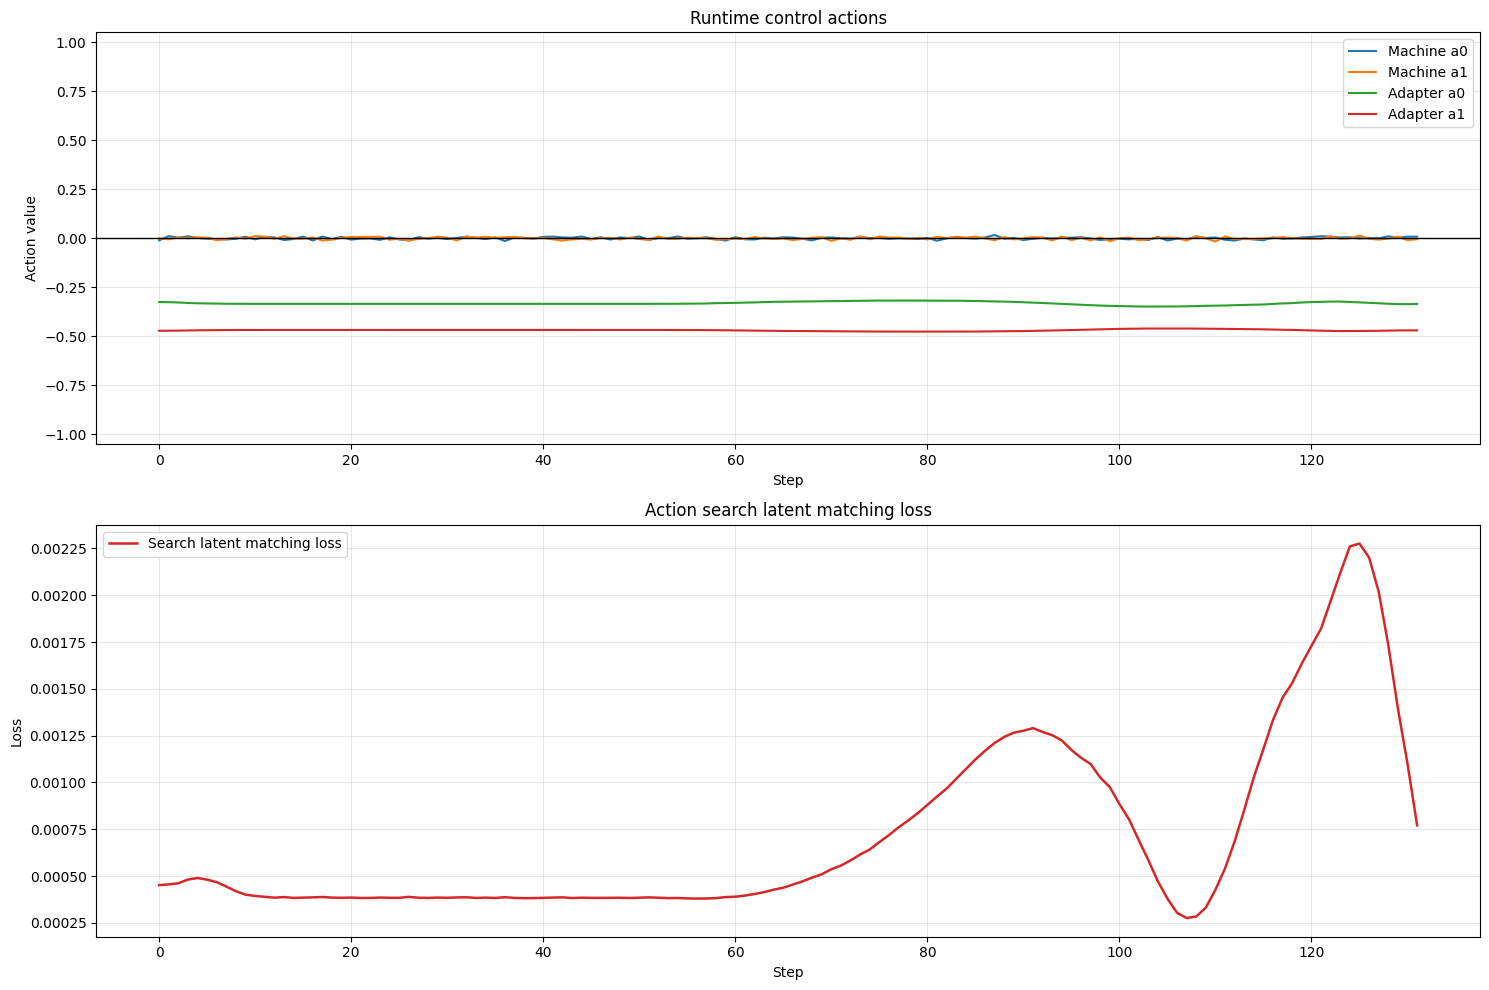

machine actions mean: [ 0.000252   -0.00034605]
machine actions std : [0.00605413 0.00641443]
adapter actions mean: [-0.3316579  -0.46872893]
adapter actions std : [0.00781257 0.00410412]
search loss mean: 0.000716418655814998
search loss std : 0.00048291392907921093


In [150]:
# Runtime Control / Diagnostics

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(actions))

fig, axs = plt.subplots(2,1, figsize=(15, 10))

axs[0].plot(steps, actions[:, 0], lw=1.5, label="Machine a0")
axs[0].plot(steps, actions[:, 1], lw=1.5, label="Machine a1")
axs[0].plot(steps, adapter_actions[:, 0], lw=1.5, label="Adapter a0")
axs[0].plot(steps, adapter_actions[:, 1], lw=1.5, label="Adapter a1")
axs[0].axhline(0, color="black", lw=1)
axs[0].set_xlabel("Step")
axs[0].set_ylabel("Action value")
axs[0].set_title("Runtime control actions")
axs[0].set_ylim(-1.05, 1.05)
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(steps, search_losses, color="tab:red", lw=1.8, label="Search latent matching loss")
axs[1].set_xlabel("Step")
axs[1].set_ylabel("Loss")
axs[1].set_title("Action search latent matching loss")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

print("machine actions mean:", actions.mean(axis=0))
print("machine actions std :", actions.std(axis=0))
print("adapter actions mean:", adapter_actions.mean(axis=0))
print("adapter actions std :", adapter_actions.std(axis=0))
print("search loss mean:", search_losses.mean())
print("search loss std :", search_losses.std())


# Experiments

## 100 Episode Reward Evaluation

episode 001/100 reward: -135.04
episode 002/100 reward: -135.48
episode 003/100 reward: -267.93
episode 004/100 reward: -140.01
episode 005/100 reward: -104.50
episode 006/100 reward: -96.57
episode 007/100 reward: -71.05
episode 008/100 reward: -126.66
episode 009/100 reward: -81.27
episode 010/100 reward: -346.43
episode 011/100 reward: -117.64
episode 012/100 reward: -75.92
episode 013/100 reward: -153.42
episode 014/100 reward: -180.69
episode 015/100 reward: -124.64
episode 016/100 reward: -263.92
episode 017/100 reward: -195.34
episode 018/100 reward: -157.34
episode 019/100 reward: -116.34
episode 020/100 reward: -85.40
episode 021/100 reward: -113.77
episode 022/100 reward: -8.28
episode 023/100 reward: -87.65
episode 024/100 reward: -230.70
episode 025/100 reward: -164.01
episode 026/100 reward: -205.96
episode 027/100 reward: -280.21
episode 028/100 reward: -193.43
episode 029/100 reward: -102.96
episode 030/100 reward: -124.47
episode 031/100 reward: -66.65
episode 032/100 r

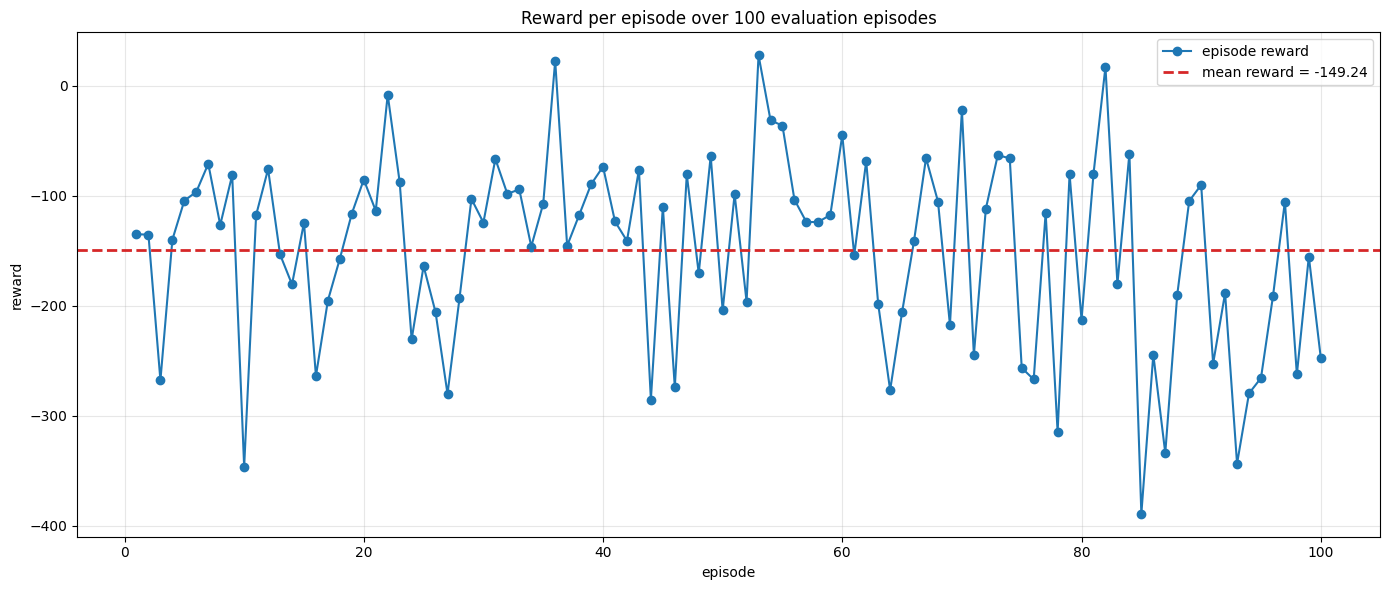

mean reward over 100 episodes: -149.24
reward std: 86.34


In [124]:
# Runtime Control / 100 Episode Reward Evaluation

import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt


N_EVAL_EPISODES = 100
EVAL_MAX_STEPS = 500
EVAL_MACHINE_HIST_LEN = 8
EVAL_N_ACTION_CANDIDATES = 8192
EVAL_DELTA_Z_SCALE = 1.5
EVAL_SEED = 42


def rollout_lander_machine_forward_reward(
    ae_model,
    lstm_model,
    idm_model,
    adapter_model,
    fdm_model,
    machine_forward_model,
    max_steps=500,
    history_len=None,
    machine_hist_len=8,
    overlay_decay=None,
    n_action_candidates=512,
    delta_z_scale=1.0,
    seed=None,
    device=None,
):
    if device is None:
        device = DEVICE

    if history_len is None:
        history_len = SEQ_LEN - 1 if "SEQ_LEN" in globals() else 31

    if overlay_decay is None:
        overlay_decay = OVERLAY_DECAY if "OVERLAY_DECAY" in globals() else 0.9

    env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    ae_model = ae_model.to(device).eval()
    lstm_model = lstm_model.to(device).eval()
    idm_model = idm_model.to(device).eval()
    adapter_model = adapter_model.to(device).eval()
    fdm_model = fdm_model.to(device).eval()
    machine_forward_model = machine_forward_model.to(device).eval()

    x_hist = []
    total_reward = 0.0

    for step in range(max_steps):
        rgb = env.render()
        x = preprocess_rgb(rgb).to(device)
        x_hist.append(x.squeeze(0))

        if len(x_hist) > history_len:
            x_hist = x_hist[-history_len:]

        with torch.no_grad():
            hist = x_hist

            if len(hist) < history_len:
                pad = [hist[0]] * (history_len - len(hist))
                hist = pad + hist

            x_seq = torch.stack(hist, dim=0)[None]

            x_overlay = overlay_frames(x_seq, decay=overlay_decay)
            _, m_t = ae_model(x_overlay)

            z_hist = torch.stack(
                [ae_model(x_seq[:, t])[1] for t in range(x_seq.shape[1])],
                dim=1,
            )
            z_t = z_hist[:, -1, :]

            h_seq, _ = lstm_model(z_hist)
            h_t = h_seq[:, -1, :]

            c_t = torch.cat([z_t, h_t, m_t], dim=-1)
            latent_a = idm_model(c_t)
            delta_z_desired = delta_z_scale * fdm_model(c_t, latent_a)

            z_machine_hist = z_hist[:, -machine_hist_len:, :]

            if z_machine_hist.shape[1] < machine_hist_len:
                pad = z_machine_hist[:, :1, :].expand(
                    z_machine_hist.shape[0],
                    machine_hist_len - z_machine_hist.shape[1],
                    z_machine_hist.shape[2],
                )
                z_machine_hist = torch.cat([pad, z_machine_hist], dim=1)

            a_star, _ = choose_action_by_machine_forward(
                machine_forward_model=machine_forward_model,
                z_hist=z_machine_hist,
                delta_z_desired=delta_z_desired,
                n_candidates=n_action_candidates,
            )

            action = a_star[0].detach().cpu().numpy()
            action = np.clip(action, -1.0, 1.0).astype(np.float32)

        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)

        if terminated or truncated:
            break

    env.close()
    return total_reward


eval_rewards = []

for episode_idx in range(N_EVAL_EPISODES):
    episode_seed = EVAL_SEED + episode_idx if EVAL_SEED is not None else None
    reward = rollout_lander_machine_forward_reward(
        ae_model=ae_model,
        lstm_model=lstm_model,
        idm_model=idm_model,
        adapter_model=adapter_model,
        fdm_model=fdm_model,
        machine_forward_model=machine_forward_model,
        max_steps=EVAL_MAX_STEPS,
        machine_hist_len=EVAL_MACHINE_HIST_LEN,
        n_action_candidates=EVAL_N_ACTION_CANDIDATES,
        delta_z_scale=EVAL_DELTA_Z_SCALE,
        seed=episode_seed,
    )
    eval_rewards.append(reward)
    print(f"episode {episode_idx + 1:03d}/{N_EVAL_EPISODES} reward: {reward:.2f}")


eval_rewards = np.array(eval_rewards, dtype=np.float32)
mean_eval_reward = float(eval_rewards.mean())

episode_numbers = np.arange(1, N_EVAL_EPISODES + 1)

plt.figure(figsize=(14, 6))
plt.plot(episode_numbers, eval_rewards, marker="o", linewidth=1.5, label="episode reward")
plt.axhline(
    mean_eval_reward,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label=f"mean reward = {mean_eval_reward:.2f}",
)
plt.title("Reward per episode over 100 evaluation episodes")
plt.xlabel("episode")
plt.ylabel("reward")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"mean reward over {N_EVAL_EPISODES} episodes: {mean_eval_reward:.2f}")
print(f"reward std: {eval_rewards.std():.2f}")


## 100 episodes: random policy benchmark

In [125]:
# 100 episodes: random policy benchmark

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

N_RANDOM_EPISODES = 100
RANDOM_MAX_STEPS = 500
RANDOM_SEED = None

random_rewards = []

for episode in range(N_RANDOM_EPISODES):
    env = gym.make("LunarLanderContinuous-v3")
    seed = RANDOM_SEED + episode if RANDOM_SEED is not None else None
    obs, info = env.reset(seed=seed)
    env.action_space.seed(seed)

    total_reward = 0.0

    for step in range(RANDOM_MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)

        if terminated or truncated:
            break

    env.close()
    random_rewards.append(total_reward)
    print(f"episode {episode + 1:03d}/{N_RANDOM_EPISODES}: reward = {total_reward:.2f}")

random_rewards = np.array(random_rewards, dtype=np.float32)
random_mean_reward = random_rewards.mean()
random_std_reward = random_rewards.std()

random_episodes = np.arange(1, N_RANDOM_EPISODES + 1)

plt.figure(figsize=(14, 6))
plt.plot(random_episodes, random_rewards, linewidth=1.5, label="random reward per episode")
plt.axhline(
    random_mean_reward,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label=f"random 
    mean reward = {random_mean_reward:.2f}, std = {random_std_reward:.2f}",
)
plt.title("Random policy rewards from 100 evaluation episodes")
plt.xlabel("episode")
plt.ylabel("reward")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"random mean reward over {N_RANDOM_EPISODES} episodes: {random_mean_reward:.2f}")
print(f"random reward std over {N_RANDOM_EPISODES} episodes: {random_std_reward:.2f}")


SyntaxError: unterminated string literal (detected at line 46) (2261403573.py, line 46)

### Generalization Experiment Across 4 Models

{'model': 'nuwan-exp-1', 'params': 31086, 'sensitivity': 0.006634772755205631, 'temporal_usage': 0.22998207807540894, 'diversity': 0.04814847186207771}
{'model': 'mb-dev', 'params': 578308, 'sensitivity': 0.011319685727357864, 'temporal_usage': 0.6849625706672668, 'diversity': 0.07530435174703598}
{'model': 'sn-dev', 'params': 594692, 'sensitivity': 0.0124477818608284, 'temporal_usage': 0.5972903966903687, 'diversity': 0.07824507355690002}
{'model': 'ak-dev', 'params': 2716108, 'sensitivity': 0.20846398174762726, 'temporal_usage': 1.004050850868225, 'diversity': 0.16393382847309113}


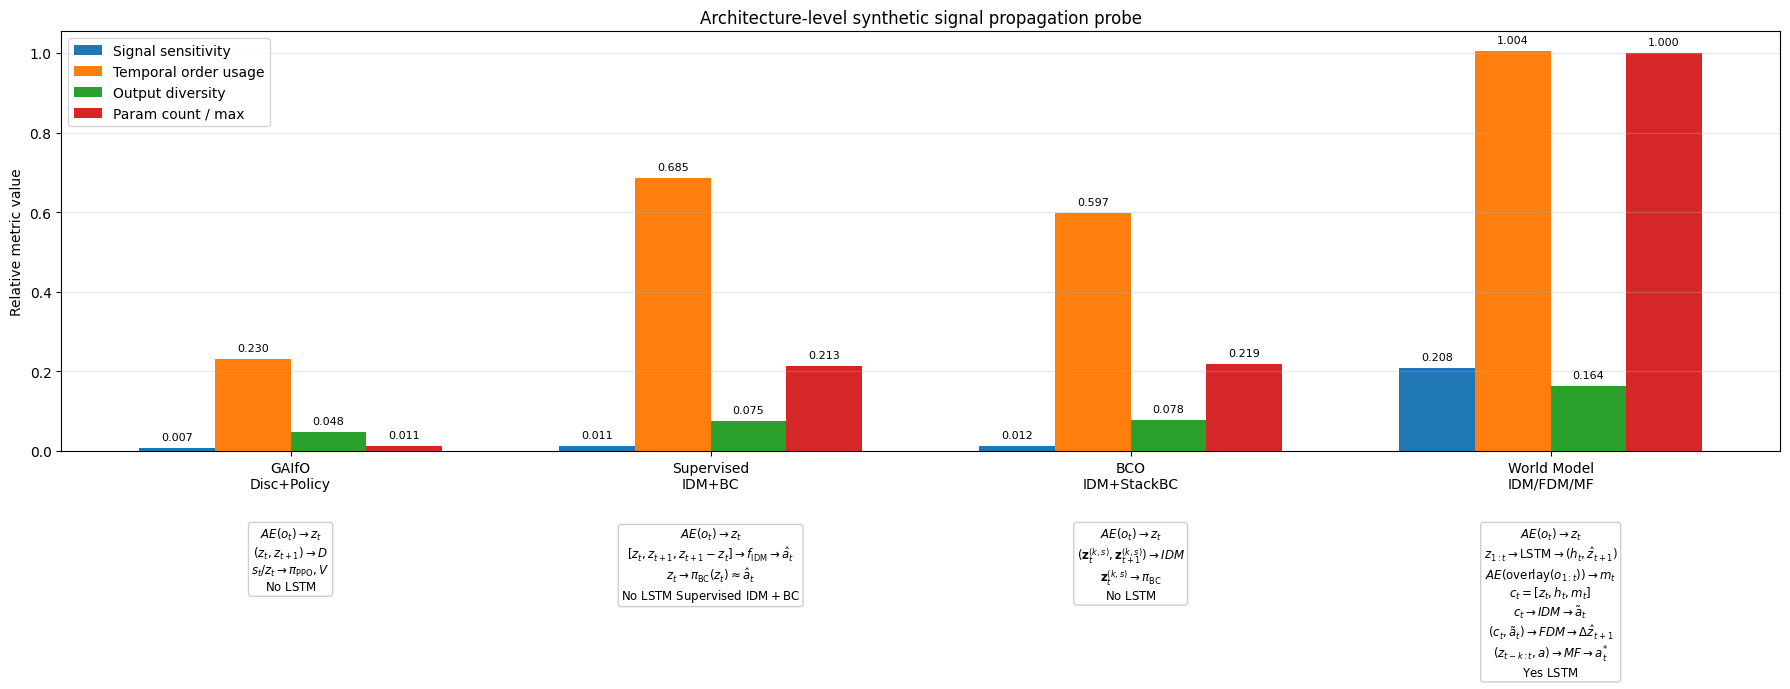

In [16]:
# ============================================================
# Full architecture benchmark + plot
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# Shared synthetic signal
# ============================================================

B = 256
Z_DIM = 64
ACTION_DIM = 2
SEQ_LEN = 8
LATENT_A_DIM = 8

def make_signal(batch=B, seq_len=SEQ_LEN, z_dim=Z_DIM, noise=0.03):
    t = torch.linspace(0, 1, seq_len).view(1, seq_len, 1)
    freqs = torch.linspace(1, 4, z_dim).view(1, 1, z_dim)
    phase = torch.rand(batch, 1, z_dim) * 2 * np.pi

    trend = t * torch.randn(batch, 1, z_dim) * 0.4
    wave = torch.sin(2 * np.pi * freqs * t + phase)
    eps = noise * torch.randn(batch, seq_len, z_dim)

    z = wave + trend + eps
    return z.to(DEVICE)

z_seq = make_signal()
z_pert = z_seq + 0.01 * torch.randn_like(z_seq)
z_rev = torch.flip(z_seq, dims=[1])

# ============================================================
# 1. nuwan-exp-1: GAIfO-style discriminator + PPO policy/value
# ============================================================

class NuwanDiscriminator(nn.Module):
    def __init__(self, z_dim=64, hidden_dim=84):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, z_t, z_tp1):
        return self.net(torch.cat([z_t, z_tp1], dim=-1))


class NuwanPolicyNetwork(nn.Module):
    def __init__(self, state_dim=64, action_dim=2, max_action=1.0, hidden_dim=84):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.log_std_head = nn.Linear(hidden_dim, action_dim)
        self.value_head = nn.Linear(hidden_dim, 1)
        self.max_action = max_action

    def forward(self, state):
        x = self.shared(state)
        mean = torch.tanh(self.mean_head(x)) * self.max_action
        log_std = torch.clamp(self.log_std_head(x), -5, 2)
        value = self.value_head(x)
        return mean, log_std, value


# ============================================================
# 2. mb-dev: supervised IDM + latent behavioral cloning
# ============================================================

class MBInverseDynamicsMLP(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=512):
        super().__init__()
        input_dim = z_dim * 3
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim),
        )

    def forward(self, z_t, z_tp1):
        dz = z_tp1 - z_t
        return self.net(torch.cat([z_t, z_tp1, dz], dim=1))


class MBLatentPolicy(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


# ============================================================
# 3. sn-dev: BCO IDM + stacked-latent behavioral cloning
# ============================================================

class SNBCOInverseDynamics(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * z_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim),
        )

    def forward(self, z_t, z_tp1):
        return self.net(torch.cat([z_t, z_tp1], dim=-1))


class SNStackedBCPolicy(nn.Module):
    def __init__(self, z_dim=64, stack=4, action_dim=2, hidden_dim=256):
        super().__init__()
        self.stack = stack
        self.net = nn.Sequential(
            nn.Linear(z_dim * stack, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, z_seq):
        z_stack = z_seq[:, -self.stack:, :].reshape(z_seq.shape[0], -1)
        return self.net(z_stack)


# ============================================================
# 4. ak-dev: World Model + Machine Forward
# ============================================================

class AKLatentLSTM(nn.Module):
    def __init__(self, z_dim=64, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=z_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, z_dim),
        )

    def forward(self, z_seq):
        h_seq, (h_n, _) = self.lstm(z_seq)
        z_pred = self.head(h_n[-1])
        return h_seq, z_pred


class AKIDMModel(nn.Module):
    def __init__(self, c_dim=384, latent_a_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, latent_a_dim),
            nn.Tanh(),
        )

    def forward(self, c_t):
        return self.net(c_t)


class AKFDMModel(nn.Module):
    def __init__(self, c_dim=384, z_dim=64, latent_a_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim + latent_a_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, z_dim),
        )

    def forward(self, c_t, latent_a):
        return self.net(torch.cat([c_t, latent_a], dim=-1))


class AKMachineForwardModel(nn.Module):
    def __init__(self, z_dim=64, real_a_dim=2, hidden_dim=256):
        super().__init__()
        self.history_encoder = nn.LSTM(
            input_size=z_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim + real_a_dim),
            nn.Linear(hidden_dim + real_a_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, z_dim),
        )

    def forward(self, z_hist, a_real):
        _, (h_n, _) = self.history_encoder(z_hist)
        h_t = h_n[-1]
        return self.head(torch.cat([h_t, a_real], dim=-1))


class AKWorldModelPipeline(nn.Module):
    def __init__(self, z_dim=64, latent_a_dim=8, action_dim=2):
        super().__init__()
        self.lstm = AKLatentLSTM(z_dim=z_dim)
        self.idm = AKIDMModel(c_dim=384, latent_a_dim=latent_a_dim)
        self.fdm = AKFDMModel(c_dim=384, z_dim=z_dim, latent_a_dim=latent_a_dim)
        self.machine = AKMachineForwardModel(z_dim=z_dim, real_a_dim=action_dim)

    def forward(self, z_seq):
        h_seq, z_lstm_next = self.lstm(z_seq)
        z_t = z_seq[:, -1]
        h_t = h_seq[:, -1]

        # m_t proxy: real model uses AE(overlay frames) -> m_t
        m_t = z_seq.mean(dim=1)

        c_t = torch.cat([z_t, h_t, m_t], dim=-1)

        latent_a = self.idm(c_t)
        dz_desired = self.fdm(c_t, latent_a)

        a_zero = torch.zeros(z_seq.shape[0], ACTION_DIM, device=z_seq.device)
        dz_machine = self.machine(z_seq[:, -8:], a_zero)

        return dz_desired, latent_a, dz_machine


# ============================================================
# Metrics
# ============================================================

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def output_flat(y):
    if isinstance(y, tuple):
        y = torch.cat(
            [v.reshape(v.shape[0], -1) for v in y if torch.is_tensor(v)],
            dim=-1,
        )
    return y.reshape(y.shape[0], -1)


@torch.no_grad()
def sensitivity(model, fwd, x, x_pert):
    y = output_flat(fwd(model, x))
    yp = output_flat(fwd(model, x_pert))
    return (
        (yp - y).norm(dim=1)
        / ((x_pert - x).reshape(x.shape[0], -1).norm(dim=1) + 1e-8)
    ).mean().item()


@torch.no_grad()
def temporal_usage(model, fwd, x, x_rev):
    y = output_flat(fwd(model, x))
    yr = output_flat(fwd(model, x_rev))
    return ((yr - y).norm(dim=1) / (y.norm(dim=1) + 1e-8)).mean().item()


@torch.no_grad()
def output_diversity(model, fwd, x):
    y = output_flat(fwd(model, x))
    return y.std(dim=0).mean().item()


# ============================================================
# Build models and forward wrappers
# ============================================================

models = {}

nuwan_disc = NuwanDiscriminator().to(DEVICE)
nuwan_policy = NuwanPolicyNetwork().to(DEVICE)
models["nuwan-exp-1"] = (
    nn.ModuleList([nuwan_disc, nuwan_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x[:, -1])[0],
        m[1](x[:, -1])[2],
    ),
)

mb_idm = MBInverseDynamicsMLP().to(DEVICE)
mb_policy = MBLatentPolicy().to(DEVICE)
models["mb-dev"] = (
    nn.ModuleList([mb_idm, mb_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x[:, -1]),
    ),
)

sn_idm = SNBCOInverseDynamics().to(DEVICE)
sn_policy = SNStackedBCPolicy(stack=4).to(DEVICE)
models["sn-dev"] = (
    nn.ModuleList([sn_idm, sn_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x),
    ),
)

ak_world = AKWorldModelPipeline().to(DEVICE)
models["ak-dev"] = (
    ak_world,
    lambda m, x: m(x),
)

# ============================================================
# Run benchmark
# ============================================================

rows = []

for name, (model, fwd) in models.items():
    model.eval()
    rows.append({
        "model": name,
        "params": count_params(model),
        "sensitivity": sensitivity(model, fwd, z_seq, z_pert),
        "temporal_usage": temporal_usage(model, fwd, z_seq, z_rev),
        "diversity": output_diversity(model, fwd, z_seq),
    })

for r in rows:
    print(r)

# ============================================================
# Plot: architecture-level synthetic signal propagation probe
# ============================================================

names = [r["model"] for r in rows]
params = np.array([r["params"] for r in rows], dtype=float)
sens = np.array([r["sensitivity"] for r in rows])
temp = np.array([r["temporal_usage"] for r in rows])
div = np.array([r["diversity"] for r in rows])

params_norm = params / params.max()

display_names = {
    "nuwan-exp-1": "GAIfO\nDisc+Policy",
    "mb-dev": "Supervised\nIDM+BC",
    "sn-dev": "BCO\nIDM+StackBC",
    "ak-dev": "World Model\nIDM/FDM/MF",
}

xtick_labels = [display_names.get(n, n) for n in names]

equation_blocks = {
    "nuwan-exp-1":
        r"$AE(o_t)\to z_t$" "\n"
        r"$(z_t,z_{t+1})\to D$" "\n"
        r"$s_t/z_t\to \pi_{\mathrm{PPO}},V$" "\n"
        r"$\mathrm{No\ LSTM}$",

    "mb-dev":
        r"$AE(o_t)\to z_t$" "\n"
        r"$[z_t,z_{t+1},z_{t+1}-z_t]\to f_{\mathrm{IDM}}\to \hat{a}_t$" "\n"
        r"$z_t\to \pi_{\mathrm{BC}}(z_t)\approx \hat{a}_t$" "\n"
        r"$\mathrm{No\ LSTM\ Supervised\ IDM + BC}$",



    "sn-dev":
    r"$AE(o_t)\to z_t$" "\n"
    r"$(\mathbf{z}_t^{(k,s)}, \mathbf{z}_{t+1}^{(k,s)})\to IDM$" "\n"
    r"$\mathbf{z}_t^{(k,s)}\to \pi_{\mathrm{BC}}$" "\n"
    r"$\mathrm{No\ LSTM}$",


    "ak-dev":
        r"$AE(o_t)\to z_t$" "\n"
        r"$z_{1:t}\to \mathrm{LSTM}\to(h_t,\hat z_{t+1})$" "\n"
        r"$AE(\mathrm{overlay}(o_{1:t}))\to m_t$" "\n"
        r"$c_t=[z_t,h_t,m_t]$" "\n"
        r"$c_t\to IDM\to \tilde a_t$" "\n"
        r"$(c_t,\tilde a_t)\to FDM\to \Delta \hat z_{t+1}$" "\n"
        r"$(z_{t-k:t},a)\to MF\to a_t^{*}$" "\n"
        r"$\mathrm{Yes\ LSTM}$",
}

eq_labels = [equation_blocks.get(n, "") for n in names]

x = np.arange(len(names))
w = 0.18

fig, ax = plt.subplots(figsize=(18, 7))

bars1 = ax.bar(x - 1.5*w, sens, width=w, label="Signal sensitivity")
bars2 = ax.bar(x - 0.5*w, temp, width=w, label="Temporal order usage")
bars3 = ax.bar(x + 0.5*w, div, width=w, label="Output diversity")
bars4 = ax.bar(x + 1.5*w, params_norm, width=w, label="Param count / max")

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_ylabel("Relative metric value")
ax.set_title("Architecture-level synthetic signal propagation probe")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left")

def add_bar_labels(bar_container, fmt="{:.3f}", fontsize=8):
    for bar in bar_container:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.015,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=0,
        )

add_bar_labels(bars1, fmt="{:.3f}")
add_bar_labels(bars2, fmt="{:.3f}")
add_bar_labels(bars3, fmt="{:.3f}")
add_bar_labels(bars4, fmt="{:.3f}")

plt.subplots_adjust(bottom=0.28)

for i, txt in enumerate(eq_labels):
    ax.text(
        x[i],
        -0.18,
        txt,
        ha="center",
        va="top",
        fontsize=8.5,
        transform=ax.get_xaxis_transform(),
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.8",
            alpha=0.95,
        ),
    )

plt.savefig(
    "architecture_signal_probe_latex_with_bar_values.png",
    dpi=200,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()

{'model': 'nuwan-exp-1', 'params': 31086, 'sensitivity': 0.006634772755205631, 'temporal_usage': 0.22998207807540894, 'diversity': 0.04814847186207771}
{'model': 'mb-dev', 'params': 578308, 'sensitivity': 0.011319685727357864, 'temporal_usage': 0.6849625706672668, 'diversity': 0.07530435174703598}
{'model': 'sn-dev', 'params': 594692, 'sensitivity': 0.0124477818608284, 'temporal_usage': 0.5972903966903687, 'diversity': 0.07824507355690002}
{'model': 'ak-dev', 'params': 2716108, 'sensitivity': 0.20846398174762726, 'temporal_usage': 1.004050850868225, 'diversity': 0.16393382847309113}


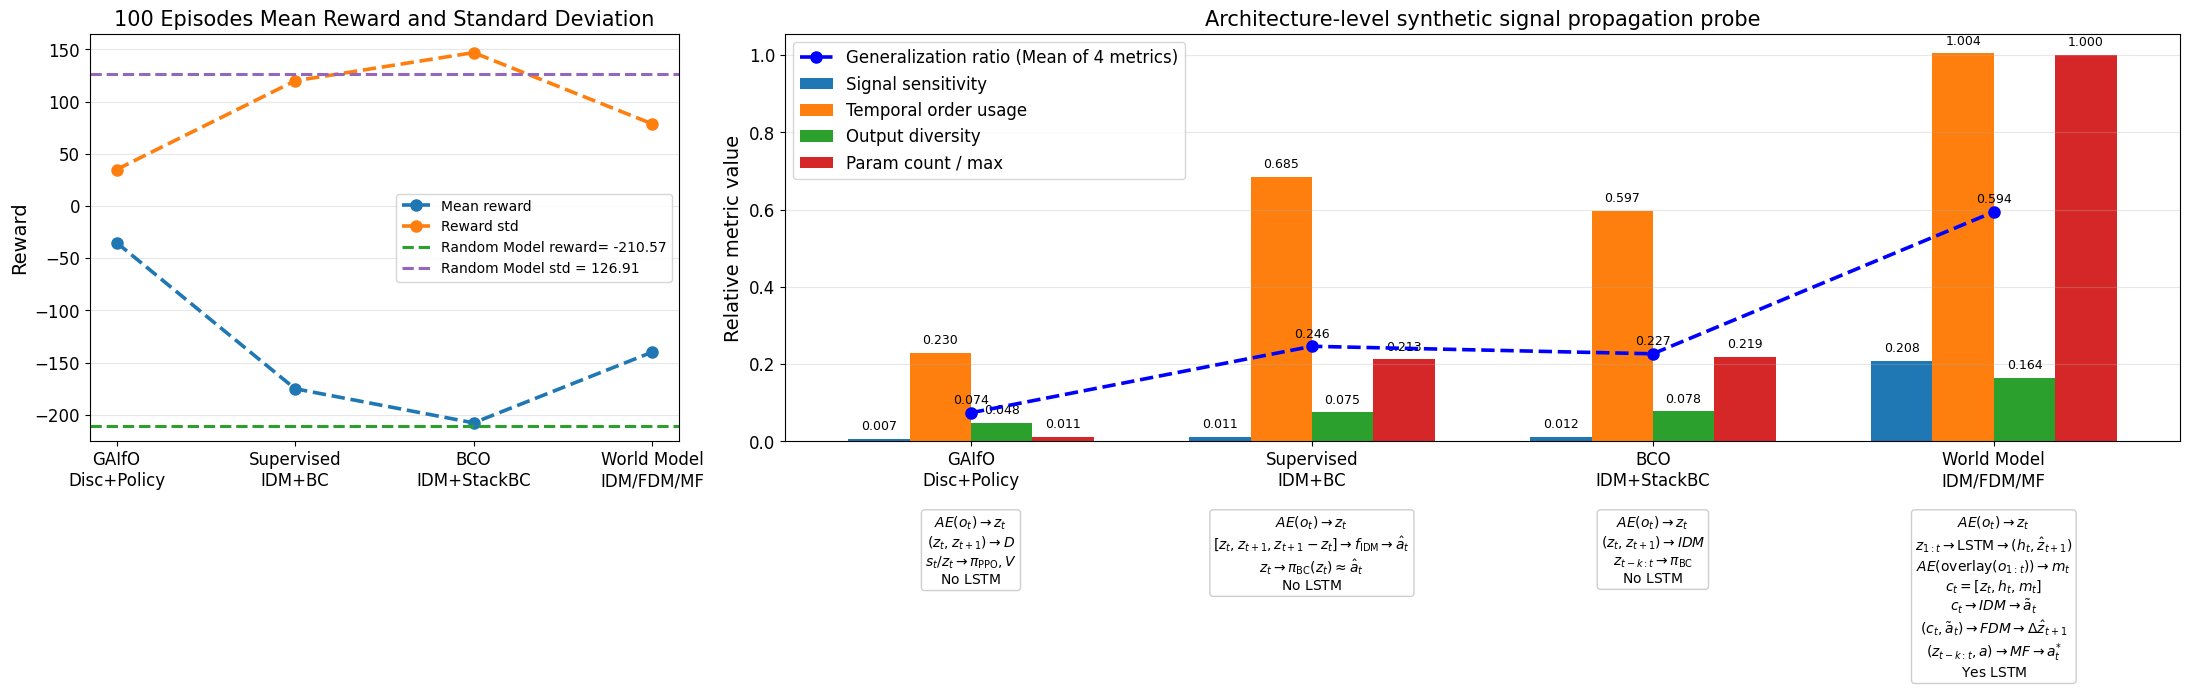

In [17]:
# ============================================================
# Full architecture benchmark + plot
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# Shared synthetic signal
# ============================================================

B = 256
Z_DIM = 64
ACTION_DIM = 2
SEQ_LEN = 8
LATENT_A_DIM = 8

def make_signal(batch=B, seq_len=SEQ_LEN, z_dim=Z_DIM, noise=0.03):
    t = torch.linspace(0, 1, seq_len).view(1, seq_len, 1)
    freqs = torch.linspace(1, 4, z_dim).view(1, 1, z_dim)
    phase = torch.rand(batch, 1, z_dim) * 2 * np.pi

    trend = t * torch.randn(batch, 1, z_dim) * 0.4
    wave = torch.sin(2 * np.pi * freqs * t + phase)
    eps = noise * torch.randn(batch, seq_len, z_dim)

    z = wave + trend + eps
    return z.to(DEVICE)

z_seq = make_signal()
z_pert = z_seq + 0.01 * torch.randn_like(z_seq)
z_rev = torch.flip(z_seq, dims=[1])

# ============================================================
# 1. nuwan-exp-1: GAIfO-style discriminator + PPO policy/value
# ============================================================

class NuwanDiscriminator(nn.Module):
    def __init__(self, z_dim=64, hidden_dim=84):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, z_t, z_tp1):
        return self.net(torch.cat([z_t, z_tp1], dim=-1))


class NuwanPolicyNetwork(nn.Module):
    def __init__(self, state_dim=64, action_dim=2, max_action=1.0, hidden_dim=84):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.log_std_head = nn.Linear(hidden_dim, action_dim)
        self.value_head = nn.Linear(hidden_dim, 1)
        self.max_action = max_action

    def forward(self, state):
        x = self.shared(state)
        mean = torch.tanh(self.mean_head(x)) * self.max_action
        log_std = torch.clamp(self.log_std_head(x), -5, 2)
        value = self.value_head(x)
        return mean, log_std, value


# ============================================================
# 2. mb-dev: supervised IDM + latent behavioral cloning
# ============================================================

class MBInverseDynamicsMLP(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=512):
        super().__init__()
        input_dim = z_dim * 3
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim),
        )

    def forward(self, z_t, z_tp1):
        dz = z_tp1 - z_t
        return self.net(torch.cat([z_t, z_tp1, dz], dim=1))


class MBLatentPolicy(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


# ============================================================
# 3. sn-dev: BCO IDM + stacked-latent behavioral cloning
# ============================================================

class SNBCOInverseDynamics(nn.Module):
    def __init__(self, z_dim=64, action_dim=2, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * z_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim),
        )

    def forward(self, z_t, z_tp1):
        return self.net(torch.cat([z_t, z_tp1], dim=-1))


class SNStackedBCPolicy(nn.Module):
    def __init__(self, z_dim=64, stack=4, action_dim=2, hidden_dim=256):
        super().__init__()
        self.stack = stack
        self.net = nn.Sequential(
            nn.Linear(z_dim * stack, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, z_seq):
        z_stack = z_seq[:, -self.stack:, :].reshape(z_seq.shape[0], -1)
        return self.net(z_stack)


# ============================================================
# 4. ak-dev: World Model + Machine Forward
# ============================================================

class AKLatentLSTM(nn.Module):
    def __init__(self, z_dim=64, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=z_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, z_dim),
        )

    def forward(self, z_seq):
        h_seq, (h_n, _) = self.lstm(z_seq)
        z_pred = self.head(h_n[-1])
        return h_seq, z_pred


class AKIDMModel(nn.Module):
    def __init__(self, c_dim=384, latent_a_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, latent_a_dim),
            nn.Tanh(),
        )

    def forward(self, c_t):
        return self.net(c_t)


class AKFDMModel(nn.Module):
    def __init__(self, c_dim=384, z_dim=64, latent_a_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim + latent_a_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, z_dim),
        )

    def forward(self, c_t, latent_a):
        return self.net(torch.cat([c_t, latent_a], dim=-1))


class AKMachineForwardModel(nn.Module):
    def __init__(self, z_dim=64, real_a_dim=2, hidden_dim=256):
        super().__init__()
        self.history_encoder = nn.LSTM(
            input_size=z_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim + real_a_dim),
            nn.Linear(hidden_dim + real_a_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, z_dim),
        )

    def forward(self, z_hist, a_real):
        _, (h_n, _) = self.history_encoder(z_hist)
        h_t = h_n[-1]
        return self.head(torch.cat([h_t, a_real], dim=-1))


class AKWorldModelPipeline(nn.Module):
    def __init__(self, z_dim=64, latent_a_dim=8, action_dim=2):
        super().__init__()
        self.lstm = AKLatentLSTM(z_dim=z_dim)
        self.idm = AKIDMModel(c_dim=384, latent_a_dim=latent_a_dim)
        self.fdm = AKFDMModel(c_dim=384, z_dim=z_dim, latent_a_dim=latent_a_dim)
        self.machine = AKMachineForwardModel(z_dim=z_dim, real_a_dim=action_dim)

    def forward(self, z_seq):
        h_seq, z_lstm_next = self.lstm(z_seq)
        z_t = z_seq[:, -1]
        h_t = h_seq[:, -1]

        # m_t proxy: real model uses AE(overlay frames) -> m_t
        m_t = z_seq.mean(dim=1)

        c_t = torch.cat([z_t, h_t, m_t], dim=-1)

        latent_a = self.idm(c_t)
        dz_desired = self.fdm(c_t, latent_a)

        a_zero = torch.zeros(z_seq.shape[0], ACTION_DIM, device=z_seq.device)
        dz_machine = self.machine(z_seq[:, -8:], a_zero)

        return dz_desired, latent_a, dz_machine


# ============================================================
# Metrics
# ============================================================

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def output_flat(y):
    if isinstance(y, tuple):
        y = torch.cat(
            [v.reshape(v.shape[0], -1) for v in y if torch.is_tensor(v)],
            dim=-1,
        )
    return y.reshape(y.shape[0], -1)


@torch.no_grad()
def sensitivity(model, fwd, x, x_pert):
    y = output_flat(fwd(model, x))
    yp = output_flat(fwd(model, x_pert))
    return (
        (yp - y).norm(dim=1)
        / ((x_pert - x).reshape(x.shape[0], -1).norm(dim=1) + 1e-8)
    ).mean().item()


@torch.no_grad()
def temporal_usage(model, fwd, x, x_rev):
    y = output_flat(fwd(model, x))
    yr = output_flat(fwd(model, x_rev))
    return ((yr - y).norm(dim=1) / (y.norm(dim=1) + 1e-8)).mean().item()


@torch.no_grad()
def output_diversity(model, fwd, x):
    y = output_flat(fwd(model, x))
    return y.std(dim=0).mean().item()


# ============================================================
# Build models and forward wrappers
# ============================================================

models = {}

nuwan_disc = NuwanDiscriminator().to(DEVICE)
nuwan_policy = NuwanPolicyNetwork().to(DEVICE)
models["nuwan-exp-1"] = (
    nn.ModuleList([nuwan_disc, nuwan_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x[:, -1])[0],
        m[1](x[:, -1])[2],
    ),
)

mb_idm = MBInverseDynamicsMLP().to(DEVICE)
mb_policy = MBLatentPolicy().to(DEVICE)
models["mb-dev"] = (
    nn.ModuleList([mb_idm, mb_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x[:, -1]),
    ),
)

sn_idm = SNBCOInverseDynamics().to(DEVICE)
sn_policy = SNStackedBCPolicy(stack=4).to(DEVICE)
models["sn-dev"] = (
    nn.ModuleList([sn_idm, sn_policy]),
    lambda m, x: (
        m[0](x[:, -2], x[:, -1]),
        m[1](x),
    ),
)

ak_world = AKWorldModelPipeline().to(DEVICE)
models["ak-dev"] = (
    ak_world,
    lambda m, x: m(x),
)

# ============================================================
# Run benchmark
# ============================================================

rows = []

for name, (model, fwd) in models.items():
    model.eval()
    rows.append({
        "model": name,
        "params": count_params(model),
        "sensitivity": sensitivity(model, fwd, z_seq, z_pert),
        "temporal_usage": temporal_usage(model, fwd, z_seq, z_rev),
        "diversity": output_diversity(model, fwd, z_seq),
    })

for r in rows:
    print(r)

# ============================================================
# Plot: architecture-level synthetic signal propagation probe
# ============================================================

names = [r["model"] for r in rows]
params = np.array([r["params"] for r in rows], dtype=float)
sens = np.array([r["sensitivity"] for r in rows])
temp = np.array([r["temporal_usage"] for r in rows])
div = np.array([r["diversity"] for r in rows])

params_norm = params / params.max()
generalization_ratio = np.mean(np.stack([sens, temp, div, params_norm], axis=0), axis=0)

display_names = {
    "nuwan-exp-1": "GAIfO\nDisc+Policy",
    "mb-dev": "Supervised\nIDM+BC",
    "sn-dev": "BCO\nIDM+StackBC",
    "ak-dev": "World Model\nIDM/FDM/MF",
}

xtick_labels = [display_names.get(n, n) for n in names]

equation_blocks = {
    "nuwan-exp-1":
        r"$AE(o_t)\to z_t$" "\n"
        r"$(z_t,z_{t+1})\to D$" "\n"
        r"$s_t/z_t\to \pi_{\mathrm{PPO}},V$" "\n"
        r"$\mathrm{No\ LSTM}$",

    "mb-dev":
        r"$AE(o_t)\to z_t$" "\n"
        r"$[z_t,z_{t+1},z_{t+1}-z_t]\to f_{\mathrm{IDM}}\to \hat{a}_t$" "\n"
        r"$z_t\to \pi_{\mathrm{BC}}(z_t)\approx \hat{a}_t$" "\n"
        r"$\mathrm{No\ LSTM}$",

    "sn-dev":
        r"$AE(o_t)\to z_t$" "\n"
        r"$(z_t,z_{t+1})\to IDM$" "\n"
        r"$z_{t-k:t}\to \pi_{\mathrm{BC}}$" "\n"
        r"$\mathrm{No\ LSTM}$",

    "ak-dev":
        r"$AE(o_t)\to z_t$" "\n"
        r"$z_{1:t}\to \mathrm{LSTM}\to(h_t,\hat z_{t+1})$" "\n"
        r"$AE(\mathrm{overlay}(o_{1:t}))\to m_t$" "\n"
        r"$c_t=[z_t,h_t,m_t]$" "\n"
        r"$c_t\to IDM\to \tilde a_t$" "\n"
        r"$(c_t,\tilde a_t)\to FDM\to \Delta \hat z_{t+1}$" "\n"
        r"$(z_{t-k:t},a)\to MF\to a_t^{*}$" "\n"
        r"$\mathrm{Yes\ LSTM}$",
}

eq_labels = [equation_blocks.get(n, "") for n in names]

x = np.arange(len(names))
w = 0.18

# Hardcoded ONLY for subplot 1,1.
##########################
##########################
##########################
##########################
##########################
reward_mean = np.array([
    -35.0,  # nuwan-exp-1
    -175.00,  # mb-dev
    -207.70,  # sn-dev
    -139.96,  # ak-dev
], dtype=float)

reward_std = np.array([
    35.0,  # nuwan-exp-1
    120.00,  # mb-dev
    147.0,  # sn-dev
    78.80,  # ak-dev
], dtype=float)

random_mean_reward = -210.57
random_std_reward = 126.91

fig, (ax_reward, ax) = plt.subplots(
    1,
    2,
    figsize=(22, 7),
    gridspec_kw={"width_ratios": [0.95, 2.25]},
)

##########################
##########################
##########################
##########################
##########################

# ============================================================
# Subplot 1,1: hardcoded reward plot
# ============================================================

ax_reward.plot(x, reward_mean, "--o", linewidth=2.6, markersize=8, label="Mean reward")
ax_reward.plot(x, reward_std, "--o", linewidth=2.6, markersize=8, label="Reward std")
ax_reward.axhline(
    random_mean_reward,
    linestyle="--",
    linewidth=2.2,
    color="tab:green",
    label=f"Random Model reward= {random_mean_reward:.2f}",
)
ax_reward.axhline(
    random_std_reward,
    linestyle="--",
    linewidth=2.2,
    color="tab:purple",
    label=f"Random Model std = {random_std_reward:.2f}",
)

ax_reward.set_xticks(x)
ax_reward.set_xticklabels(xtick_labels, fontsize=12)
ax_reward.set_ylabel("Reward", fontsize=14)
ax_reward.set_title("100 Episodes Mean Reward and Standard Deviation", fontsize=15)
ax_reward.tick_params(axis="y", labelsize=12)
ax_reward.grid(True, axis="y", alpha=0.3)
ax_reward.legend(loc="best", fontsize=10)

# ============================================================
# Subplot 1,2: architecture plot + generalization ratio
# ============================================================

bars1 = ax.bar(x - 1.5*w, sens, width=w, label="Signal sensitivity")
bars2 = ax.bar(x - 0.5*w, temp, width=w, label="Temporal order usage")
bars3 = ax.bar(x + 0.5*w, div, width=w, label="Output diversity")
bars4 = ax.bar(x + 1.5*w, params_norm, width=w, label="Param count / max")

line_gen, = ax.plot(
    x,
    generalization_ratio,
    "--o",
    linewidth=2.6,
    markersize=8,
    color="blue",
    label="Generalization ratio (Mean of 4 metrics)",
    zorder=5,
)

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=12)
ax.set_ylabel("Relative metric value", fontsize=14)
ax.set_title("Architecture-level synthetic signal propagation probe", fontsize=15)
ax.tick_params(axis="y", labelsize=12)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", fontsize=12)

def add_bar_labels(bar_container, fmt="{:.3f}", fontsize=9):
    for bar in bar_container:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.015,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=0,
        )

add_bar_labels(bars1, fmt="{:.3f}")
add_bar_labels(bars2, fmt="{:.3f}")
add_bar_labels(bars3, fmt="{:.3f}")
add_bar_labels(bars4, fmt="{:.3f}")

for xi, yi in zip(x, generalization_ratio):
    ax.text(
        xi,
        yi + 0.015,
        f"{yi:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
    )

plt.subplots_adjust(bottom=0.30, wspace=0.12)

for i, txt in enumerate(eq_labels):
    ax.text(
        x[i],
        -0.18,
        txt,
        ha="center",
        va="top",
        fontsize=10,
        transform=ax.get_xaxis_transform(),
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.8",
            alpha=0.95,
        ),
    )

plt.savefig(
    "architecture_signal_probe_latex_with_bar_values.png",
    dpi=200,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()


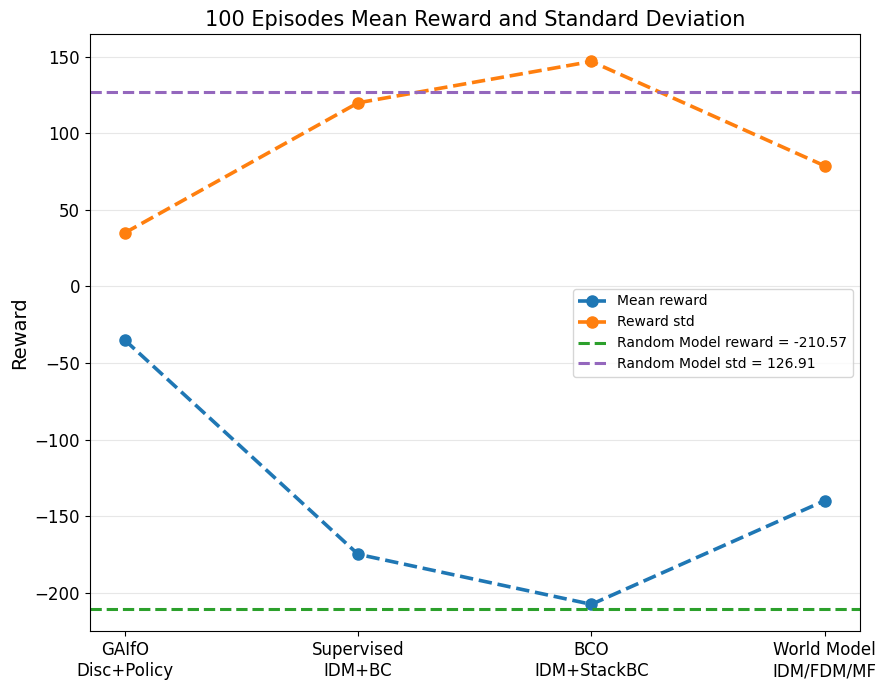

In [18]:
# ============================================================
# Plot 1: hardcoded reward plot
# ============================================================

reward_mean = np.array([
    -35.0,     # nuwan-exp-1
    -175.00,   # mb-dev
    -207.70,   # sn-dev
    -139.96,   # ak-dev
], dtype=float)

reward_std = np.array([
    35.0,      # nuwan-exp-1
    120.00,    # mb-dev
    147.0,     # sn-dev
    78.80,     # ak-dev
], dtype=float)

random_mean_reward = -210.57
random_std_reward = 126.91

fig, ax_reward = plt.subplots(figsize=(9, 7))

ax_reward.plot(
    x,
    reward_mean,
    "--o",
    linewidth=2.6,
    markersize=8,
    label="Mean reward",
)

ax_reward.plot(
    x,
    reward_std,
    "--o",
    linewidth=2.6,
    markersize=8,
    label="Reward std",
)

ax_reward.axhline(
    random_mean_reward,
    linestyle="--",
    linewidth=2.2,
    color="tab:green",
    label=f"Random Model reward = {random_mean_reward:.2f}",
)

ax_reward.axhline(
    random_std_reward,
    linestyle="--",
    linewidth=2.2,
    color="tab:purple",
    label=f"Random Model std = {random_std_reward:.2f}",
)

ax_reward.set_xticks(x)
ax_reward.set_xticklabels(xtick_labels, fontsize=12)
ax_reward.set_ylabel("Reward", fontsize=14)
ax_reward.set_title("100 Episodes Mean Reward and Standard Deviation", fontsize=15)
ax_reward.tick_params(axis="y", labelsize=12)
ax_reward.grid(True, axis="y", alpha=0.3)
ax_reward.legend(loc="best", fontsize=10)

plt.tight_layout()

plt.savefig(
    "reward_mean_std_plot.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


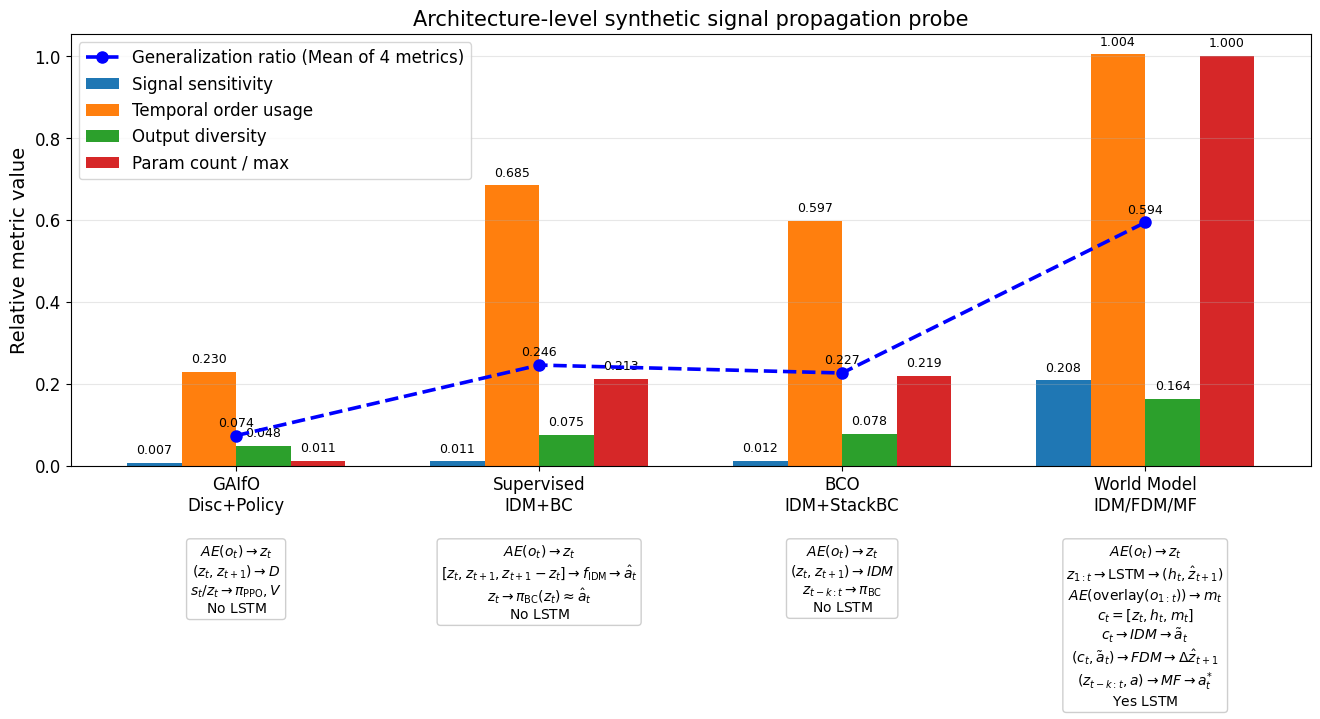

In [19]:
# ============================================================
# Plot 2: architecture plot + generalization ratio
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

bars1 = ax.bar(
    x - 1.5 * w,
    sens,
    width=w,
    label="Signal sensitivity",
)

bars2 = ax.bar(
    x - 0.5 * w,
    temp,
    width=w,
    label="Temporal order usage",
)

bars3 = ax.bar(
    x + 0.5 * w,
    div,
    width=w,
    label="Output diversity",
)

bars4 = ax.bar(
    x + 1.5 * w,
    params_norm,
    width=w,
    label="Param count / max",
)

line_gen, = ax.plot(
    x,
    generalization_ratio,
    "--o",
    linewidth=2.6,
    markersize=8,
    color="blue",
    label="Generalization ratio (Mean of 4 metrics)",
    zorder=5,
)

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=12)
ax.set_ylabel("Relative metric value", fontsize=14)
ax.set_title("Architecture-level synthetic signal propagation probe", fontsize=15)
ax.tick_params(axis="y", labelsize=12)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", fontsize=12)

def add_bar_labels(bar_container, fmt="{:.3f}", fontsize=9):
    for bar in bar_container:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.015,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=0,
        )

add_bar_labels(bars1, fmt="{:.3f}")
add_bar_labels(bars2, fmt="{:.3f}")
add_bar_labels(bars3, fmt="{:.3f}")
add_bar_labels(bars4, fmt="{:.3f}")

for xi, yi in zip(x, generalization_ratio):
    ax.text(
        xi,
        yi + 0.015,
        f"{yi:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
    )

plt.subplots_adjust(bottom=0.34)

for i, txt in enumerate(eq_labels):
    ax.text(
        x[i],
        -0.18,
        txt,
        ha="center",
        va="top",
        fontsize=10,
        transform=ax.get_xaxis_transform(),
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.8",
            alpha=0.95,
        ),
    )

plt.savefig(
    "architecture_signal_probe_latex_with_bar_values.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()
